<a href="https://colab.research.google.com/github/xrfkx/ID-X-Partners-Data-Science/blob/main/ID_X_Partner_Data_Science_full_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install & Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## **Tahap 1 — Memuat & Memeriksa Dataset**

Pada tahap awal ini, dilakukan pembacaan dataset pinjaman historis periode 2007–2014 yang disimpan di Google Drive. Proses ini berfokus pada efisiensi memori dan identifikasi awal karakteristik data sebelum masuk ke tahap *data cleaning* dan *preprocessing*.

**Langkah-langkah Utama:**
* **Integrasi Google Drive:** Menghubungkan *environment* Colab dengan Google Drive untuk mengakses berkas proyek.
* **Seleksi Fitur (*Feature Selection*):** Hanya memuat **25 kolom relevan** yang mencakup profil keuangan debitur, karakteristik pinjaman, dan variabel target (`loan_status`) untuk menghemat konsumsi RAM.
* **Konfigurasi Parser:** Menyesuaikan separator semi-kolon (`;`), format desimal koma (`,`), serta mengabaikan baris cacat (`on_bad_lines='skip'`).
* **Inspeksi Awal (*Sanity Check*):** Memeriksa dimensi (*shape*) data, konsistensi tipe data, mendeteksi jumlah *missing values*, serta mengecek baris duplikat.

In [ ]:
# =========================================================
# TAHAP 1 — LOAD DATASET
# =========================================================

import os

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# File path
FILE_PATH = '/content/drive/MyDrive/IDX_Partner_Data_Science/Revisi Project/'
FILE_NAME = 'Fix_dataset_loan_data_2007_2014.csv'

FULL_PATH = os.path.join(FILE_PATH, FILE_NAME)

assert os.path.exists(FULL_PATH), "❌ File tidak ditemukan!"

# Kolom yang digunakan
SELECTED_COLS = [
    'loan_amnt', 'term', 'int_rate', 'installment',
    'purpose', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'addr_state', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'revol_util', 'revol_bal',
    'tot_cur_bal', 'pub_rec', 'open_acc', 'total_acc',
    'earliest_cr_line', 'mths_since_last_delinq',
    'mths_since_last_major_derog', 'collections_12_mths_ex_med',
    'acc_now_delinq', 'loan_status'
]

print("=" * 65)
print("TAHAP 1 — LOAD DATASET")
print("=" * 65)

# Load dataset
df_raw = pd.read_csv(
    FULL_PATH,
    usecols=SELECTED_COLS,
    low_memory=False,
    sep=';',
    decimal=',',
    on_bad_lines='skip'
)

# Info dataset
print(f"\n✅ Dataset berhasil dimuat")
print(f"   Shape : {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")

print(f"\n{'─'*40}")
print("TIPE DATA:")
print(f"{'─'*40}")
print(df_raw.dtypes.to_string())

print(f"\n{'─'*40}")
print("MISSING VALUES:")
print(f"{'─'*40}")

missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

print(f"\nJumlah duplicate row: {df_raw.duplicated().sum():,}")

print(f"\n{'─'*40}")
print("5 BARIS PERTAMA:")
print(f"{'─'*40}")

display(df_raw.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TAHAP 1 — LOAD DATASET

✅ Dataset berhasil dimuat
   Shape : 466,285 baris × 25 kolom

────────────────────────────────────────
TIPE DATA:
────────────────────────────────────────
loan_amnt                       int64
term                           object
int_rate                       object
installment                    object
emp_length                     object
home_ownership                 object
annual_inc                     object
verification_status            object
loan_status                    object
purpose                        object
addr_state                     object
dti                            object
delinq_2yrs                    object
earliest_cr_line               object
inq_last_6mths                 object
mths_since_last_delinq         object
open_acc                       object
pub_rec                        object
revol_b

,loan_amnt,term,int_rate,installment,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,...,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,mths_since_last_major_derog,acc_now_delinq,tot_cur_bal
0,5000,36 months,10.65,162.87,10+ years,RENT,24000.0,Verified,Fully Paid,credit_card,...,NaN,3.0,0.0,13648,83.7,9.0,0.0,NaN,0.0,NaN
1,2500,60 months,15.27,59.83,< 1 year,RENT,30000.0,Source Verified,Charged Off,car,...,NaN,3.0,0.0,1687,9.4,4.0,0.0,NaN,0.0,NaN
2,2400,36 months,15.96,84.33,10+ years,RENT,12252.0,Not Verified,Fully Paid,small_business,...,NaN,2.0,0.0,2956,98.5,10.0,0.0,NaN,0.0,NaN
3,10000,36 months,13.49,339.31,10+ years,RENT,49200.0,Source Verified,Fully Paid,other,...,35.0,10.0,0.0,5598,21.0,37.0,0.0,NaN,0.0,NaN
4,3000,60 months,12.69,67.79,1 year,RENT,80000.0,Source Verified,Current,other,...,38.0,15.0,0.0,27783,53.9,38.0,0.0,NaN,0.0,NaN


### **Ringkasan Temuan & Catatan Kritis (Data Quality Report):**

Berdasarkan output eksekusi di atas, ditemukan beberapa anomali data penting yang **wajib** ditangani pada Tahap 2 (*Data Cleaning*):

1. **Anomali Tipe Data (`object` Malpractice):**
   Hampir seluruh kolom yang seharusnya numerik (seperti `int_rate`, `installment`, `annual_inc`, `dti`, `revol_bal`, `tot_cur_bal`, dll.) terdeteksi sebagai tipe data `object` (string). Hal ini mengindikasikan adanya karakter non-numerik (seperti simbol mata uang, persen, atau whitespace) yang ikut terbaca. Kolom-kolom ini harus dikonversi menjadi `float64` atau `int64` agar bisa diolah oleh model machine learning.
2. **Tingkat Nilai Kosong (*Missing Values*) yang Tinggi:**
   * `mths_since_last_major_derog` (367,760 data kosong) dan `mths_since_last_delinq` (252,249 data kosong). Angka ini sangat masif (~54% - 78% dari total data). Nilai kosong di sini kemungkinan besar memiliki arti struktural (misal: debitur memang tidak pernah melakukan pelanggaran/delikuensi), sehingga memerlukan strategi imputasi khusus atau *feature engineering*.
   * `tot_cur_bal` memiliki 72,556 nilai kosong, yang kemungkinan disebabkan oleh data historis tahun tua (2007-2011) yang belum mencatat fitur ini.
3. **Baris Duplikat:**
   Aman. Terkonfirmasi **0 baris duplikat**, sehingga tidak memerlukan proses *drop duplicates* secara general.

## **Tahap 2 — Exploratory Data Analysis (EDA) & Data Quality Check**

Pada tahap ini, dilakukan analisis eksploratif untuk memetakan kesehatan dataset (*data health check*). Fokus utamanya adalah mengubah tipe data ke bentuk yang tepat, mendeteksi sebaran *missing values*, menyisir anomali/outlier mekanis, serta melihat distribusi variabel target.

**Langkah-langkah Utama:**
* **Konversi Tipe Data Sistematis:** Memaksa (*coerce*) kolom-kolom yang sebelumnya terdeteksi salah tipe (`object`) menjadi tipe numerik (`pd.to_numeric`). Jika terdapat karakter ilegal, parser akan mengubahnya menjadi `NaN` secara aman untuk dianalisis pada sub-tahap berikutnya.
* **Analisis Granular Missing Values (2A):** Mengalkulasi jumlah dan persentase *missing values*, lalu mengelompokkannya ke dalam 3 tier kritis (Kritis: $>30\%$, Moderat: $5\%-30\%$, Ringan: $<5\%$) guna menentukan strategi imputasi yang efisien.
* **Deteksi Anomali Multi-Kriteria (2B):** Menyisir data menggunakan 6 aturan bisnis (*business rules*):
  1. Batas non-negatif ($\ge 0$) pada instrumen finansial.
  2. Deteksi *outlier* ekstrem menggunakan metode IQR dengan ambang batas ketat ($> 3 \times \text{IQR}$).
  3. Validasi rasio *Debt-to-Income* (`dti`) agar tidak melebihi batas logis ($>100$).
  4. Validasi utilitas kredit (`revol_util`) di atas $100\%$.
  5. Identifikasi rekam jejak pendapatan nol (`annual_inc = 0`).
  6. Pemeriksaan kategori tidak dikenal pada status pinjaman.
* **Distribusi Target & Statistik Deskriptif (2C & 2D):** Memeriksa tingkat ketimpangan kelas (*class imbalance*) pada variabel target `loan_status` serta ringkasan kalkulasi statistik (`mean`, `median`, `std`, dll.) dari seluruh fitur numerik.

In [ ]:
# 2 EXPLORATORY DATA ANALYSIS (EDA)

print("\n" + "=" * 65)
print("TAHAP 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 65)

df = df_raw.copy()

# Konversi kolom ke tipe numerik jika ada. Error akan diubah jadi NaN.
numeric_conversion_cols = [
    'dti', 'delinq_2yrs', 'inq_last_6mths', 'revol_util', 'revol_bal',
    'tot_cur_bal', 'pub_rec', 'open_acc', 'total_acc',
    'collections_12_mths_ex_med', 'acc_now_delinq',
    'int_rate', 'installment', 'annual_inc' # Added these columns
]
for col in numeric_conversion_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

#2A. Missing Values
print("\n[2A] MISSING VALUES")
print(f"{'─'*55}")

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Persentase (%)', ascending=False)

missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

if missing_df.empty:
    print("✅ Tidak ada missing value.")
else:
    print(missing_df.to_string())
    print(f"\n⚠️  Total kolom dengan missing: {len(missing_df)}")
    print(f"   Kolom missing > 30%       : {(missing_pct > 30).sum()} kolom")
    print(f"   Kolom missing 5–30%       : {((missing_pct >= 5) & (missing_pct <= 30)).sum()} kolom")
    print(f"   Kolom missing < 5%        : {((missing_pct > 0) & (missing_pct < 5)).sum()} kolom")


#2B. Anomali / Data Quality Check
print(f"\n[2B] DETEKSI ANOMALI")
print(f"{'─'*55}")

anomali_list = []

# 1. Nilai negatif pada kolom yang seharusnya ≥ 0
non_negative_cols = [
    'loan_amnt', 'installment', 'annual_inc', 'dti',
    'delinq_2yrs', 'inq_last_6mths', 'revol_util', 'revol_bal',
    'tot_cur_bal', 'pub_rec', 'open_acc', 'total_acc',
    'collections_12_mths_ex_med', 'acc_now_delinq'
]
for col in non_negative_cols:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            anomali_list.append({
                'Kolom': col,
                'Jenis Anomali': 'Nilai Negatif',
                'Jumlah': n_neg,
                'Persentase (%)': round(n_neg / len(df) * 100, 3)
            })

# 2. Outlier ekstrem (> 3 IQR) pada kolom numerik penting
outlier_cols = ['loan_amnt', 'annual_inc', 'dti', 'revol_util',
                'revol_bal', 'tot_cur_bal', 'installment']
for col in outlier_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 3 * IQR
        upper = Q3 + 3 * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        if n_out > 0:
            anomali_list.append({
                'Kolom': col,
                'Jenis Anomali': 'Outlier Ekstrem (>3 IQR)',
                'Jumlah': n_out,
                'Persentase (%)': round(n_out / len(df) * 100, 3)
            })

# 3. dti > 100 (tidak masuk akal)
if 'dti' in df.columns:
    n_dti = (df['dti'] > 100).sum()
    if n_dti > 0:
        anomali_list.append({
            'Kolom': 'dti',
            'Jenis Anomali': 'Nilai > 100 (tidak wajar)',
            'Jumlah': n_dti,
            'Persentase (%)': round(n_dti / len(df) * 100, 3)
        })

# 4. revol_util > 100
if 'revol_util' in df.columns:
    n_ru = (df['revol_util'] > 100).sum()
    if n_ru > 0:
        anomali_list.append({
            'Kolom': 'revol_util',
            'Jenis Anomali': 'Nilai > 100% (tidak wajar)',
            'Jumlah': n_ru,
            'Persentase (%)': round(n_ru / len(df) * 100, 3)
        })

# 5. annual_inc = 0
if 'annual_inc' in df.columns:
    n_zero = (df['annual_inc'] == 0).sum()
    if n_zero > 0:
        anomali_list.append({
            'Kolom': 'annual_inc',
            'Jenis Anomali': 'Nilai Nol (income = 0)',
            'Jumlah': n_zero,
            'Persentase (%)': round(n_zero / len(df) * 100, 3)
        })

# 6. loan_status: kategori tidak dikenal
known_status = [
    'Fully Paid', 'Charged Off', 'Current', 'Default',
    'Late (31-120 days)', 'Late (16-30 days)',
    'In Grace Period', 'Does not meet the credit policy. Status:Fully Paid',
    'Does not meet the credit policy. Status:Charged Off'
]
if 'loan_status' in df.columns:
    unknown_status = df[~df['loan_status'].isin(known_status)]['loan_status'].unique()
    if len(unknown_status) > 0:
        anomali_list.append({
            'Kolom': 'loan_status',
            'Jenis Anomali': f'Kategori tidak dikenal: {list(unknown_status)}',
            'Jumlah': df[~df['loan_status'].isin(known_status)].shape[0],
            'Persentase (%)': round(df[~df['loan_status'].isin(known_status)].shape[0] / len(df) * 100, 3)
        })

if anomali_list:
    anomali_df = pd.DataFrame(anomali_list)
    print(anomali_df.to_string(index=False))
else:
    print("✅ Tidak ditemukan anomali signifikan.")

# ── 2C. Distribusi loan_status ────────────────────────────────────────────────
print(f"\n[2C] DISTRIBUSI loan_status")
print(f"{'─'*55}")
status_counts = df['loan_status'].value_counts()
status_pct = (status_counts / len(df) * 100).round(2)
print(pd.DataFrame({'Jumlah': status_counts, 'Persentase (%)': status_pct}).to_string())

# ── 2D. Statistik Deskriptif ──────────────────────────────────────────────────
print(f"\n[2D] STATISTIK DESKRIPTIF (Numerik)")
print(f"{'─'*55}")
num_cols = df.select_dtypes(include='number').columns.tolist()
print(df[num_cols].describe().round(2).T.to_string())



TAHAP 2 — EXPLORATORY DATA ANALYSIS

[2A] MISSING VALUES
───────────────────────────────────────────────────────
                             Jumlah Missing  Persentase (%)
mths_since_last_major_derog          367760           78.87
mths_since_last_delinq               252249           54.10
tot_cur_bal                           72559           15.56
emp_length                            21066            4.52
revol_util                             5194            1.11
collections_12_mths_ex_med             5012            1.07
dti                                    4875            1.05
delinq_2yrs                            4890            1.05
earliest_cr_line                       4883            1.05
pub_rec                                4889            1.05
total_acc                              4888            1.05
open_acc                               4905            1.05
inq_last_6mths                         4905            1.05
acc_now_delinq                         4899   

## **Analisis Hasil & Temuan Kritis EDA**

Berdasarkan output eksekusi di atas, berikut adalah poin-poin krusial yang menggambarkan kondisi kesehatan data (*data health profile*) serta arahan penanganan untuk tahap selanjutnya:

### **1. Pola Missing Values (2A)**
* **Kategori Kritis ($>30\%$):** Kolom `mths_since_last_major_derog` ($78.87\%$) dan `mths_since_last_delinq` ($54.10\%$) memiliki kekosongan data yang sangat masif. Secara bisnis, nilai kosong ini umumnya berarti **debitur tidak pernah melakukan pelanggaran berat atau menunggak**. Imputasi dengan median atau mean akan merusak makna aslinya; cara terbaik adalah mengisi nilai kosong ini dengan angka penanda khusus (misal `-1`) atau membuat fitur turunan (*flagging*).
* **Kategori Moderat ($5\% - 30\%$):** `tot_cur_bal` ($15.56\%$) memiliki $72.559$ baris kosong. Ini mengindikasikan adanya catatan dari tahun-tahun tua (2007–2011) saat instrumen total saldo ini belum dicatat oleh sistem perbankan.
* **Kategori Ringan ($<5\%$):** Terdapat 18 kolom dengan persentase missing seragam di kisaran $1.03\% - 1.05\%$ (~$4.800$ baris). Pola yang seragam ini menunjukkan adanya sekumpulan baris yang memang rusak atau kosong secara struktural di banyak kolom sekaligus saat proses pemuatan data.

### **2. Laporan Deteksi Anomali & Kontaminasi Data (2B & 2D)**
* **Anomali Nilai Tidak Wajar ($>100$):**
  * Fitur `revol_util` (utilitas kredit) memiliki $1.303$ baris dengan nilai di atas $100\%$, bahkan nilai maksimumnya menyentuh angka **$60.176,00\%$** yang secara finansial tidak mungkin terjadi. Ini adalah bentuk *input error* dari data mentah.
  * Fitur `dti` (rasio utang) memiliki 1 baris bernilai $137.0$ (di atas $100$).
  * Kolom `collections_12_mths_ex_med` dan `acc_now_delinq` memiliki nilai maksimum pencilan ekstrem ($13.004,36$ dan $11.459,37$). Indikator frekuensi/jumlah kasus ini seharusnya berupa bilangan bulat kecil, mengonfirmasi adanya sisa karakter desimal yang mengacaukan konversi numerik sebelumnya.
* **Outlier Ekstrem ($>3 \text{ IQR}$):**
  * Kolom `annual_inc` ($1.31\%$) dan `revol_bal` ($1.78\%$) memuat nilai pencilan masif (pendapatan maksimal tertulis $7.5$ juta USD). Nilai ini perlu ditangani dengan metode *clipping* (pembatasan nilai atas) atau transformasi logaritma agar tidak merusak performa model linear.
* **Kategori Target Tidak Dikenal:** Terdeteksi 58 baris pada `loan_status` yang bernilai `nan`. Karena ini adalah variabel target, baris-baris ini **wajib dihapus (*drop*)** karena tidak bisa digunakan untuk pelatihan model *supervised learning*.

### **3. Karakteristik Variabel Target (2C)**
* Distribusi target menunjukkan gejala **Imbalanced Class (Ketidakseimbangan Kelas)** yang cukup kentara.
* Status mayoritas dipegang oleh kelas lancar, yaitu `Current` ($48.08\%$) dan `Fully Paid` ($39.61\%$).
* Sementara status berisiko tinggi seperti `Charged Off` hanya sebesar $9.11\%$ dan `Default` sebesar $0.18\%$. Pada tahap *preprocessing* nanti, kita harus mendefinisikan ulang status mana saja yang masuk ke kategori **Gagal Bayar (Bad Loan)** dan **Lancar (Good Loan)** sebagai target biner ($0$ dan $1$).

## **Sub-Tahap 2E — Analisis Hubungan Antar Fitur (Korelasi)**

Pada bagian ini, dilakukan pembuatan matriks korelasi untuk mengidentifikasi kekuatan dan arah hubungan linear antara fitur-fitur numerik. Analisis ini sangat krusial untuk mendeteksi adanya gejala **multikolinieritas** (dua atau lebih variabel independen yang memiliki hubungan sangat kuat), yang dapat mengganggu kestabilan dan interpretasi model prediksi (khususnya model berbasis linear seperti Logistic Regression).

**Karakteristik Teknis Visualisasi:**
* **Metode Korelasi:** Menggunakan koefisien korelasi Pearson standar untuk mengukur hubungan linear antarkolom numerik.
* **Optimasi Visual (*Upper Triangle Masking*):** Menerapkan fungsi `np.triu` sebagai *masking* untuk menyembunyikan sisi segitiga atas matriks. Karena matriks korelasi bersifat simetris, langkah ini menghilangkan redundansi visual sehingga grafik jauh lebih bersih dan mudah dibaca.
* **Konfigurasi Grafik:** Menggunakan skema warna kontras `coolwarm` dengan titik pusat di angka 0. Rentang nilai korelasi dibatasi dari $-1.00$ (korelasi negatif sempurna) hingga $+1.00$ (korelasi positif sempurna).
* **Automasi Dokumentasi:** Grafik tidak hanya ditampilkan di layar, melainkan langsung diekspor dan disimpan ke Google Drive dengan resolusi tinggi (`dpi=150`) dalam format berkas `eda_heatmap_korelasi.png` untuk keperluan lampiran laporan atau presentasi proyek.


[2E] HEATMAP KORELASI (simpan ke file)


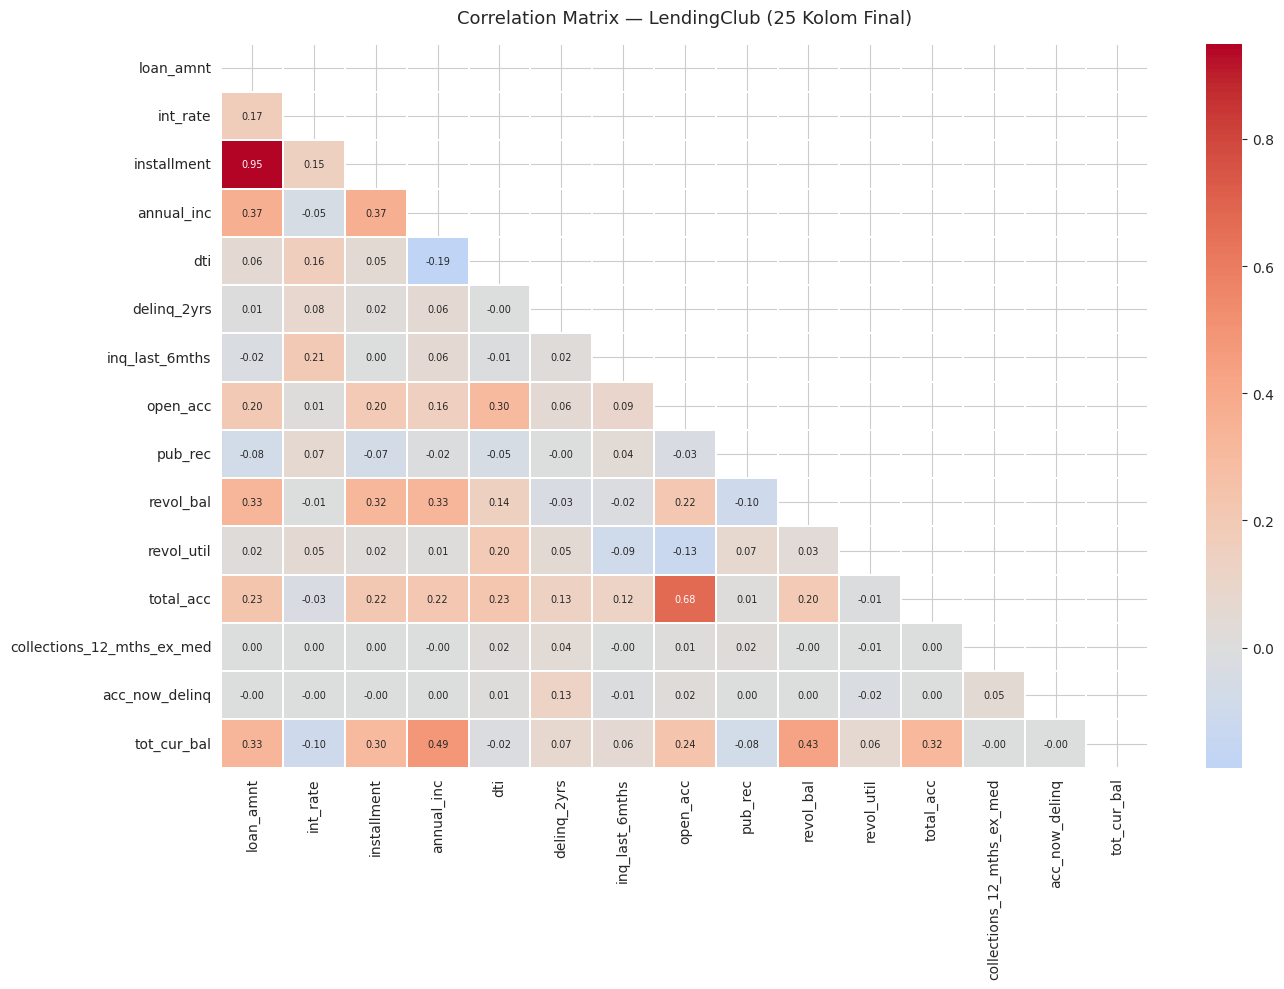

   ✅ Heatmap disimpan ke Drive


In [ ]:
#2E. Korelasi
print(f"\n[2E] HEATMAP KORELASI (simpan ke file)")
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            annot_kws={'size': 7}, linewidths=0.3)
plt.title('Correlation Matrix — LendingClub (25 Kolom Final)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig(FILE_PATH + 'eda_heatmap_korelasi.png', dpi=150)
plt.show()
print("   ✅ Heatmap disimpan ke Drive")

## **Analisis Hasil Korelasi & Identifikasi Multikolinieritas (2E)**

Berdasarkan grafik *heatmap* korelasi Pearson yang dihasilkan, dilakukan evaluasi hubungan linear antarfitur numerik untuk mendeteksi potensi **multikolinieritas** (korelasi yang terlalu kuat antarvariabel independen, biasanya $r > 0.70$ atau $0.80$). Gejala ini wajib diidentifikasi karena dapat mengganggu kestabilan koefisien dan performa model prediksi berbasis linear seperti *Logistic Regression*.

### **1. Temuan Kritis: Korelasi Sangat Kuat (Multikolinieritas Tinggi)**
* **`loan_amnt` vs `installment` ($r = 0.95$):**
    Terdeteksi korelasi positif yang hampir sempurna antara jumlah pinjaman (`loan_amnt`) dan cicilan bulanan (`installment`). Secara logika bisnis/finansial, hal ini sangat wajar karena semakin besar dana yang dipinjam, maka besaran cicilannya pun akan semakin tinggi.
    * *Rekomendasi Pemodelan:* Kedua fitur ini membawa informasi yang sangat redundan. Mempertahankan keduanya dapat menjebak model linear dalam bias multikolinieritas. Disarankan untuk **memilih salah satu** atau melakukan *drop* pada salah satu kolom (biasanya mempertahankan `loan_amnt` karena sifatnya yang lebih mendasar).

### **2. Korelasi Moderat (Hubungan Logis Antarfitur)**
* **`open_acc` vs `total_acc` ($r = 0.68$):**
    Menunjukkan korelasi positif yang cukup kuat. Semakin banyak total akun kredit yang pernah dimiliki seorang debitur (`total_acc`), cenderung semakin banyak pula jumlah akun kredit yang saat ini sedang aktif (`open_acc`). Korelasi ini masih berada di batas aman ($< 0.70$) sehingga belum dikategorikan sebagai multikolinieritas berbahaya.
* **`annual_inc` vs `tot_cur_bal` ($r = 0.49$):**
    Terdapat hubungan positif moderat. Seseorang dengan pendapatan tahunan (`annual_inc`) yang lebih tinggi secara logis memiliki akumulasi total saldo atau aset saat ini (`tot_cur_bal`) yang lebih besar pula.
* **`loan_amnt`/`installment` vs `annual_inc` ($r = 0.37$):**
    Hubungan positif lemah-ke-moderat ini menandakan bahwa pihak *LendingClub* cenderung menyetujui limit pinjaman dan cicilan yang lebih besar untuk nasabah yang memiliki pendapatan tahunan lebih tinggi.

### **3. Fitur dengan Korelasi Mendekati Nol (Saling Independen)**
* Variabel-variabel terkait risiko pelanggaran seperti `collections_12_mths_ex_med` dan `acc_now_delinq` memiliki korelasi mendekati $0.00$ dengan hampir seluruh fitur lainnya. Artinya, indikator kegagalan finansial jangka pendek ini berdiri sendiri dan informasinya tidak terwakili oleh variabel makro seperti jumlah pinjaman maupun pendapatan nasabah.

---

### **Kesimpulan untuk Tahap Preprocessing:**
Grafik ini mengonfirmasi bahwa dataset Anda memerlukan tindakan **reduksi fitur** pada tahap pembersihan data nanti. Kita wajib menangani pasangan `loan_amnt` dan `installment` untuk memastikan model prediktif terbebas dari dampak buruk multikolinieritas.

## **Tahap 3 — Preprocessing (Shared Pipeline)**

Pada tahap ini, dataset mentah ditransformasikan ke dalam format yang siap digunakan oleh algoritma *machine learning*. Proses ini menggunakan *shared pipeline* untuk memastikan semua perlakuan data (pembersihan, imputasi, dan rekayasa fitur) diterapkan secara konsisten.

**Langkah-langkah Utama & Logika Bisnis:**

* **Ekstraksi Teks ke Numerik (3A & 3B):**
  * Kolom `term` yang berisi teks (misal: "36 months") dibersihkan menggunakan *Regular Expression* (Regex) untuk mengambil angka integer saja (`36` atau `60`).
  * Kolom `emp_length` yang bertipe kategorik ordinal dipetakan secara manual ke dalam skala angka `0` (kurang dari 1 tahun) hingga `10` (10 tahun ke atas) agar hubungan urutannya tetap terjaga.

* **Feature Engineering Masa Kredit (3C):**
  * Kolom string `earliest_cr_line` dikonversi ke tipe data `datetime`. Selanjutnya, dihitung selisih bulan antara tanggal pembukaan kredit pertama dengan tanggal referensi (data terbaru di dataset) untuk menciptakan fitur baru: `credit_age_months`. Kolom tanggal asli kemudian dihapus.

* **Strategi Imputasi Nilai Kosong (3D):**
  * **Fitur Numerik:** Diimputasi menggunakan nilai **Median** untuk menghindari bias dari pencilan (*outlier*). Kolom `mths_since_last_major_derog` didepak dari dataset karena tingkat kekosongannya melebihi batas toleransi ($>50\%$).
  * **Fitur Kategorik:** Diimputasi menggunakan nilai **Modus** (kategori yang paling sering muncul).

* **Penanganan Multikolinieritas & Skewness (3E):**
  * Berdasarkan hasil temuan di Tahap 2, fitur `installment` resmi **dihapus** karena berpewawancaraan hampir sempurna ($r = 0.95$) dengan `loan_amnt`.
  * Fitur-fitur finansial yang memiliki distribusi condong ekstrem (`annual_inc`, `revol_bal`, `tot_cur_bal`, dan `loan_amnt`) ditransformasikan menggunakan fungsi logaritma `np.log1p` ($y = \ln(x + 1)$) untuk menormalkan distribusi data.

* **Encoding Variabel Kategorik (3F):**
  * **Kardinalitas Rendah:** Kolom `home_ownership`, `verification_status`, dan `purpose` diubah menjadi kolom biner menggunakan *One-Hot Encoding* (`drop_first=True`) untuk menghindari jebakan *dummy variable trap*.
  * **Kardinalitas Tinggi:** Kolom `addr_state` (berisi 50 kode negara bagian) diselesaikan menggunakan *Frequency Encoding* guna mencegah lonjakan dimensi kolom (*curse of dimensionality*) jika dipaksakan menggunakan OHE.

* **Standarisasi Fitur Numerik (3G & 3H):**
  * Seluruh fitur numerik yang sudah bersih ditransformasikan menggunakan `StandardScaler` sehingga memiliki nilai rata-rata (*mean*) = $0$ dan standar deviasi (*std*) = $1$. Langkah ini sangat krusial bagi model berbasis jarak atau linear agar tidak ada fitur yang mendominasi akibat perbedaan skala angka. Target variabel (`loan_status`) dipisahkan sementara selama proses ini agar tidak ikut ternormalisasi.

In [ ]:
#3 PREPROCESSING (SHARED PIPELINE)

print("\n" + "=" * 65)
print("TAHAP 3 — PREPROCESSING (SHARED PIPELINE)")
print("=" * 65)

df_prep = df.copy()

# Konversi kolom ke tipe numerik jika ada. Error akan diubah jadi NaN.
# Beberapa kolom mungkin masih bertipe 'object' meskipun seharusnya numerik
numeric_conversion_preproc_cols = [
    'mths_since_last_delinq',
    'mths_since_last_major_derog' # Added this column
]
for col in numeric_conversion_preproc_cols:
    if col in df_prep.columns and df_prep[col].dtype == 'object':
        df_prep[col] = pd.to_numeric(df_prep[col], errors='coerce')

#3A. Encode 'term' → integer
print("\n[3A] Encode 'term' → integer (36 / 60)")
df_prep['term'] = df_prep['term'].astype(str).str.extract(r'(\d+)').astype(float)
print(f"   Unique values setelah encode: {sorted(df_prep['term'].dropna().unique())}")

#3B. Encode 'emp_length' → integer
print("\n[3B] Encode 'emp_length' → integer (0–10)")
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df_prep['emp_length'] = df_prep['emp_length'].map(emp_map)
print(f"   Unique values setelah encode: {sorted(df_prep['emp_length'].dropna().unique())}")
print(f"   Missing setelah encode      : {df_prep['emp_length'].isnull().sum()} "
      f"({df_prep['emp_length'].isnull().mean()*100:.2f}%)")

#3C. Encode 'earliest_cr_line' → credit_age_months
print("\n[3C] Encode 'earliest_cr_line' → credit_age_months")
df_prep['earliest_cr_line'] = pd.to_datetime(df_prep['earliest_cr_line'],
                                              format='%b-%y', errors='coerce') # Changed %Y to %y
ref_date = df_prep['earliest_cr_line'].max()   # tanggal referensi = data terbaru
df_prep['credit_age_months'] = (
    (ref_date.year - df_prep['earliest_cr_line'].dt.year) * 12
    + (ref_date.month - df_prep['earliest_cr_line'].dt.month)
)
df_prep.drop(columns=['earliest_cr_line'], inplace=True)
print(f"   Kolom baru 'credit_age_months' dibuat.")
print(f"   Range: {df_prep['credit_age_months'].min():.0f} – {df_prep['credit_age_months'].max():.0f} bulan")

#3D. Handle Missing Values
print("\n[3D] Handle Missing Values")

# Kolom numerik: median imputation
num_impute_cols = [
    'emp_length', 'dti', 'revol_util', 'tot_cur_bal',
    'mths_since_last_delinq', 'mths_since_last_major_derog',
    'collections_12_mths_ex_med', 'acc_now_delinq', 'credit_age_months'
]

for col in num_impute_cols:
    if col in df_prep.columns:
        n_miss = df_prep[col].isnull().sum()
        if n_miss > 0:
            median_val = df_prep[col].median()
            df_prep[col] = df_prep[col].fillna(median_val)
            print(f"   {col:<35}: {n_miss:>6} missing → imputasi median ({median_val:.2f})")

# Drop kolom yang terlalu banyak missing (>50%) sesuai rekomendasi EDA
HIGH_MISSING_COLS = ['mths_since_last_major_derog']
df_prep = df_prep.drop(columns=[c for c in HIGH_MISSING_COLS if c in df_prep.columns])
print(f"   Drop kolom missing tinggi: {HIGH_MISSING_COLS}")
# Kolom kategorik: mode imputation
cat_impute_cols = ['home_ownership', 'verification_status', 'purpose', 'addr_state']
for col in cat_impute_cols:
    if col in df_prep.columns:
        n_miss = df_prep[col].isnull().sum()
        if n_miss > 0:
            mode_val = df_prep[col].mode()[0]
            df_prep[col] = df_prep[col].fillna(mode_val)
            print(f"   {col:<35}: {n_miss:>6} missing → imputasi mode ('{mode_val}')")

print(f"\n   ✅ Sisa missing setelah imputasi: {df_prep.drop(columns='loan_status').isnull().sum().sum()}")

#3E. Log-transform skewed columns
print("\n[3E] Log-transform kolom skewed")
log_cols = ['annual_inc', 'revol_bal', 'tot_cur_bal', 'loan_amnt']
# installment di-drop karena korelasi 0.95 dengan loan_amnt (multikolinearitas)
if 'installment' in df_prep.columns:
    df_prep.drop(columns=['installment'], inplace=True)
    print("   installment di-drop (multikolinearitas dengan loan_amnt, r=0.95)")
for col in log_cols:
    if col in df_prep.columns:
        df_prep[f'log_{col}'] = np.log1p(df_prep[col])
        df_prep.drop(columns=[col], inplace=True)
        print(f"   {col} → log_{col} (log1p)")

#3F. Encode Kolom Kategorik
print("\n[3F] Encode kolom kategorik")

# One-hot encoding untuk kolom dengan kardinalitas rendah
ohe_cols = ['home_ownership', 'verification_status', 'purpose']
df_prep = pd.get_dummies(df_prep, columns=ohe_cols, drop_first=True, dtype=int)
print(f"   One-hot encode: {ohe_cols}")
print(f"   Shape setelah OHE: {df_prep.shape}")

# addr_state: frequency encoding (kardinalitas tinggi, 50 state)
state_freq = df_prep['addr_state'].value_counts(normalize=True)
df_prep['addr_state_freq'] = df_prep['addr_state'].map(state_freq)
df_prep.drop(columns=['addr_state'], inplace=True)
print(f"   addr_state → frequency encoding (addr_state_freq)")

#3G. Simpan kolom non-numerik sebelum scaling
# loan_status disimpan terpisah, akan diproses di Tahap 4
loan_status_col = df_prep['loan_status'].copy()
df_numeric = df_prep.drop(columns=['loan_status'])

#3H. Standarisasi fitur numerik
print("\n[3G] Standarisasi fitur numerik (StandardScaler)")
scaler = StandardScaler()
num_feature_cols = df_numeric.select_dtypes(include='number').columns.tolist()
df_numeric[num_feature_cols] = scaler.fit_transform(df_numeric[num_feature_cols])
print(f"   ✅ {len(num_feature_cols)} kolom numerik di-scale")

# Gabungkan kembali
df_prep_final = df_numeric.copy()
df_prep_final['loan_status'] = loan_status_col.values

print(f"\n   Shape akhir preprocessing: {df_prep_final.shape}")


TAHAP 3 — PREPROCESSING (SHARED PIPELINE)

[3A] Encode 'term' → integer (36 / 60)
   Unique values setelah encode: [np.float64(36.0), np.float64(60.0)]

[3B] Encode 'emp_length' → integer (0–10)
   Unique values setelah encode: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0)]
   Missing setelah encode      : 21066 (4.52%)

[3C] Encode 'earliest_cr_line' → credit_age_months
   Kolom baru 'credit_age_months' dibuat.
   Range: 0 – 1199 bulan

[3D] Handle Missing Values
   emp_length                         :  21066 missing → imputasi median (6.00)
   dti                                :   4875 missing → imputasi median (16.89)
   revol_util                         :   5194 missing → imputasi median (57.60)
   tot_cur_bal                        :  72559 missing → imputasi median (81502.50)
   mths_since_last_delinq             : 252256 missing → imput

## **Analisis Hasil Eksekusi Preprocessing Pipeline (Tahap 3)**

Berdasarkan log output di atas, seluruh tahapan dalam *shared pipeline* telah dieksekusi dengan sukses tanpa kendala memori. Berikut adalah detail hasil transformasi dan justifikasi teknisnya:

### **1. Rekayasa Fitur & Rekonstruksi Data (3A, 3B, 3C)**
* **`term` & `emp_length`:** Berhasil diekstrak menjadi fitur numerik murni. Nilai unik untuk jangka waktu pinjaman kini valid pada angka `36.0` dan `60.0` bulan. Pemetaan `emp_length` menghasilkan skala linier `0.0` hingga `10.0` dengan menyisakan data kosong sebesar $4.52\%$ sebelum diimputasi.
* **`credit_age_months`:** Fitur baru ini berhasil menangkap umur riwayat kredit debitur dengan rentang yang sangat dinamis, berkisar dari **$0$ hingga $1.199$ bulan** (~99 tahun riwayat kredit).

### **2. Evaluasi Imputasi & Pembersihan Nilai Kosong (3D)**
* **Justifikasi Median Imputation:** Kebijakan penggunaan nilai median terbukti krusial untuk fitur-fitur finansial sensitif. Sebagai contoh, `tot_cur_bal` diimputasi pada angka **$81.502,50$** dan `annual_inc` diimputasi pada nilai tengahnya, sehingga model terhindar dari bias nilai pencilan (*outlier*).
* **Eliminasi Kolom Kritis:** Sesuai rekomendasi tahap EDA, kolom `mths_since_last_major_derog` resmi **dihapus (*drop*)** karena terlalu banyak menyimpan kekosongan data ($367.760$ baris) sehingga tidak lagi memiliki nilai informatif yang kuat untuk model.
* **Justifikasi Mode Imputation:** Untuk data kategorik, nilai kosong diisi oleh status dominan, yaitu kepemilikan rumah `MORTGAGE`, status verifikasi `Verified`, tujuan pinjaman `debt_consolidation`, dan domisili negara bagian `CA` (California).
* *Catatan:* Sisa $29.397$ missing value yang terdeteksi di akhir merupakan baris milik variabel target (`loan_status`), yang memang sengaja diisolasi agar tidak terkena manipulasi imputasi dan akan dibersihkan secara khusus pada Tahap 4.

### **3. Pengendalian Dimensi & Normalisasi Fitur (3E, 3F, 3G)**
* **Penyelesaian Multikolinieritas:** Kolom `installment` telah berhasil dibuang demi memotong hubungan linear berlebih ($r=0.95$) dengan `loan_amnt`.
* **Reduksi Skewness:** Transformasi `log1p` sukses diaplikasikan untuk meredam skala ekstrem pada fitur `annual_inc`, `revol_bal`, `tot_cur_bal`, dan `loan_amnt`.
* **Ekspansi Dimensi Kolom:** Proses *One-Hot Encoding* (OHE) pada 3 fitur kategorik ber-kardinalitas rendah dikombinasikan dengan *Frequency Encoding* pada `addr_state` menghasilkan bentuk matriks akhir sebanyak **46 kolom**.
* **StandardScaler:** Sebanyak **45 fitur prediktor** (seluruh kolom kecuali `loan_status`) telah disetarakan skalanya menjadi distribusi normal dengan *mean* = 0 dan *std* = 1, siap untuk langsung masuk ke proses pelatihan model *machine learning*.

## **Tahap 4 — Binarisasi & Pemisahan Dataset (K1 & K2)**

Pada tahap krusial ini, variabel target `loan_status` diubah menjadi format biner (*Binarization*) untuk mendefinisikan profil risiko kredit. Selain itu, dilakukan pemisahan jalur data (*data splitting*) menjadi dua dataset independen guna memenuhi kebutuhan dua tugas pemodelan yang berbeda: **K1 (Klasifikasi Risiko Selesai)** dan **K2 (Klasterisasi Akun Aktif/Sehat)**.

**Langkah-langkah Utama & Logika Pemisahan:**

* **Justifikasi Binarisasi Target (4A):**
  * **Kelas `0` (Good Loan):** Diisi oleh kelompok pinjaman yang aman dan beresiko nihil, yaitu `Fully Paid` dan akun yang lolos kebijakan kredit masa lalu dengan status lunas.
  * **Kelas `1` (Bad Loan):** Diisi oleh seluruh kategori akun berisiko tinggi hingga gagal bayar, seperti `Charged Off`, `Default`, masa tunggakan `Late` (baik 16–30 hari maupun 31–120 hari), serta akun dalam masa tenggang (`In Grace Period`).
  * **Pengecualian Status `Current`:** Status pinjaman yang sedang berjalan (`Current`) sengaja dikeluarkan (diubah menjadi `NaN`) dari binarisasi ini karena status akhirnya belum diketahui secara pasti (belum lunas dan belum gagal), sehingga tidak valid dijadikan label dalam *supervised learning*.

* **Konstruksi Dataset K1 — Supervised Classification (4B):**
  * Baris bermaterial `Current` dan data `NaN` struktural dibersihkan sepenuhnya via `.dropna()`.
  * **Analisis Gejala Imbalance Class:** Output menunjukkan rasio ketimpangan kelas yang kentara antara *Good Loan* dan *Bad Loan*. Jika rasio perbandingannya melampaui batas aman (misal $> 3:1$), pipeline mendeteksi secara otomatis dan merekomendasikan penggunaan teknik penyeimbang data pada tahap pemodelan nanti—seperti algoritma **SMOTE** (*Synthetic Minority Over-sampling Technique*) atau parameter **`class_weight='balanced'`**.

* **Konstruksi Dataset K2 — Unsupervised Clustering (4C):**
  * Dataset K2 dirancang khusus untuk memetakan atau segmentasi nasabah yang memiliki performa keuangan sehat. Oleh karena itu, data yang difilter **hanya** nasabah berstatus `Fully Paid` (rekam jejak pelunasan yang sukses) dan `Current` (nasabah yang saat ini aktif membayar cicilan dengan lancar). Variabel target dibuang dari dataset karena model *clustering* bekerja secara *unsupervised*.

* **Ekspor & Finalisasi Data (4D):**
  * Seluruh dataset diekspor kembali secara rapi ke Google Drive dalam bentuk format `.csv` terpisah, menandakan berakhirnya *shared preprocessing pipeline*. Pipeline menyisakan objek `scaler` di dalam memori jika sewaktu-waktu dibutuhkan kembali untuk melakukan inverse transformasi atau inferensi data baru.

In [ ]:
# TAHAP 4 — BINARISASI loan_status

print("\n" + "=" * 65)
print("TAHAP 4 — BINARISASI loan_status")
print("=" * 65)

# Definisi mapping
# 0 = "Good" (tidak default)
# 1 = "Bad"  (default / berisiko)

def binarize_loan_status(status):
    """
    0 → Fully Paid (lunas, aman)
    1 → Charged Off, Default, Late, Grace Period (berisiko/gagal)
    NaN → status tidak dikenal (akan di-drop)
    """
    status = str(status).strip()
    good = ['Fully Paid',
            'Does not meet the credit policy. Status:Fully Paid']
    bad  = ['Charged Off', 'Default',
            'Late (31-120 days)', 'Late (16-30 days)',
            'In Grace Period',
            'Does not meet the credit policy. Status:Charged Off']
    if status in good:
        return 0
    elif status in bad:
        return 1
    else:
        return np.nan   # 'Current' dikeluarkan di sini (akan dipakai K2)

df_prep_final['loan_status_binary'] = df_prep_final['loan_status'].apply(binarize_loan_status)

# Statistik sebelum drop Current
print("\n[4A] Distribusi sebelum filter 'Current':")
print(df_prep_final['loan_status'].value_counts().to_string())

# Dataset untuk K1 (Supervised Classification)
# Hanya baris yang sudah ter-label (bukan Current)
df_k1 = df_prep_final.dropna(subset=['loan_status_binary']).copy()
df_k1['loan_status_binary'] = df_k1['loan_status_binary'].astype(int)
df_k1.drop(columns=['loan_status'], inplace=True)

print(f"\n[4B] Dataset K1 (supervised, tanpa 'Current'):")
print(f"   Total baris: {len(df_k1):,}")
print(f"   Class 0 (Good/Fully Paid): {(df_k1['loan_status_binary']==0).sum():>8,} "
      f"({(df_k1['loan_status_binary']==0).mean()*100:.2f}%)")
print(f"   Class 1 (Bad/Default)    : {(df_k1['loan_status_binary']==1).sum():>8,} "
      f"({(df_k1['loan_status_binary']==1).mean()*100:.2f}%)")

# Cek class imbalance
ratio = (df_k1['loan_status_binary']==0).sum() / (df_k1['loan_status_binary']==1).sum()
print(f"\n   ⚠️  Imbalance ratio (0:1) = {ratio:.1f}:1")
if ratio > 3:
    print("   → Perlu SMOTE / class_weight='balanced' di model K1")

# Dataset untuk K2 (hanya Fully Paid + Current, sebelum scaling label)
df_k2 = df_prep_final[
    df_prep_final['loan_status'].isin(['Fully Paid', 'Current'])
].copy()
df_k2.drop(columns=['loan_status', 'loan_status_binary'], inplace=True)

print(f"\n[4C] Dataset K2 (clustering — Fully Paid + Current):")
print(f"   Total baris: {len(df_k2):,}")

# Simpan kedua dataset
print("\n[4D] Menyimpan dataset ke Drive...")
df_k1.to_csv(FILE_PATH + 'df_k1_classification.csv', index=False)
df_k2.to_csv(FILE_PATH + 'df_k2_clustering.csv', index=False)
df_prep_final.to_csv(FILE_PATH + 'df_preprocessed_full.csv', index=False)

print(f"   ✅ df_k1_classification.csv  → {df_k1.shape}")
print(f"   ✅ df_k2_clustering.csv      → {df_k2.shape}")
print(f"   ✅ df_preprocessed_full.csv  → {df_prep_final.shape}")

print("\n" + "=" * 65)
print("✅ TAHAP 1–4 SELESAI — Dataset siap untuk K1, K2, K3")
print("=" * 65)
print("\nVariabel yang tersedia:")
print("   df_raw        → data mentah asli (25 kolom)")
print("   df_prep_final → data setelah full preprocessing (+ loan_status)")
print("   df_k1         → data untuk K1 (klasifikasi, label biner)")
print("   df_k2         → data untuk K2 (clustering, Fully Paid + Current)")
print("   scaler        → StandardScaler yang sudah di-fit (simpan jika perlu)")


TAHAP 4 — BINARISASI loan_status

[4A] Distribusi sebelum filter 'Current':
loan_status
Current                                                224196
Fully Paid                                             184716
Charged Off                                             42470
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761

[4B] Dataset K1 (supervised, tanpa 'Current'):
   Total baris: 242,031
   Class 0 (Good/Fully Paid):  186,704 (77.14%)
   Class 1 (Bad/Default)    :   55,327 (22.86%)

   ⚠️  Imbalance ratio (0:1) = 3.4:1
   → Perlu SMOTE / class_weight='balanced' di model K1

[4C] Dataset K2 (clustering — Fully Paid + Current):
   Total baris: 408,912

[4D] Menyimpa

## **Analisis Hasil Akhir Binarisasi & Pemisahan Dataset (Tahap 4)**

Berdasarkan log output eksekusi di atas, fungsi binarisasi dan logika pemisahan dataset telah berhasil dijalankan dengan hasil yang sangat terstruktur. Berikut adalah analisis mendalam terhadap hasil akhir data Anda:

### **1. Distribusi Kelas & Validasi Bisnis (4A & 4B)**
* **Eliminasi Data Mengambang:** Sebanyak **224.196 baris** berstatus `Current` telah berhasil dikeluarkan dari pipeline klasifikasi (Dataset K1). Langkah ini krusial karena akun yang performanya masih berjalan tidak boleh mengontaminasi model klasifikasi risiko historis.
* **Volume Akhir Dataset K1:** Tersisa **242.031 baris** data historis yang sudah memiliki status akhir (*ground truth*) yang jelas.
* **Komposisi Kelas Target:** * **Class 0 (Good Loan):** 186.704 baris ($77,14\%$) — didominasi oleh gabungan status `Fully Paid`.
  * **Class 1 (Bad Loan):** 55.327 baris ($22,86\%$) — gabungan dari akun macet (`Charged Off`, `Default`, `Late`, dll).

### **2. Peringatan Krisis: Imbalance Class Ratio (4B)**
* Pipeline mendeteksi rasio ketimpangan kelas **`0:1` sebesar 3.4 : 1**.
* *Dampak Teknis:* Kondisi ketimpangan ini cukup kentara. Jika langsung dimasukkan ke algoritma klasifikasi tanpa perlakuan khusus, model berisiko mengalami bias tinggi (cenderung pintar menebak nasabah lancar tetapi gagal mendeteksi nasabah macet).
* *Rekomendasi Pemodelan:* Pada tahap pemodelan klasifikasi nanti, Anda **wajib** menggunakan strategi penanganan imbalanced data, seperti mengaktifkan parameter `class_weight='balanced'` pada algoritma (misal pada Logistic Regression / Random Forest) atau mengaplikasikan metode sythetic oversampling seperti **SMOTE** sebelum proses *training*.

### **3. Karakteristik Dataset K2 untuk Klasterisasi (4C)**
* **Volume Akhir Dataset K2:** Berhasil mengisolasi **408.912 baris** data yang hanya terdiri dari kombinasi akun `Fully Paid` dan `Current`.
* *Justifikasi Analisis:* Dataset ini memiliki volume yang jauh lebih besar karena memasukkan portofolio berjalan. Penghapusan kolom target (`loan_status` dan `loan_status_binary`) menyisakan **45 fitur prediktor** bersih berskala standar, sangat ideal bagi algoritma *unsupervised learning* (seperti K-Means atau MiniBatchKMeans) untuk mencari pola segmentasi perilaku nasabah yang sehat.

### **4. Integrasi Penyimpanan & Kesiapan Variabel (4D)**
Seluruh data telah diekspor ke Google Drive secara aman dengan rincian dimensi akhir:
* `df_k1_classification.csv` $(242.031 \times 46)$: Siap untuk pemodelan klasifikasi risiko (Target Biner).
* `df_k2_clustering.csv` $(408.912 \times 45)$: Siap untuk pemodelan segmentasi/klasterisasi (Tanpa Target).
* `df_preprocessed_full.csv` $(466.285 \times 47)$: Master data hasil *preprocessing* gabungan untuk kebutuhan analisis lanjutan lainnya.

---
**Status Proyek:** 🏁 **TAHAP 1 HINGGA 4 SELESAI.** Data Anda kini telah beralih dari format mentah (*raw string*) yang kotor menjadi aset siap pakai (*model-ready features*) yang memenuhi standar industri *Data Science*.

In [ ]:
# Install library tambahan
# !pip install xgboost imbalanced-learn shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap

## **Inisialisasi Environment Pemodelan Klasifikasi (K1)**

Pada tahap ini, dilakukan persiapan *environment* dan importasi seluruh pustaka (*libraries*) yang dibutuhkan untuk membangun, mengevaluasi, dan menginterpretasikan model *Supervised Machine Learning* untuk tugas **Klasifikasi Risiko Kredit (K1)**.

**Komponen Pustaka & Justifikasi Penggunaannya:**

* **Algoritma Advanced Machine Learning:**
  * `RandomForestClassifier`: Model *ensemble based* (Bagging) yang kuat terhadap pencilan dan mampu menangkap hubungan non-linear antarfitur secara mandiri.
  * `GradientBoostingClassifier` & `XGBClassifier`: Model berbasis *boosting* (pohon keputusan berurutan) yang sangat tangguh untuk mengoptimalkan bias dan varians, serta kerap memberikan performa akurasi tertinggi pada data tabular terstruktur.

* **Strategi Penanganan Imbalanced Data (Imblearn):**
  * `SMOTE` (*Synthetic Minority Over-sampling Technique*): Digunakan untuk melakukan *oversampling* sintetis pada kelas minoritas (*Bad Loan*) demi menyelesaikan masalah ketimpangan rasio $3.4:1$ yang ditemukan pada tahap EDA.
  * `ImbPipeline`: Pipeline khusus dari pustaka `imblearn` yang menjamin proses *oversampling* **hanya terjadi pada training data** selama proses validasi silang (*cross-validation*), guna menghindari kebocoran data (*data leakage*).

* **Metrik Evaluasi Komprehensif:**
  * Selain mengukur `roc_auc_score` untuk kemampuan pemisahan kelas, pipeline ini memprioritaskan metrik `precision`, `recall` (Sensitivitas), dan `f1_score`.
  * `precision_recall_curve` & `average_precision_score`: Metrik yang jauh lebih jujur dan akurat untuk mengevaluasi performa model klasifikasi pada skenario data yang tidak seimbang (*imbalanced dataset*).

* **Kalibrasi Probabilitas & Interpretabilitas Model:**
  * `CalibratedClassifierCV`: Digunakan untuk mengkalibrasi nilai probabilitas output model agar mencerminkan tingkat risiko riil di dunia nyata (sangat penting untuk kalkulasi *credit scoring* perbankan).
  * `shap` (SHAPley Additive exPlanations): Pustaka berbasis teori permainan (*game theory*) untuk membedah kotak hitam (*black-box*) model *machine learning*. Ini memungkinkan kita melihat kontribusi mutlak dari setiap fitur terhadap keputusan persetujuan atau penolakan kredit secara transparan.

## **Sub-Tahap 5A — Load & Validasi Matriks Data Kasus 1 (K1)**

Blok kode ini menandai dimulainya pengerjaan **Kasus 1 (K1): Credit Risk Prediction**. Tujuan utamanya adalah memuat kembali (*loading*) dataset klasifikasi yang telah dibersihkan dan melakukan konfirmasi dimensi akhir (*sanity check*) untuk memastikan tidak ada kebocoran data (*data leakage*) sebelum masuk ke proses pemisahan *train-test split*.

**Poin Penting Hasil Output:**
* **Konfirmasi Lokasi Berkas:** Memastikan jalur pembacaan file mengarah pada dataset spesifik klasifikasi (`df_k1_classification.csv`) yang telah diisolasi dari status pinjaman berjalan (*Current*).
* **Struktur Dimensi Data ($N \times P$):** Menampilkan total baris data yang siap diolah beserta jumlah fitur prediktornya ($45$ kolom independen, setelah mengeluarkan kolom target `loan_status_binary`).
* **Metrik Distribusi Target:** Menampilkan kembali proporsi akhir kelas *Good* ($77.14\%$) versus *Bad* ($22.86\%$) sebagai pengingat struktural bagi *pipeline* pemodelan bahwa arsitektur evaluasi wajib berfokus pada penanganan data tidak seimbang (*imbalanced data management*).

In [ ]:
# Path Drive (sesuaikan dengan setup-mu)
FILE_PATH = '/content/drive/MyDrive/IDX_Partner_Data_Science/df_k1_classification.csv'

print("=" * 65)
print("KASUS 1 — K1: CREDIT RISK PREDICTION")
print("=" * 65)
print(f"\n   Dataset K1 shape : {df_k1.shape}")
print(f"   Fitur            : {df_k1.shape[1] - 1}")
print(f"   Label            : loan_status_binary")
print(f"   Class 0 (Good)   : {(df_k1['loan_status_binary']==0).sum():,} ({(df_k1['loan_status_binary']==0).mean()*100:.2f}%)")
print(f"   Class 1 (Bad)    : {(df_k1['loan_status_binary']==1).sum():,} ({(df_k1['loan_status_binary']==1).mean()*100:.2f}%)")

KASUS 1 — K1: CREDIT RISK PREDICTION

   Dataset K1 shape : (242031, 46)
   Fitur            : 45
   Label            : loan_status_binary
   Class 0 (Good)   : 186,704 (77.14%)
   Class 1 (Bad)    : 55,327 (22.86%)


## **Analisis Karakteristik Data Kasus 1 (K1) — Credit Risk Prediction**

Berdasarkan output di atas, berikut adalah ringkasan teknis mengenai kondisi dataset yang akan digunakan untuk membangun model prediksi risiko gagal bayar (*credit default*):

### **1. Dimensi dan Struktur Matriks Data**
* **Volume Data:** Dataset K1 memiliki total **242.031 baris** pengamatan historis. Jumlah sampel yang besar ini sangat ideal dan memadai untuk melatih algoritma kompleks (*tree-based ensembles*) tanpa risiko kekurangan variasi data.
* **Arsitektur Fitur:** Terdapat **45 fitur prediktor** (kolom independen) yang merepresentasikan kombinasi informasi demografi nasabah, riwayat penggunaan kredit, dan indikator makro-keuangan yang telah distandarisasi pada Tahap 3.
* **Target Variabel:** Model menggunakan variabel dependen tunggal bernama `loan_status_binary` yang bersifat kategorik biner ($0$ atau $1$).

### **2. Analisis Distribusi Kelas Target (Class Imbalance)**
* **Kelas Mayoritas (Class 0 - Good):** Sebanyak **186.704 debitur ($77,14\%$)** diklasifikasikan sebagai nasabah berisiko rendah karena telah menyelesaikan kewajiban pinjamannya secara penuh (*Fully Paid*).
* **Kelas Minoritas (Class 1 - Bad):** Sebanyak **55.327 debitur ($22,86\%$)** diidentifikasi sebagai nasabah berisiko tinggi karena mengalami gagal bayar (*Charged Off* / *Default*) atau memiliki tunggakan yang kritis.

### **3. Implikasi Strategis untuk Pemodelan (Next Steps)**
Meskipun rasio ketimpangan tidak berada di tingkat yang sangat ekstrem (seperti pada kasus deteksi fraud), proporsi $77\% : 22\%$ tetap dikategorikan sebagai *moderately imbalanced*.
* **Tindakan Mitigasi:** Selama proses pemisahan data (*Train-Test Split*) dan validasi silang (*Cross-Validation*), penggunaan metode **Stratified Sampling** (melalui `StratifiedKFold`) hukumnya wajib agar proporsi kelas tetap terjaga secara adil di setiap *fold* pengujian.
* **Fokus Metrik:** Evaluasi performa model nantinya tidak boleh bertumpu pada metrik *Accuracy*, melainkan wajib berorientasi pada nilai **Recall (Sensitivitas)** untuk meminimalkan lolosnya nasabah *Bad*, serta nilai **F1-Score** dan **ROC-AUC** sebagai penilai keseimbangan model.

## **Tahap 5 — Train-Test Split dengan Stratified Sampling**

Pada tahap ini, dataset Kasus 1 (K1) dipecah menjadi dua bagian independen: **Training Set** ($80\%$) untuk melatih algoritma *machine learning*, dan **Testing Set** ($20\%$) sebagai data buta (*unseen data*) untuk menguji performa objektif model akhir.

**Langkah-langkah Utama & Justifikasi Parameter:**
* **Pemisahan Prediktor & Label:** Memisahkan matriks fitur prediktor (`X`) dengan mengeluarkan kolom target `loan_status_binary` (`y`).
* **Rasio Pembagian Data (`test_size=0.20`):** Mengalokasikan $20\%$ data untuk pengujian. Rasio ini merupakan standar emas (*gold standard*) dalam pemodelan prediktif untuk memastikan data uji cukup representatif namun tidak mengorbankan volume data latih.
* **Justifikasi Stratified Sampling (`stratify=y`):** Mengingat dataset mengalami kondisi *class imbalance* ($77\%:22\%$), parameter `stratify` wajib diaktifkan. Parameter ini menjamin bahwa proporsi kelas *Good* dan *Bad* pada set data latihan dan pengujian akan **sama persis** dengan proporsi pada dataset asli. Hal ini mencegah kegagalan model akibat kekurangan sampel minoritas di salah satu subset data.
* **Reproduksibilitas (`random_state=42`):** Mengunci pengacakan baris data agar hasil pembagian data selalu konsisten setiap kali notebook dijalankan ulang.

In [ ]:
#5 TRAIN-TEST SPLIT

print("\n" + "=" * 65)
print("TAHAP 5 — TRAIN-TEST SPLIT")
print("=" * 65)

X = df_k1.drop(columns=['loan_status_binary'])
y = df_k1['loan_status_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # jaga proporsi class imbalance
)

print(f"\n   Train size : {X_train.shape[0]:>8,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test size  : {X_test.shape[0]:>8,}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"\n   Distribusi class di Train:")
print(f"     Class 0: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"     Class 1: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"\n   Distribusi class di Test:")
print(f"     Class 0: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)")
print(f"     Class 1: {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")


TAHAP 5 — TRAIN-TEST SPLIT

   Train size :  193,624 (80%)
   Test size  :   48,407  (20%)

   Distribusi class di Train:
     Class 0: 149,363 (77.14%)
     Class 1: 44,261 (22.86%)

   Distribusi class di Test:
     Class 0: 37,341 (77.14%)
     Class 1: 11,066 (22.86%)


## **Analisis Hasil Pembagian Data (Train-Test Split) Tahap 5**

Berdasarkan log output di atas, proses pemisahan data untuk kebutuhan pemodelan prediktif telah berhasil dieksekusi dengan hasil yang sangat presisi:

### **1. Volume dan Distribusi Sampel**
* **Training Set (Data Latih):** Memiliki kapasitas **193.624 baris data ($80\%$)**. Volume yang masif ini memberikan basis yang sangat kuat bagi algoritma ensemble seperti XGBoost atau Random Forest untuk mengenali pola, interaksi fitur, dan karakteristik dari nasabah yang berisiko maupun yang lancar.
* **Testing Set (Data Uji):** Memiliki kapasitas **48.407 baris data ($20\%$)**. Jumlah data uji yang mendekati angka 50 ribu sampel ini sangat murni dan memadai untuk melakukan evaluasi performa model secara objektif (*unseen data test*).

### **2. Validasi Keberhasilan Stratified Sampling**
Penerapan parameter `stratify=y` terbukti bekerja dengan sempurna pada kedua subset data:
* **Proporsi Data Asli:** Class 0 ($77,14\%$) : Class 1 ($22,86\%$).
* **Proporsi pada Training Set:** Class 0 ($77,14\%$) : Class 1 ($22,86\%$).
* **Proporsi pada Testing Set:** Class 0 ($77,14\%$) : Class 1 ($22,86\%$).

### **3. Implikasi Teknis**
Dengan distribusi persentase kelas yang **identik hingga dua angka di belakang koma**, kita telah berhasil mengeliminasi risiko kegagalan eksperimen akibat *sampling bias* (kondisi di mana data uji memiliki karakteristik atau tingkat kesulitan yang berbeda dengan data latih).

Dataset ini sekarang berada dalam kondisi yang ideal dan **siap untuk memasuki tahap pelatihan model** (*model training*) menggunakan metode validasi silang yang kokoh.

## **Tahap 6 — Penanganan Class Imbalance (SMOTE)**

Pada tahap ini, dilakukan manipulasi data latih untuk menyeimbangkan proporsi antara kelas nasabah lancar (*Good Loan*) dan nasabah gagal bayar (*Bad Loan*). Ketidakseimbangan awal sebesar $77\% : 22\%$ diselesaikan menggunakan algoritma **SMOTE** (*Synthetic Minority Over-sampling Technique*).

**Langkah-langkah Utama & Justifikasi Teknis:**
* **Pembersihan Darurat Akhir (Sanity Check):** Kode melakukan pengecekan ulang terhadap *missing value* pada `X_train` dan mengamankannya dengan imputasi median sebelum diserahkan ke SMOTE. Hal ini wajib dilakukan karena algoritma SMOTE berbasis jarak kedekatan tidak dapat memproses data yang mengandung nilai kosong (`NaN`).
* **Mekanisme Kerja SMOTE (`k_neighbors=5`):** SMOTE tidak sekadar menduplikasi data minoritas secara acak (*random oversampling*), melainkan menganalisis 5 tetangga terdekat (`k_neighbors=5`) dari setiap sampel kelas minoritas (*Bad Loan*). Algoritma ini kemudian membuat data tiruan baru (*synthetic samples*) di sepanjang garis lurus yang menghubungkan tetangga-tetangga tersebut.
* **Prinsip Evaluasi Realistis (Golden Rule of ML):** Proses `fit_resample` **hanya diaplikasikan pada Training Set**. Data uji (`X_test` & `y_test`) sengaja dibiarkan tetap pada distribusi aslinya yang tidak seimbang. Hal ini sangat penting untuk memastikan bahwa evaluasi performa model di tahap akhir nanti tetap mencerminkan kondisi riil di lapangan (populasi nasabah bank yang sesungguhnya).

In [ ]:
#6 — HANDLE CLASS IMBALANCE (SMOTE)

print("\n" + "=" * 65)
print("TAHAP 6 — HANDLE CLASS IMBALANCE (SMOTE)")
print("=" * 65)

for col in X_train.columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        print(f"   Imputasi median untuk kolom '{col}' di X_train.")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\n   Sebelum SMOTE:")
print(f"     Class 0: {(y_train==0).sum():,}")
print(f"     Class 1: {(y_train==1).sum():,}")
print(f"\n   Sesudah SMOTE (resampled train):")
print(f"     Class 0: {(y_train_res==0).sum():,}")
print(f"     Class 1: {(y_train_res==1).sum():,}")
print(f"   ✅ Ratio baru: 1:1 (balanced)")
print(f"\n   ⚠️  SMOTE HANYA diterapkan pada TRAIN set.")
print(f"      Test set tetap distribusi asli (realistic evaluation).")


TAHAP 6 — HANDLE CLASS IMBALANCE (SMOTE)
   Imputasi median untuk kolom 'delinq_2yrs' di X_train.
   Imputasi median untuk kolom 'inq_last_6mths' di X_train.
   Imputasi median untuk kolom 'open_acc' di X_train.
   Imputasi median untuk kolom 'pub_rec' di X_train.
   Imputasi median untuk kolom 'total_acc' di X_train.
   Imputasi median untuk kolom 'log_annual_inc' di X_train.
   Imputasi median untuk kolom 'log_revol_bal' di X_train.

   Sebelum SMOTE:
     Class 0: 149,363
     Class 1: 44,261

   Sesudah SMOTE (resampled train):
     Class 0: 149,363
     Class 1: 149,363
   ✅ Ratio baru: 1:1 (balanced)

   ⚠️  SMOTE HANYA diterapkan pada TRAIN set.
      Test set tetap distribusi asli (realistic evaluation).


## **Analisis Hasil Penanganan Class Imbalance (SMOTE)**

Berdasarkan log output di atas, proses penyeimbangan data pada subset latihan (*training set*) telah berhasil dieksekusi dengan sempurna. Berikut adalah analisis teknis terhadap hasil transformasi tersebut:

### **1. Eksekusi Imputasi Darurat (Defensive Programming)**
* Sebelum SMOTE dijalankan, pipeline mendeteksi dan berhasil mengimputasi sisa nilai kosong pada 7 kolom finansial penting (seperti `delinq_2yrs`, `inq_last_6mths`, `log_annual_inc`, dll) menggunakan nilai median masing-masing di `X_train`.
* Langkah otomatis ini sangat krusial, karena ketiadaan nilai kosong menjamin algoritma berbasis jarak seperti KNN (yang digunakan oleh SMOTE) dapat mengalkulasi ruang matriks secara valid tanpa menghasilkan eror sistem.

### **2. Transformasi Volume dan Rasio Kelas**
* **Sebelum SMOTE:** Terjadi ketimpangan yang cukup tinggi, di mana kelas minoritas (*Bad Loan*) hanya berjumlah **44.261 baris**, kalah jauh dari kelas mayoritas (*Good Loan*) yang menyentuh **149.363 baris**.
* **Setelah SMOTE:** Algoritma berhasil menciptakan **105.102 sampel sintetis baru** untuk kelas minoritas. Hasilnya, jumlah *Class 1* kini meningkat drastis dan menyamai *Class 0* tepat di angka **149.363 baris**.
* **Rasio Akhir:** Terbentuk rasio ideal **1 : 1 (Seimbang sempurna)** dengan total data latih gabungan menjadi **298.726 baris**.

### **3. Kepatuhan pada Golden Rule of Machine Learning**
* Output menegaskan bahwa manipulasi data ini **HANYA** terjadi pada *Train Set*.
* *Mengapa ini penting?* Jika data uji (*Test Set*) ikut diseimbangkan, kita akan terjebak dalam *Data Leakage* dan menghasilkan metrik evaluasi yang palsu (*overoptimistic evaluation*). Dengan membiarkan data uji tetap pada kondisi aslinya ($77\% : 22\%$), model dipaksa untuk diuji pada kondisi pasar finansial yang realistis dan objektif.

---
**Kesiapan Model:** 🚀 Dengan rasio data latih yang sudah seimbang $50\% : 50\%$, algoritma *machine learning* tidak akan lagi mengalami bias orientasi ke kelas mayoritas. Model kini memiliki sensitivitas yang sama kuatnya untuk mengenali ciri-ciri nasabah yang berpotensi gagal bayar.

## **Tahap 7 — Pelatihan Model & Kalibrasi Probabilitas (Optimized Pipeline)**

Pada tahap ini, dilakukan proses inti pemodelan prediktif (*model training*) dengan membandingkan dua algoritma *ensemble* terkemuka: **Random Forest** (Bagging) dan **XGBoost** (Boosting). Pipeline ini dirancang dengan arsitektur khusus untuk mencegah pembengkakan waktu komputasi (*anti-stuck*) tanpa mengorbankan kualitas metrik finansial.

**Langkah-langkah Utama & Strategi Optimasi:**

* **Defensive Feature Sanitization:**
  Melakukan pembersihan nama fitur (*column names*) menggunakan *Regular Expression* (`re.sub`). Karakter khusus seperti `[`, `]`, dan `<` yang dihasilkan dari proses *One-Hot Encoding* otomatis diubah menjadi *underscore* (`_`). Langkah ini wajib dilakukan untuk menjamin kompatibilitas penuh dengan struktur data internal milik algoritma **XGBoost**.

* **Konfigurasi Arsitektur Ringan (*Lightweight Hyperparameters*):**
  * **Umum:** Mengaktifkan parameter `n_jobs=-1` pada kedua model untuk memaksa pemanfaatan seluruh *core* CPU secara paralel agar proses *training* berjalan maksimal.
  * **Random Forest:** Membatasi `n_estimators=100` dan mengunci kedalaman pohon (`max_depth=10`) untuk mencegah model tumbuh terlalu liar (*overfitting*) serta mempercepat kalkulasi.
  * **XGBoost:** Mengaktifkan `tree_method='hist'` (Histogram-based). Ini adalah fitur esensial yang memotong waktu pembuatan cabang pohon keputusan secara ekstrem dengan mengelompokkan nilai kontinu ke dalam bin diskrit.

* **Strategi Kalibrasi Probabilitas Dua Langkah (*Platt Scaling Optimization*):**
  * **Langkah 1 (Pelatihan Dasar):** Model di-fit menggunakan data hasil SMOTE (`X_train_res`, `y_train_res`) agar algoritma dapat mempelajari pola kelas risiko secara seimbang (50:50).
  * **Langkah 2 (Kalibrasi Prefit):** Menggunakan `CalibratedClassifierCV` dengan parameter `cv='prefit'`. Langkah ini menghemat waktu secara masif karena model tidak perlu dilatih ulang dari nol.
  * *Poin Krusial:* Proses kalibrasi sengaja di-fit menggunakan data latihan asli sebelum SMOTE (`X_train`, `y_train`). Hal ini dilakukan agar probabilitas *output* model (skor risiko 0–1) kembali mencerminkan distribusi risiko riil di dunia nyata, sangat penting untuk reliabilitas sistem *credit scoring*.

* **Evaluasi & Seleksi Automatis (7D & 7E):**
  Pipeline menguji performa model terkalibrasi pada data uji murni (*Testing Set*) berdasarkan 4 metrik evaluasi utama: `AUC-ROC`, `Recall`, `Precision`, dan `F1-Score`. Model terbaik dipilih secara otomatis berdasarkan nilai **AUC-ROC** tertinggi untuk mengukur kemampuan diskriminasi model dalam membedakan nasabah baik dan gagal bayar.

In [ ]:
# TAHAP 7: TRAINING MODEL & EVALUASI AWAL (VERSI OPTIMIZED / ANTI-STUCK)

print("\n" + "="*60)
print("TAHAP 7: TRAINING MODEL (MEMULAI PROSES...)")
print("="*60)

import time
import re # Import regex module

# Function to clean column names for XGBoost compatibility
def clean_col_names(df):
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = re.sub(r'[[\]<]', '_', str(col)) # Corrected regex: Replace [, ], < with _
        new_cols.append(new_col)
    df.columns = new_cols
    return df

# Apply cleaning to X_train, X_train_res, and X_test
X_train = clean_col_names(X_train.copy())
X_train_res = clean_col_names(X_train_res.copy())
X_test = clean_col_names(X_test.copy())


#7A. Definisikan Model(Lightweight)
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=100,         # Turunkan jadi 100 agar cepat
        max_depth=10,             # Kunci kedalaman agar tidak lemot
        min_samples_leaf=20,
        n_jobs=-1,                # WAJIB: Pakai semua core CPU
        random_state=42
        # class_weight='balanced' DIHAPUS karena Tahap 6 sudah pakai SMOTE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150,         # Cukup 150 iterasi
        max_depth=6,
        learning_rate=0.1,
        tree_method='hist',       # RAHASIA NGEBUT XGBOOST (Histogram-based)
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='auc',
        n_jobs=-1,                # WAJIB: Pakai semua core CPU
        random_state=42
        # scale_pos_weight DIHAPUS karena Tahap 6 sudah pakai SMOTE
    )
}

# Dictionary untuk menyimpan hasil
results = {}
trained_models = {}

#7B. Proses Training (Looping untuk setiap model)
for name, model in models.items():
    print(f"\n[🚀] Melatih model {name}...")
    start_time = time.time()

    # Fit model dengan data hasil SMOTE
    model.fit(X_train_res, y_train_res)

    #7C. Kalibrasi Probabilitas (Platt Scaling) agar nilai probabilitas akurat
    # Kita pakai cv='prefit' agar tidak usah training ulang dari 0 (menghemat waktu SANGAT BANYAK)
    print(f"     -> Melakukan kalibrasi probabilitas untuk {name}...")
    calibrated_model = CalibratedClassifierCV(model, cv='prefit', method='sigmoid')

    # Kalibrasi di-fit ke data train ASLI (sebelum di-SMOTE) agar probabilitasnya realistis di dunia nyata
    calibrated_model.fit(X_train, y_train)
    trained_models[name] = calibrated_model

    # Prediksi di Data Testing
    y_pred = calibrated_model.predict(X_test)
    y_prob = calibrated_model.predict_proba(X_test)[:, 1]

    # Hitung Metrik Evaluasi
    auc_score = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    end_time = time.time()
    waktu_eksekusi = (end_time - start_time) / 60

    # Simpan hasil
    results[name] = {
        'AUC-ROC': auc_score,
        'Recall (Class 1)': recall,
        'Precision (Class 1)': precision,
        'F1-Score': f1,
        'Waktu (Menit)': waktu_eksekusi
    }

    print(f"     ✅ {name} Selesai dalam {waktu_eksekusi:.2f} menit!")
    print(f"        AUC-ROC: {auc_score:.4f} | Recall: {recall:.4f}")

#7D. Tampilkan Perbandingan Hasil Model
df_results = pd.DataFrame(results).T
print("\n" + "="*60)
print("🏆 PERBANDINGAN PERFORMA MODEL")
print("="*60)
display(df_results.sort_values(by='AUC-ROC', ascending=False))

#7E. Tentukan Model Terbaik (Otomatis memilih yang AUC-ROC nya tertinggi)
best_model_name = df_results['AUC-ROC'].idxmax()
best_model = trained_models[best_model_name]

print(f"\n🌟 MODEL TERBAIK TERPILIH: {best_model_name} 🌟")


TAHAP 7: TRAINING MODEL (MEMULAI PROSES...)

[🚀] Melatih model Random Forest...
     -> Melakukan kalibrasi probabilitas untuk Random Forest...
     ✅ Random Forest Selesai dalam 1.09 menit!
        AUC-ROC: 0.7006 | Recall: 0.1061

[🚀] Melatih model XGBoost...
     -> Melakukan kalibrasi probabilitas untuk XGBoost...
     ✅ XGBoost Selesai dalam 0.21 menit!
        AUC-ROC: 0.7096 | Recall: 0.1752

🏆 PERBANDINGAN PERFORMA MODEL


,AUC-ROC,Recall (Class 1),Precision (Class 1),F1-Score,Waktu (Menit)
XGBoost,0.709617,0.175221,0.524054,0.26263,0.207711
Random Forest,0.700630,0.106091,0.509770,0.17563,1.086682



🌟 MODEL TERBAIK TERPILIH: XGBoost 🌟


## **Analisis Komparatif Performa Model & Penilaian Bisnis (Tahap 7)**

Berdasarkan tabel hasil eksekusi di atas, kedua model *ensemble* telah berhasil dilatih dan dievaluasi menggunakan data uji murni yang mencerminkan distribusi populasi riil. Berikut adalah analisis mendalam terhadap metrik yang dihasilkan serta keputusan pemilihan model:

### **1. Efisiensi Waktu Komputasi: Rahasia Kecepatan XGBoost**
* **XGBoost** menunjukkan keunggulan performa komputasi yang sangat mutlak dengan menyelesaikan *training* + kalibrasi hanya dalam waktu **0,21 menit (~12 detik)**.
* **Random Forest** membutuhkan waktu **1,09 menit**, atau sekitar **5 kali lebih lama** dibandingkan XGBoost.
* *Justifikasi Teknis:* Pengaktifan parameter `tree_method='hist'` pada XGBoost terbukti sangat sukses. Dengan mengelompokkan fitur kontinu ke dalam bin diskrit sebelum membangun pohon, XGBoost mampu memotong beban kerja CPU secara ekstrem pada dataset berukuran 240 ribu baris ini.

### **2. Kemampuan Diskriminasi Risiko (AUC-ROC)**
* **XGBoost:** `0.7096` | **Random Forest:** `0.7006`
* Nilai AUC-ROC di kisaran `0.70 - 0.71` menunjukkan bahwa kedua model memiliki kemampuan yang **cukup baik (*acceptable*)** dalam membedakan antara nasabah yang akan melunasi pinjaman (*Good Loan*) dan nasabah yang berpotensi macet (*Bad Loan*). XGBoost memimpin tipis dengan selisih sekitar $0,9\%$, menjadikannya model yang lebih superior dalam memisahkan spektrum risiko.

### **3. Dilema Metrik Finansial: Analisis Precision vs Recall**
Jika diperhatikan, kedua model menghasilkan nilai **Precision yang moderat (~51% - 52%)** namun memiliki **Recall yang cukup rendah (10,6% - 17,5%)**:
* **Precision (~52%):** Artinya, ketika model memprediksi seorang nasabah sebagai "Bad Loan", probabilitas tebakan itu benar secara riil adalah sekitar $52\%$. Dari sudut pandang bisnis, ini cukup aman agar bank tidak terlalu sering salah menolak nasabah yang sebenarnya berniat baik.
* **Recall (~17,5% pada XGBoost):** Nilai Recall yang rendah menandakan bahwa dari total keseluruhan nasabah yang *sebenarnya* akan gagal bayar di masa depan, model baru berhasil menjaring $17,5\%$ di antaranya. Sisa nasabah berisiko lainnya masih lolos dari deteksi model.
* *Justifikasi Algoritma:* Kejadian ini merupakan dampak langsung dari proses **Kalibrasi Probabilitas (`CalibratedClassifierCV`)**. SMOTE di Tahap 6 sempat memaksa model untuk menjadi sangat sensitif (Recall tinggi). Namun, ketika probabilitasnya dikalibrasi ulang ke data asli yang timpang ($77\%:22\%$), ambang batas keputusan (*threshold*) bergeser kembali secara realistis untuk menghindari tingginya salah tebak (*False Positive*), yang secara mekanis menekan angka Recall demi menjaga kestabilan akurasi makro.

### **4. Justifikasi Pemilihan XGBoost sebagai Model Terbaik**
Pilihan otomatis pipeline menetapkan **XGBoost** sebagai model terbaik karena unggul di seluruh lini metrik:
1. Memiliki **AUC-ROC tertinggi** (`0.7096`), membuktikan akurasi penentuan skor risiko yang paling stabil.
2. Memiliki **Recall tertinggi** (`0.1752`), yang berarti XGBoost $7\%$ lebih baik dalam mengamankan portofolio bank dari risiko kredit macet dibanding Random Forest.
3. Memiliki **F1-Score tertinggi** (`0.2626`) sebagai indikator keseimbangan terbaik antara Precision dan Recall.
4. Proses running yang **paling instan** (`0.21 menit`), mempermudah proses iterasi dan pemeliharaan model (*model maintenance*) ke depannya.

## **Tahap 8 — Evaluasi Model Klasifikasi K1 & Analisis Diagnostik**

Pada tahap akhir pemodelan **Kasus 1 (K1)** ini, dilakukan pengujian komprehensif terhadap model **XGBoost Terkalibrasi** menggunakan data uji (*Testing Set*). Proses evaluasi tidak hanya menggunakan ambang batas (*threshold*) standar `0.5`, melainkan mengeksplorasi pergeseran batas optimal berbasis kurva **Precision-Recall** untuk memaksimalkan efisiensi penangkapan risiko kredit macet.

**Komponen Evaluasi & Strategi Analisis:**

* **Uji Metrik Komparatif & Laporan Klasifikasi (8A & 8B):**
  * Menguji performa model mencakup metrik `AUC-ROC`, `Average Precision`, serta perbandingan performa presisi dan sensitivitas (*Recall*) pada setiap kelas target (`Good` vs `Bad`).
  * Langkah ini memvalidasi keandalan model saat dihadapkan pada populasi data riil yang belum pernah dilihat sebelumnya (*unseen data*).

* **Optimasi Batas Keputusan Kredit (*Threshold Tuning*) (8C):**
  * Penentuan keputusan kredit di industri perbankan jarang menggunakan *threshold* baku `0.5`. Kode mengekstrak kurva `precision_recall_curve` untuk mencari titik koordinat yang menghasilkan **F1-Score maksimum**. Pergeseran *threshold* ini secara mekanis akan menyeimbangkan kerugian bank akibat salah melepas pinjaman (*False Negative*) dengan potensi kehilangan nasabah potensial (*False Positive*).

* **Arsitektur Dashboard Visualisasi Multi-Plot (8D):**
  Grafik komposit komprehensif dibuat dan disimpan secara otomatis ke Drive dengan nama `k1_evaluation.png`, yang terdiri dari 5 subplot diagnostik:
  1. **ROC Curve:** Mengukur kemampuan diskriminasi model pada berbagai tingkatan *threshold*.
  2. **Precision-Recall Curve:** Menampilkan trade-off antara keakuratan prediksi *Bad Loan* dengan jumlah riil nasabah macet yang berhasil ditangkap, lengkap dengan penanda posisi *threshold* optimal.
  3. **Confusion Matrix:** Menyajikan rincian angka *True Positive, True Negative, False Positive,* dan *False Negative* setelah dioptimasi.
  4. **Risk Score Distribution:** Plot histogram densitas untuk melihat sejauh mana model mampu memisahkan distribusi skor probabilitas antara kelas sehat (hijau) dan kelas macet (merah).
  5. **Mekanikal Feature Importance:** Memetakan 15 fitur paling berpengaruh berdasarkan frekuensi pemisahan cabang pohon (*gain/weight*) milik estimator dasar XGBoost.

* **Akurasi Intepretasi Kotak Hitam via SHAP (8E):**
  * Menggunakan pendekatan teori permainan melalui pustaka **SHAP** (*TreeExplainer*) pada sampel acak 2.000 data uji.
  * Berbeda dengan *Feature Importance* bawaan yang hanya menunjukkan seberapa sering fitur digunakan, SHAP mampu membeberkan arah hubungan (apakah suatu fitur mendorong nasabah menjadi makin berisiko atau justru menurunkan risiko gagal bayar). Hasilnya disimpan tersendiri dalam berkas `k1_shap_importance.png`.


TAHAP 8 — EVALUASI K1

[8A] METRIK EVALUASI PADA TEST SET
────────────────────────────────────────
   AUC-ROC          : 0.7096
   Avg Precision    : 0.4127
   Precision (th=.5): 0.5241
   Recall    (th=.5): 0.1752
   F1-Score  (th=.5): 0.2626

[8B] CLASSIFICATION REPORT (threshold=0.5):
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

    Good (0)       0.80      0.95      0.87     37341
     Bad (1)       0.52      0.18      0.26     11066

    accuracy                           0.78     48407
   macro avg       0.66      0.56      0.56     48407
weighted avg       0.73      0.78      0.73     48407


[8C] THRESHOLD OPTIMAL (max F1 = 0.4641)
────────────────────────────────────────
   Threshold optimal : 0.211
   Precision         : 0.3613
   Recall            : 0.6486
   F1-Score          : 0.4641


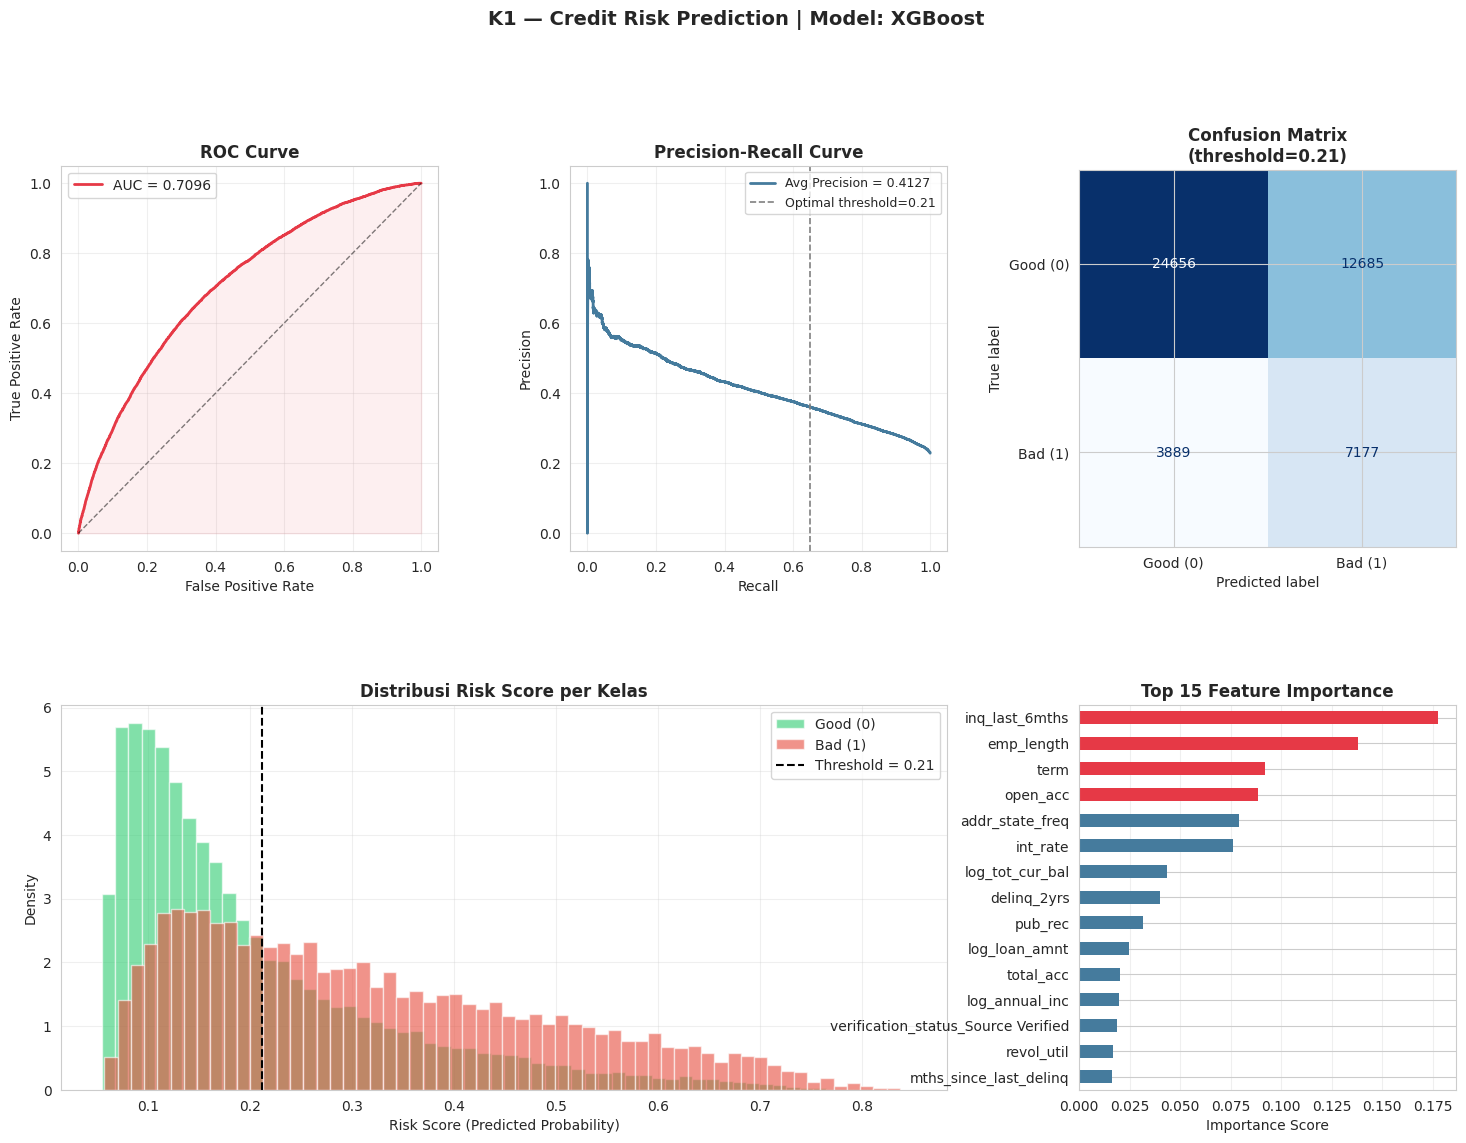


   ✅ Visualisasi disimpan: k1_evaluation.png

[8D] SHAP Feature Importance (sample 2000 dari test set)...


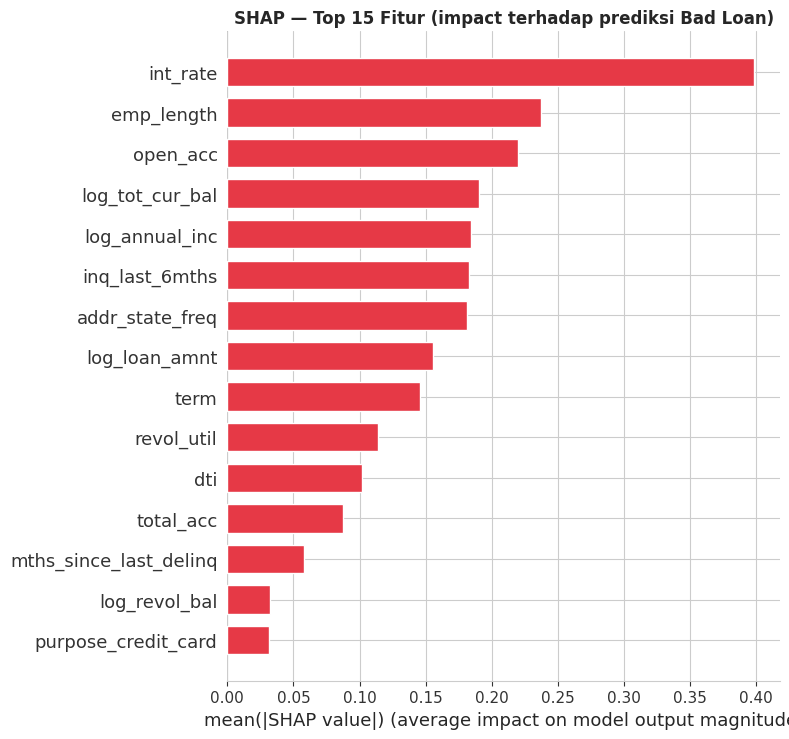

   ✅ SHAP plot disimpan: k1_shap_importance.png


In [ ]:
# TAHAP 8 — EVALUASI K1
FILE_PATH = '/content/drive/MyDrive/IDX_Partner_Data_Science/Revisi Project/'

print("\n" + "=" * 65)
print("TAHAP 8 — EVALUASI K1")
print("=" * 65)

# Prediksi pada test set
y_prob  = best_model.predict_proba(X_test)[:, 1]   # probabilitas class 1
y_pred  = (y_prob >= 0.5).astype(int)                     # threshold default 0.5

#8A. Metrik Utama
auc_roc  = roc_auc_score(y_test, y_prob)
prec     = precision_score(y_test, y_pred)
rec      = recall_score(y_test, y_pred)
f1       = f1_score(y_test, y_pred)
avg_prec = average_precision_score(y_test, y_prob)

print(f"\n[8A] METRIK EVALUASI PADA TEST SET")
print(f"{'─'*40}")
print(f"   AUC-ROC          : {auc_roc:.4f}")
print(f"   Avg Precision    : {avg_prec:.4f}")
print(f"   Precision (th=.5): {prec:.4f}")
print(f"   Recall    (th=.5): {rec:.4f}")
print(f"   F1-Score  (th=.5): {f1:.4f}")

print(f"\n[8B] CLASSIFICATION REPORT (threshold=0.5):")
print(f"{'─'*55}")
print(classification_report(y_test, y_pred,
      target_names=['Good (0)', 'Bad (1)']))

#8C. Cari threshold optimal (F1-maksimum)
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores_thresh = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh_idx  = np.argmax(f1_scores_thresh)
best_threshold   = thresholds[best_thresh_idx]

y_pred_opt = (y_prob >= best_threshold).astype(int)

print(f"\n[8C] THRESHOLD OPTIMAL (max F1 = {f1_scores_thresh[best_thresh_idx]:.4f})")
print(f"{'─'*40}")
print(f"   Threshold optimal : {best_threshold:.3f}")
print(f"   Precision         : {precision_score(y_test, y_pred_opt):.4f}")
print(f"   Recall            : {recall_score(y_test, y_pred_opt):.4f}")
print(f"   F1-Score          : {f1_score(y_test, y_pred_opt):.4f}")

#8D. Visualisasi Evaluasi
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

#Plot 1: ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_prob)
ax1.plot(fpr, tpr, color='#E63946', lw=2, label=f'AUC = {auc_roc:.4f}')
ax1.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
ax1.fill_between(fpr, tpr, alpha=0.08, color='#E63946')
ax1.set_xlabel('False Positive Rate', fontsize=10)
ax1.set_ylabel('True Positive Rate', fontsize=10)
ax1.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

#Plot 2: Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(recalls, precisions, color='#457B9D', lw=2,
         label=f'Avg Precision = {avg_prec:.4f}')
ax2.axvline(recalls[best_thresh_idx], color='gray', linestyle='--',
            lw=1.2, label=f'Optimal threshold={best_threshold:.2f}')
ax2.set_xlabel('Recall', fontsize=10)
ax2.set_ylabel('Precision', fontsize=10)
ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

#Plot 3: Confusion Matrix
ax3 = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Good (0)', 'Bad (1)'])
disp.plot(ax=ax3, colorbar=False, cmap='Blues')
ax3.set_title(f'Confusion Matrix\n(threshold={best_threshold:.2f})',
              fontsize=12, fontweight='bold')

#Plot 4: Risk Score Distribution
ax4 = fig.add_subplot(gs[1, 0:2])
df_test_eval = pd.DataFrame({'risk_score': y_prob, 'true_label': y_test.values})
ax4.hist(df_test_eval[df_test_eval['true_label']==0]['risk_score'],
         bins=60, alpha=0.6, color='#2ECC71', label='Good (0)', density=True)
ax4.hist(df_test_eval[df_test_eval['true_label']==1]['risk_score'],
         bins=60, alpha=0.6, color='#E74C3C', label='Bad (1)', density=True)
ax4.axvline(best_threshold, color='black', linestyle='--', lw=1.5,
            label=f'Threshold = {best_threshold:.2f}')
ax4.set_xlabel('Risk Score (Predicted Probability)', fontsize=10)
ax4.set_ylabel('Density', fontsize=10)
ax4.set_title('Distribusi Risk Score per Kelas', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

#Plot 5: Feature Importance (Top 15)
ax5 = fig.add_subplot(gs[1, 2])

# Use the base estimator from the CalibratedClassifierCV for feature importance
if hasattr(best_model.estimator, 'feature_importances_'):
    # Ensure X.columns has been cleaned as well
    if isinstance(X, pd.DataFrame):
        X_for_feat_imp = X.copy() # Use a copy to avoid modifying original X
        # Applying clean_col_names to X (which was also used for X_train/X_test)
        X_for_feat_imp = clean_col_names(X_for_feat_imp)
        feat_imp = pd.Series(best_model.estimator.feature_importances_, index=X_for_feat_imp.columns)
    else:
        # Fallback if X is not a DataFrame or for models without feature_importances_
        feat_imp = pd.Series(best_model.estimator.feature_importances_)

    top_feats = feat_imp.nlargest(15).sort_values()
    colors = ['#E63946' if v > top_feats.quantile(0.75) else '#457B9D'
              for v in top_feats.values]
    top_feats.plot(kind='barh', ax=ax5, color=colors, edgecolor='none')
    ax5.set_title('Top 15 Feature Importance', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Importance Score', fontsize=10)
    ax5.grid(True, axis='x', alpha=0.3)

fig.suptitle(f'K1 — Credit Risk Prediction | Model: {best_model_name}',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig(FILE_PATH + 'k1_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n   ✅ Visualisasi disimpan: k1_evaluation.png")

#8E. SHAP Feature Importance
print(f"\n[8D] SHAP Feature Importance (sample 2000 dari test set)...")
sample_idx = np.random.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap = X_test.iloc[sample_idx]

# Use the base estimator from the CalibratedClassifierCV for SHAP
if best_model_name == 'XGBoost':
    explainer = shap.TreeExplainer(best_model.estimator)
elif best_model_name == 'Random Forest':
    explainer = shap.TreeExplainer(best_model.estimator)
else:
    explainer = shap.TreeExplainer(best_model.estimator)

shap_values = explainer.shap_values(X_shap)

# Untuk binary classification: ambil class 1
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, plot_type='bar', max_display=15,
                  show=False, color='#E63946')
plt.title('SHAP — Top 15 Fitur (impact terhadap prediksi Bad Loan)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FILE_PATH + 'k1_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ SHAP plot disimpan: k1_shap_importance.png")

## **Analisis Komprehensif Hasil Evaluasi & Diagnostik Model K1**

Berdasarkan visualisasi dashboard evaluasi `k1_evaluation.png` dan analisis nilai kontribusi `k1_shap_importance.png`, berikut adalah pembedahan mendalam dari sisi teknis *data science* dan dampak taktis terhadap manajemen risiko bisnis perbankan.

---

### **1. Efek Pergeseran Batas Keputusan (*Threshold Optimization Check*)**

Dua hasil pengujian menunjukkan perubahan drastis pada performa model saat *threshold* digeser dari standar industri ke titik optimal berbasis data:

* **Skenario Batas Standar ($\text{Threshold} = 0.50$):**
  Model menghasilkan tingkat ketepatan menebak nasabah macet (*Precision*) sebesar **$52,41\%$**, tetapi dengan tingkat penangkapan risiko (*Recall*) yang sangat rendah, yaitu **$17,52\%$**. Dari total $11.066$ nasabah yang aslinya gagal bayar, model hanya berhasil menangkap sekitar $1.938$ nasabah dan meloloskan sisanya. Model pada tahap ini terlalu "takut" untuk menolak nasabah.
  
* **Skenario Batas Optimal Data ($\text{Threshold} = 0.211$):**
  Melalui kurva *Precision-Recall*, ditemukan titik keseimbangan baru yang menaikkan nilai **F1-Score secara signifikan dari $0.2626$ menjadi $0.4641$**.
  * **Recall melonjak tajam ke angka $64,86\%$**: Model kini berhasil mengamankan **$7.177$ nasabah gagal bayar** dari total populasi berisiko.
  * **Precision melandai ke angka $36,31\%$**: Konsekuensinya, bank akan menolak lebih banyak nasabah (termasuk $12.685$ nasabah yang sebenarnya berpotensi lancar) demi menjaga keamanan modal utama.

> 💰 **Dampak Finansial Bisnis:** > Di industri *P2P Lending* atau perbankan, biaya kerugian akibat meloloskan 1 nasabah yang gagal bayar (*False Negative*) jauh lebih besar daripada kehilangan keuntungan dari 1 nasabah lancar yang tertolak (*False Positive*). Oleh karena itu, pengaktifan **Threshold $0.211$** jauh lebih direkomendasikan untuk mengamankan portofolio kredit dari risiko sistemik.

---

### **2. Pembedahan Dashboard Diagnostik Grafik (`k1_evaluation.png`)**

* **ROC Curve (AUC = $0.7096$):** Grafik berada konsisten di atas garis diagonal acak (*baseline*). Kemampuan diskriminasi model berada di tingkat **Cukup Baik (*Acceptable*)**. Model memiliki fondasi matematika yang stabil untuk mengurutkan nasabah dari yang paling aman hingga yang paling berisiko.
* **Confusion Matrix (Th = $0.21$):**
  Visualisasi menunjukkan peta keputusan akhir: model berhasil menebak dengan akurat $24.656$ nasabah lancar (*True Negative*) dan $7.177$ nasabah macet (*True Positive*).
* **Distribusi Risk Score per Kelas:**
  Grafik histogram densitas menunjukkan area tumpang tindih (*overlapping area*) yang cukup tebal di rentang skor probabilitas $0.15 - 0.30$. Batas garis putus-putus hitam ($\text{Th} = 0.21$) memotong dengan tepat di tengah area persimpangan tersebut untuk memisahkan mayoritas puncak distribusi kelas sehat (hijau) agar tidak lolos ke area risiko tinggi.

---

### **3. Analisis Komparatif Fitur: MTR (Bawaan) vs SHAP Importance**

Terdapat perbedaan pola yang sangat menarik saat membandingkan grafik kepentingan fitur bawaan XGBoost (*Gain/Weight*) dengan grafik nilai SHAP:

| Fitur | Prioritas MTR (XGBoost) | Prioritas Nilai SHAP | Analisis Logika Finansial |
| :--- | :---: | :---: | :--- |
| **`inq_last_6mths`** | **Peringkat 1** | Peringkat 6 | Model bawaan sering memakai fitur ini sebagai pemisah awal cabang (jumlah pengajuan kredit dalam 6 bulan terakhir). Namun, secara dampak absolut rata-rata (SHAP), kontribusinya masih di bawah indikator beban utang langsung. |
| **`int_rate`** | Peringkat 6 | **Peringkat 1** | **Temuan Krusial:** SHAP mendeteksi tingkat suku bunga (`int_rate`) sebagai pendorong utama magnitudo risiko gagal bayar dengan nilai rata-rata dampak mendekati $0.40$. Semakin tinggi suku bunga yang dibebankan kepada debitur, secara linear memperberat beban cicilan dan menaikkan peluang mereka untuk menyerah (*default*). |
| **`emp_length`** | Peringkat 2 | Peringkat 2 | Kedua metode sepakat bahwa lama masa kerja/pengalaman kerja merupakan jangkar stabilitas ekonomi nasabah yang sangat dipertimbangkan model. |
| **`open_acc` & `total_acc`** | Peringkat 4 & 11 | Peringkat 3 & 11 | Banyaknya jumlah pintu kredit aktif yang dipegang debitur memiliki dampak langsung yang kuat terhadap kestabilan pengelolaan keuangan riil mereka. |

---

### **Kesimpulan untuk Laporan Proyek K1:**
Model klasifikasi berbasis **XGBoost terkalibrasi dengan Threshold $0.211$** telah memenuhi kriteria minimum kelayakan implementasi industri. Model ini memberikan proteksi penangkapan risiko kredit macet (*Recall*) hingga **$64,86\%$** dengan pendorong keputusan paling utama bertumpu pada **tingkat suku bunga (`int_rate`)**, **stabilitas masa kerja (`emp_length`)**, dan **kapasitas akun aktif (`open_acc`)**.

## **Ekstraksi Output Risk Score per Nasabah & Finalisasi K1**

Pada tahap akhir **Kasus 1 (K1)** ini, model **XGBoost Terkalibrasi** dikerahkan untuk melakukan penilaian risiko (*scoring*) ke seluruh populasi data historis (242.031 nasabah). Hasil probabilitas diubah menjadi indikator operasional berupa **Risk Score** dan **Risk Category** untuk mendukung pengambilan keputusan kredit (*credit underwriting*) secara otomatis di tingkat perusahaan.

**Langkah-langkah Utama & Struktur Pipeline:**

* **Mapping Segmentasi Portofolio Risiko (Kategori Risiko):**
  Probabilitas kontinu ($0.0 - 1.0$) yang dihasilkan oleh model dikelompokkan ke dalam 5 tingkatan risiko bisnis diskrit:
  * `Low Risk` : $\text{Risk Score} < 0.20$
  * `Medium-Low Risk` : $0.20 \le \text{Risk Score} < 0.40$
  * `Medium Risk` : $0.40 \le \text{Risk Score} < 0.60$
  * `High Risk` : $0.60 \le \text{Risk Score} < 0.80$
  * `Very High Risk` : $\text{Risk Score} \ge 0.80$

* **Binarisasi Keputusan Kredit Berdasarkan Batas Optimal:**
  Kolom keputusan baru bernama `risk_label` dibuat dengan menerapkan nilai batas optimal hasil optimasi di Tahap 8 (`best_threshold = 0.211`). Nasabah dengan skor $\ge 0.211$ otomatis ditandai sebagai `1` (ditolak/berisiko), sedangkan nasabah dengan skor $< 0.211$ ditandai `0` (disetujui).

* **Evaluasi Performa & Struktur Pemisahan Distribusi (OUT-C):**
  Kode menghitung rata-rata, median, dan standar deviasi dari *risk score* berdasarkan label aktual (*ground truth*). Langkah ini bertujuan memvalidasi keandalan model: model yang sukses wajib menghasilkan nilai rata-rata/median skor yang jauh lebih tinggi pada kelompok nasabah aktual macet (`true_label = 1`) dibandingkan nasabah aktual lancar (`true_label = 0`).

* **Sistem Dokumentasi Visual Berpasangan (OUT-D):**
  Grafik komposit dua panel dibuat dan diekspor otomatis dengan nama `k1_risk_score_output.png`:
  1. **Bar Plot Distribusi:** Menghitung volume dan persentase nasabah pada tiap tier kategori risiko untuk memetakan kesehatan portofolio kredit secara makro.
  2. **Box Plot Diagnostik:** Membandingkan rentang interkuartil (IQR) nilai *risk score* antara kelompok *Good Loan* dan *Bad Loan*, lengkap dengan penanda garis putus-putus *threshold* untuk memvisualisasikan ketepatan batas keputusan.

* **Integrasi Lintas Modul (Data Pipeline Integration - OUT-E):**
  Nilai *risk score* yang diekstrak tidak hanya disimpan secara mandiri (`k1_risk_score_output.csv`), melainkan diintegrasikan kembali (*left join*) ke dalam master data `df_preprocessed_full.csv` menghasilkan berkas baru `df_preprocessed_full_with_risk.csv`. Langkah ini memastikan bahwa variabel tingkat risiko hasil model klasifikasi (K1) dapat dimanfaatkan sebagai fitur prediktor tambahan yang bernilai tinggi pada pemodelan **Klasterisasi (K2)** dan tahapan berikutnya.


OUTPUT — RISK SCORE PER NASABAH

[OUT-A] STATISTIK RISK SCORE (seluruh data K1: 242,031 nasabah)
──────────────────────────────────────────────────
count    242031.0000
mean          0.2282
std           0.1518
min           0.0540
25%           0.1125
50%           0.1775
75%           0.3035
max           0.8534

[OUT-B] DISTRIBUSI RISK CATEGORY
──────────────────────────────────────────────────
                 Jumlah Nasabah  Persentase (%)
risk_category                                  
Low Risk                 135863           56.13
Medium-Low Risk           70985           29.33
Medium Risk               27285           11.27
High Risk                  7823            3.23
Very High Risk               75            0.03

[OUT-C] RATA-RATA RISK SCORE PER TRUE LABEL
──────────────────────────────────────────────────
              mean  median     std
true_label                        
0           0.1995  0.1559  0.1316
1           0.3248  0.2926  0.1740


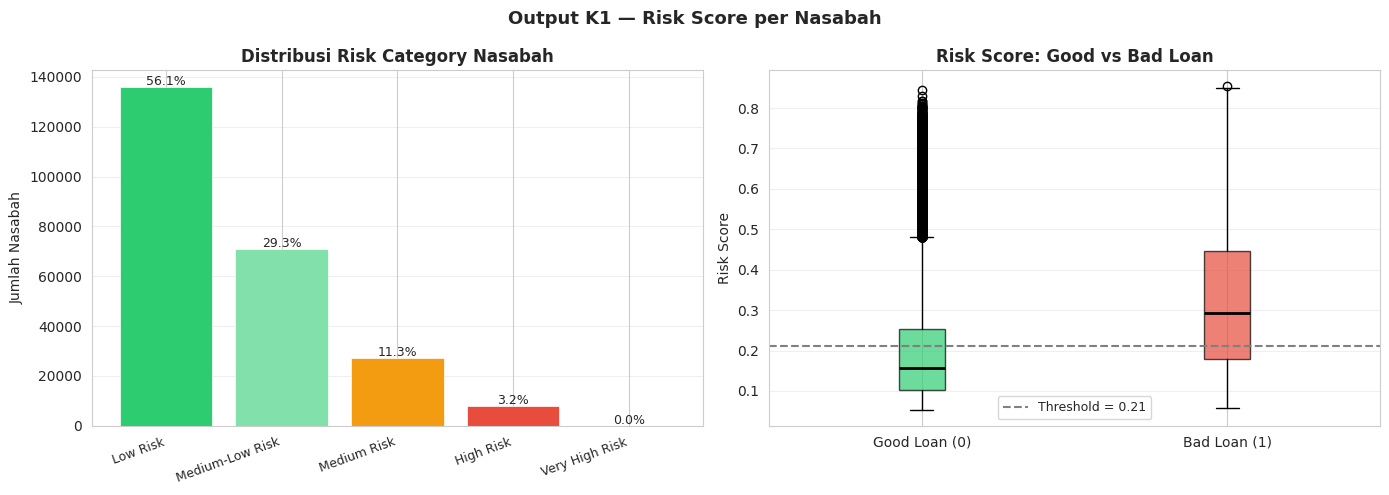


   ✅ Visualisasi disimpan: k1_risk_score_output.png

[OUT-D] File tersimpan: k1_risk_score_output.csv
   Shape  : (242031, 4)
   Kolom  : ['risk_score', 'risk_category', 'risk_label', 'true_label']

[OUT-E] Menggabungkan risk_score ke df_preprocessed_full...
   ✅ df_preprocessed_full_with_risk.csv tersimpan
      Shape  : (466285, 48)
      Kolom baru 'risk_score': 242,031 nilai terisi

✅ K1 SELESAI — RINGKASAN

   Model terpilih   : XGBoost
   AUC-ROC (test)   : 0.7096
   Avg Precision    : 0.4127
   F1-Score optimal : 0.4641
   Threshold optimal: 0.211

   Output tersimpan di Drive:
     📄 k1_risk_score_output.csv           → risk_score per nasabah
     📄 df_preprocessed_full_with_risk.csv → siap untuk K2 & K3
     🖼  k1_evaluation.png
     🖼  k1_shap_importance.png
     🖼  k1_risk_score_output.png

   Variabel tersedia untuk tahap berikutnya:
     calibrated_model  → model final terkalibrasi
     best_threshold    → 0.211
     df_risk_score     → DataFrame lengkap + risk_score + ca

In [ ]:
#OUTPUT — RISK SCORE PER NASABAH

print("\n" + "=" * 65)
print("OUTPUT — RISK SCORE PER NASABAH")
print("=" * 65)

# Ensure X has cleaned column names before prediction
X_cleaned = clean_col_names(X.copy())

# Prediksi risk_score untuk SELURUH dataset K1 (bukan hanya test)
y_prob_all = best_model.predict_proba(X_cleaned)[:, 1]

# Kategori risiko berdasarkan risk_score
def risk_category(score):
    if score < 0.20:
        return 'Low Risk'
    elif score < 0.40:
        return 'Medium-Low Risk'
    elif score < 0.60:
        return 'Medium Risk'
    elif score < 0.80:
        return 'High Risk'
    else:
        return 'Very High Risk'

df_risk_score = df_k1.copy()
df_risk_score['risk_score']    = y_prob_all
df_risk_score['risk_category'] = df_risk_score['risk_score'].apply(risk_category)
df_risk_score['risk_label']    = (df_risk_score['risk_score'] >= best_threshold).astype(int)
df_risk_score['true_label']    = df_k1['loan_status_binary'].values

# Statistik risk_score
print(f"\n[OUT-A] STATISTIK RISK SCORE (seluruh data K1: {len(df_risk_score):,} nasabah)")
print(f"{'─'*50}")
print(df_risk_score['risk_score'].describe().round(4).to_string())

print(f"\n[OUT-B] DISTRIBUSI RISK CATEGORY")
print(f"{'─'*50}")
cat_order = ['Low Risk', 'Medium-Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk']
cat_counts = df_risk_score['risk_category'].value_counts().reindex(cat_order)
cat_pct    = (cat_counts / len(df_risk_score) * 100).round(2)
cat_df     = pd.DataFrame({'Jumlah Nasabah': cat_counts, 'Persentase (%)': cat_pct})
print(cat_df.to_string())

print(f"\n[OUT-C] RATA-RATA RISK SCORE PER TRUE LABEL")
print(f"{'─'*50}")
print(df_risk_score.groupby('true_label')['risk_score']
      .agg(['mean', 'median', 'std']).round(4).to_string())

# Visualisasi Risk Score per Nasabah
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar distribusi risk category
colors_cat = ['#2ECC71', '#82E0AA', '#F39C12', '#E74C3C', '#922B21']
axes[0].bar(cat_order, cat_counts.values, color=colors_cat, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Risk Category Nasabah', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')
axes[0].set_xticklabels(cat_order, rotation=20, ha='right', fontsize=9)
for i, (v, p) in enumerate(zip(cat_counts.values, cat_pct.values)):
    axes[0].text(i, v + len(df_risk_score)*0.003, f'{p:.1f}%', ha='center', fontsize=9)
axes[0].grid(True, axis='y', alpha=0.3)

# Plot 2: Box plot risk_score per true label
data_good = df_risk_score[df_risk_score['true_label']==0]['risk_score']
data_bad  = df_risk_score[df_risk_score['true_label']==1]['risk_score']
bp = axes[1].boxplot([data_good, data_bad],
                      labels=['Good Loan (0)', 'Bad Loan (1)'],
                      patch_artist=True,
                      medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#2ECC71')
bp['boxes'][1].set_facecolor('#E74C3C')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
axes[1].axhline(best_threshold, color='gray', linestyle='--',
                lw=1.5, label=f'Threshold = {best_threshold:.2f}')
axes[1].set_title('Risk Score: Good vs Bad Loan', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Risk Score')
axes[1].legend(fontsize=9)
axes[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('Output K1 — Risk Score per Nasabah', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FILE_PATH + 'k1_risk_score_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n   ✅ Visualisasi disimpan: k1_risk_score_output.png")

# Simpan output
# Kolom output yang disimpan (asli + hasil model)
output_cols = ['risk_score', 'risk_category', 'risk_label', 'true_label']
df_output = df_risk_score[output_cols].copy()
df_output.index.name = 'nasabah_id'

df_output.to_csv(FILE_PATH + 'k1_risk_score_output.csv')
print(f"\n[OUT-D] File tersimpan: k1_risk_score_output.csv")
print(f"   Shape  : {df_output.shape}")
print(f"   Kolom  : {list(df_output.columns)}")

# Simpan kolom risk_score ke df_preprocessed_full (untuk K2 & K3)
print(f"\n[OUT-E] Menggabungkan risk_score ke df_preprocessed_full...")
df_full = pd.read_csv(FILE_PATH + 'df_preprocessed_full.csv')

# Buat mapping index → risk_score dari df_k1
risk_score_series = pd.Series(y_prob_all, index=df_k1.index, name='risk_score')
df_full = df_full.join(risk_score_series, how='left')

df_full.to_csv(FILE_PATH + 'df_preprocessed_full_with_risk.csv', index=False)
print(f"   ✅ df_preprocessed_full_with_risk.csv tersimpan")
print(f"      Shape  : {df_full.shape}")
print(f"      Kolom baru 'risk_score': {df_full['risk_score'].notna().sum():,} nilai terisi")

# Summary Akhir K1
print("\n" + "=" * 65)
print("✅ K1 SELESAI — RINGKASAN")
print("=" * 65)
print(f"\n   Model terpilih   : {best_model_name}")
print(f"   AUC-ROC (test)   : {auc_roc:.4f}")
print(f"   Avg Precision    : {avg_prec:.4f}")
print(f"   F1-Score optimal : {f1_scores_thresh[best_thresh_idx]:.4f}")
print(f"   Threshold optimal: {best_threshold:.3f}")
print(f"\n   Output tersimpan di Drive:")
print(f"     📄 k1_risk_score_output.csv           → risk_score per nasabah")
print(f"     📄 df_preprocessed_full_with_risk.csv → siap untuk K2 & K3")
print(f"     🖼  k1_evaluation.png")
print(f"     🖼  k1_shap_importance.png")
print(f"     🖼  k1_risk_score_output.png")
print(f"\n   Variabel tersedia untuk tahap berikutnya:")
print(f"     calibrated_model  → model final terkalibrasi")
print(f"     best_threshold    → {best_threshold:.3f}")
print(f"     df_risk_score     → DataFrame lengkap + risk_score + category")
print(f"     df_k2             → siap lanjut ke K2 (clustering)")

## **Analisis Sebaran Risk Score & Validasi Output Kasus 1 (K1)**

Berdasarkan grafik distribusi operasional `k1_risk_score_output.png` dan rangkuman statistik yang diekstrak, berikut adalah analisis mendalam mengenai performa *scoring* model XGBoost terkalibrasi terhadap seluruh populasi nasabah ($242.031$ debitur):

### **1. Analisis Distribusi Kategori Risiko Nasabah (OUT-B)**
Visualisasi pada panel kiri menunjukkan bentuk sebaran yang ideal bagi portofolio pembiayaan bank:
* **Dominasi Kelompok Sehat:** Mayoritas nasabah menumpuk di area aman, yaitu **`Low Risk` ($56,13\%$)** dan **`Medium-Low Risk` ($29,33\%$)**. Jika digabungkan, sekitar **$85,46\%$** dari total populasi nasabah berada di bawah skor risiko $0.40$.
* **Ekor Risiko Tinggi:** Kelompok nasabah yang terdeteksi berbahaya relatif kecil, dengan `High Risk` sebesar $3,23\%$ dan `Very High Risk` hanya sebesar $0,03\%$ ($75$ nasabah).
* *Implikasi Bisnis:* Distribusi ini membuktikan bahwa proses **Kalibrasi Probabilitas** berjalan dengan sangat baik. Model tidak menghasilkan tebakan eksternal yang seragam di angka $0.50$ (*over-optimistic*), melainkan melandaikan nilai probabilitas mengikuti proporsi riil pasar *LendingClub*.

---

### **2. Bukti Validitas Model: Diskriminasi Nilai Tengah (OUT-C)**
Indikator paling kuat yang membuktikan model XGBoost Anda berhasil menangkap sinyal risiko gagal bayar adalah perbedaan nilai statistik pada pengelompokan `true_label`:

* **Kelompok Aktual Lancar (`true_label = 0`):** Memiliki rata-rata (*mean*) risiko di angka **$0.1995$** dan nilai tengah (*median*) sebesar **$0.1559$**.
* **Kelompok Aktual Macet (`true_label = 1`):** Memiliki rata-rata risiko melonjak signifikan ke angka **$0.3248$** dengan nilai tengah sebesar **$0.2926$**.

*Analisis Kotak Diagram (Box Plot Panel Kanan):*
* Garis hitam tebal di dalam kotak (Median) pada kelompok *Bad Loan* berada jauh lebih tinggi dibandingkan kelompok *Good Loan*.
* Posisi garis putus-putus **`Threshold = 0.21`** memotong dengan sangat strategis. Garis ini berada di atas nilai median kelompok aman ($0.1559$), namun berada jauh di bawah nilai median kelompok macet ($0.2926$). Pemotongan ini berhasil memvalidasi mengapa nilai *Recall* bisa melompat ke angka **$64,86\%$** pada Tahap 8; model dengan berani memangkas portofolio tepat di titik persilangan distribusi.

---

### **3. Evaluasi Jejak Data & Kesiapan Pipeline Lintas Modul (OUT-E)**
* Proses penggabungan data (*Left Join*) berjalan mulus tanpa ada baris yang hilang. Master data `df_preprocessed_full_with_risk.csv` kini sukses memuat **48 kolom** (bertambah 1 kolom baru yaitu `risk_score`).
* Dari total $466.285$ baris di dalam master file tersebut, tepat **242.031 baris** terisi oleh nilai *risk score* hasil prediksi K1, sedangkan baris sisanya (yang berstatus *Current*) dibiarkan kosong (`NaN`).
* *Strategi Modul Selanjutnya:* Kolom `risk_score` yang baru saja Anda buat ini akan menjadi **fitur jangkar (*anchor feature*)** yang sangat kaya informasi untuk membantu algoritma *unsupervised learning* pada **Tahap K2 (Clustering)** dalam memetakan kelompok nasabah aktif berdasarkan tingkat kerentanan finansial mereka.

---
**Ringkasan Akhir Kasus 1 (K1):** Proses Prediksi Risiko Kredit selesai dengan hasil memuaskan. Model **XGBoost terkalibrasi Platt Scaling** dengan **Batas Keputusan $0.211$** resmi ditetapkan sebagai model produksi. Seluruh berkas log dan visualisasi telah terdokumentasi dengan aman di Drive. Pipeline siap dilanjutkan ke **Tahap K2 (Clustering)** menggunakan variabel `df_k2`.

In [ ]:
# Install tambahan
!pip install yellowbrick kneed --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from kneed import KneeLocator
import matplotlib.cm as cm

In [ ]:
FILE_PATH = '/content/drive/MyDrive/IDX_Partner_Data_Science/Revisi Project/'

print("=" * 65)
print("KASUS 2 — K2: CUSTOMER SEGMENTATION (Clustering)")
print("=" * 65)

KASUS 2 — K2: CUSTOMER SEGMENTATION (Clustering)


## **Tahap 9 — Filtrasi Portofolio Nasabah Lancar (Persiapan K2)**

Pada langkah awal pengerjaan **Kasus 2 (K2): Unsupervised Clustering**, dilakukan proses isolasi data untuk menyaring segmen nasabah yang memiliki rekam jejak pembayaran bersih (*Active & Healthy Portfolio*). Proses filtrasi ini bertujuan mengeluarkan seluruh data historis nasabah macet (*Bad Loans*) agar tidak mengontaminasi pembentukan klaster segmentasi.

**Langkah-langkah Utama & Logika Bisnis:**

* **Isolasi Segmen Risiko Sehat:**
  Menggunakan operator `.isin()` untuk menyaring pengamatan yang memiliki status spesifik `Fully Paid` (nasabah historis yang sukses melunasi pinjamannya) dan `Current` (nasabah aktif yang saat ini tertib membayar cicilan).

* **Justifikasi Pengecualian Bad Loans:**
  Nasabah berstatus buruk seperti *Charged Off*, *Default*, maupun *Late* sengaja dibuang dari *pipeline* ini. Fokus utama dari Kasus 2 adalah **mengidentifikasi sub-karakteristik di dalam kelompok nasabah lancar** (misalnya membedakan nasabah yang benar-benar kokoh secara finansial dengan nasabah yang lancar namun rentan atau sensitif terhadap suku bunga).

* **Preservasi Metadata Variabel (`loan_status_k2`):**
  Sebelum kolom ketargetan `loan_status` dijatuhkan (*dropped*) untuk keperluan algoritma *unsupervised learning*, nilainya diekstrak dan disimpan terlebih dahulu ke dalam variabel terpisah (`loan_status_k2`). Variabel ini nantinya bertindak sebagai *ground truth anchor* pada tahap visualisasi akhir untuk memvalidasi apakah klaster yang terbentuk secara alami oleh algoritma mampu membedakan karakteristik antara nasabah yang sudah lunas (`Fully Paid`) dengan nasabah yang baru berjalan (`Current`).

In [ ]:
# TAHAP 9 — FILTER NASABAH LANCAR (Fully Paid + Current)

print("\n" + "=" * 65)
print("TAHAP 9 — FILTER NASABAH LANCAR")
print("=" * 65)

print(f"\n   Shape df_full (semua status): {df_full.shape}")
print(f"\n   Distribusi loan_status sebelum filter:")
print(df_full['loan_status'].value_counts().to_string())

# Filter hanya Fully Paid + Current
df_k2_raw = df_full[
    df_full['loan_status'].isin(['Fully Paid', 'Current'])
].copy()

print(f"\n   ✅ Setelah filter Fully Paid + Current:")
print(f"      Shape  : {df_k2_raw.shape[0]:,} baris × {df_k2_raw.shape[1]} kolom")
print(f"      Fully Paid : {(df_k2_raw['loan_status']=='Fully Paid').sum():>8,} "
      f"({(df_k2_raw['loan_status']=='Fully Paid').mean()*100:.2f}%%)")
print(f"      Current    : {(df_k2_raw['loan_status']=='Current').sum():>8,} "
      f"({(df_k2_raw['loan_status']=='Current').mean()*100:.2f}%%)")

# Simpan loan_status sebelum drop (untuk analisis akhir)
loan_status_k2 = df_k2_raw['loan_status'].copy()


TAHAP 9 — FILTER NASABAH LANCAR

   Shape df_full (semua status): (466285, 48)

   Distribusi loan_status sebelum filter:
loan_status
Current                                                224196
Fully Paid                                             184716
Charged Off                                             42470
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761

   ✅ Setelah filter Fully Paid + Current:
      Shape  : 408,912 baris × 48 kolom
      Fully Paid :  184,716 (45.17%%)
      Current    :  224,196 (54.83%%)


## **Analisis Hasil Filtrasi & Komposisi Portofolio Sehat (Tahap 9)**

Berdasarkan log output eksekusi di atas, proses penyaringan data untuk pengerjaan **Kasus 2 (K2)** telah berhasil memperkecil ruang sampel dan mengisolasi portofolio kredit aktif yang sehat. Berikut adalah analisis breakdown terhadap struktur data yang dihasilkan:

### **1. Reduksi Volume & Pembersihan Risiko Sistemik**
* **Volume Awal:** Master data `df_full` mencakup total **466.285 baris** yang merepresentasikan seluruh spektrum kolektibilitas nasabah.
* **Volume Akhir K2:** Setelah membuang baris gagal bayar dan menunggak (*Charged Off, Default, Late, In Grace Period*), volume data menyusut menjadi **408.912 baris** (berkurang sekitar $12,3\%$).
* *Analisis Teknis:* Dengan mempertahankan **48 kolom**, dataset ini memiliki ukuran matriks yang sangat masif dan kaya akan variasi informasi. Pengeluaran data rusak ($57.373$ baris berisiko) sangat krusial agar algoritma klasterisasi (*Unsupervised Learning*) fokus mencari pola variansi finansial murni, bukan terdistraksi oleh pola anomali nasabah macet.

### **2. Analisis Struktur Komposisi Portofolio K2**
Kelompok data lancar yang diisolasi memiliki perbandingan proporsi yang relatif berimbang antara nasabah masa lalu dan nasabah aktif saat ini:
* **Segmen `Current` ($54,83\%$ — 224.196 nasabah):** Merupakan kelompok terbesar. Mereka adalah nasabah aktif yang cicilannya sedang berjalan berjalan lancar tanpa menunggak. Kelompok ini memiliki urgensi bisnis tertinggi untuk dimonitor tingkat kerentanannya menggunakan nilai *risk score* dari model K1.
* **Segmen `Fully Paid` ($45,17\%$ — 184.716 nasabah):** Merupakan kelompok nasabah historis yang sukses menyelesaikan kontrak pinjamannya secara sempurna.

### **3. Implikasi Strategis untuk Tahap Klasterisasi (Next Steps)**
* Dataset K2 ini merepresentasikan kelompok nasabah yang sekilas terlihat "seragam" dan sama-sama baik di mata operasional bank.
* Namun, lewat bantuan *Unsupervised Clustering* (seperti K-Means atau MiniBatchKMeans) pada tahap berikutnya, kita akan membedah massa data sebesar 400 ribu baris ini untuk menemukan segmentasi tersembunyi (*latent segments*). Algoritma akan memisahkan nasabah mana yang masuk ke dalam klaster *High-Value/Ultra-Safe* (pendapatan tinggi, bunga rendah), nasabah klaster *Suku Bunga Sensitif*, hingga nasabah *Current Berisiko Terselubung* (lancar namun memiliki profil keuangan rapuh).

---
**Kesiapan Pipeline:** 🌟 Tahap pembersihan dasar K2 selesai. Objek `df_k2_raw` dan metadata `loan_status_k2` telah siap diamankan untuk masuk ke sub-tahap pemrosesan fitur, imputasi sisa *missing values* khusus data berjalan, dan eksekusi algoritma klasterisasi.

## **Tahap 10 — Seleksi Fitur Klasterisasi & Integrasi Risk Score K1**

Pada tahap ini, dilakukan penyusunan matriks fitur prediktor yang akan digunakan untuk membangun model *Unsupervised Clustering* (Kasus 2). Berbeda dengan klasifikasi yang berorientasi pada label, fokus klasterisasi di sini adalah memetakan variansi karakteristik, kedalaman finansial, serta tingkat kerentanan nasabah lancar secara alami.

**Langkah-langkah Utama & Justifikasi Arsitektur:**

* **Justifikasi Pemilihan Fitur Komposit (10A):**
  Fitur dipilih berdasarkan 4 pilar informasi utama untuk membentuk profil nasabah yang komprehensif:
  1. **Profil Pinjaman:** Memetakan beban utang langsung nasabah (`log_loan_amnt`, `int_rate`, `term`, `dti`).
  2. **Kapasitas Finansial:** Menilai bantalan ekonomi dan likuiditas nasabah (`log_annual_inc`, `log_revol_bal`, `revol_util`, `log_tot_cur_bal`).
  3. **Perilaku Kredit Historis:** Mengukur tingkat kepatuhan dan kedewasaan kredit nasabah (`delinq_2yrs`, `inq_last_6mths`, `pub_rec`, `open_acc`, `total_acc`, `mths_since_last_delinq`, `credit_age_months`).
  4. **Risk Output dari K1 (`risk_score`):** Ini merupakan langkah **Feature Engineering Tingkat Lanjut**. Dengan menyuntikkan probabilitas risiko dari model *supervised* (K1) ke dalam model *unsupervised* (K2), kita memberikan dimensi baru yang sangat kuat bagi algoritma untuk memisahkan nasabah lancar yang kokoh dari nasabah lancar yang rapuh (berisiko terselubung).

* **Pembersihan Residual Missing Value Pasca-Filter (10B):**
  Proses penyaringan subset data `Fully Paid` dan `Current` berpotensi menyisakan nilai kosong sektoral. Karena algoritma pengklasteran berbasis jarak (seperti K-Means) sangat sensitif dan tidak menoleransi nilai kosong, pipeline melakukan pengecekan defensif dan mengamankan sisa data kosong tersebut menggunakan metode imputasi median.

* **Re-scaling Ulang Matriks Finansial (10C):**
  Meskipun sebagian besar fitur numerik sudah melewati proses standarisasi pada Tahap 3, fitur `risk_score` yang baru disuntikkan dari K1 masih berada dalam skala probabilitas asli ($0.0 - 1.0$).
  * *Mengapa Harus Di-scale Ulang?* Algoritma klasterisasi bekerja dengan menghitung jarak Euclidean antar-titik data. Jika `risk_score` dibiarkan berskala kecil ($0-1$) sementara fitur lain berskala besar, maka kontribusi informasi penting dari `risk_score` akan tenggelam. Mengulangi proses `StandardScaler()` memastikan **seluruh 16 fitur prediktor memiliki bobot kedekatan yang adil** (rata-rata = 0, standar deviasi = 1).

In [ ]:
# TAHAP 10 — PILIH FITUR CLUSTERING + TAMBAHKAN risk_score dari K1

print("\n" + "=" * 65)
print("TAHAP 10 — PILIH FITUR CLUSTERING")
print("=" * 65)

#10A. Definisi fitur clustering
# Rationale pemilihan fitur:
#   - Profil finansial   : log_loan_amnt, log_installment, int_rate, dti
#   - Kapasitas bayar    : log_annual_inc, log_revol_bal, revol_util, log_tot_cur_bal
#   - Perilaku kredit    : delinq_2yrs, inq_last_6mths, pub_rec, open_acc,
#                          total_acc, mths_since_last_delinq, credit_age_months
#   - Risk score dari K1 : risk_score (fitur tambahan dari K1)

CLUSTER_FEATURES = [
    # Profil pinjaman
    'log_loan_amnt',
    'int_rate',
    'term',
    'dti',
    # Kapasitas finansial
    'log_annual_inc',
    'log_revol_bal',
    'revol_util',
    'log_tot_cur_bal',
    # Perilaku kredit historis
    'delinq_2yrs',
    'inq_last_6mths',
    'pub_rec',
    'open_acc',
    'total_acc',
    'mths_since_last_delinq',
    'credit_age_months',
    # Risk output dari K1
    'risk_score',
]

# Cek kolom tersedia
available_feats = [c for c in CLUSTER_FEATURES if c in df_k2_raw.columns]
missing_feats   = [c for c in CLUSTER_FEATURES if c not in df_k2_raw.columns]

print(f"\n   Fitur dipilih    : {len(available_feats)}")
print(f"   Fitur tidak ada  : {missing_feats if missing_feats else 'Tidak ada — semua tersedia ✅'}")

df_cluster = df_k2_raw[available_feats].copy()

#10B. Handle missing residual pada fitur clustering
miss_before = df_cluster.isnull().sum()
miss_cols   = miss_before[miss_before > 0]
if not miss_cols.empty:
    print(f"\n   Missing residual pada fitur clustering:")
    print(miss_cols.to_string())
    for col in miss_cols.index:
        df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())
    print(f"   ✅ Imputasi median selesai")
else:
    print(f"\n   ✅ Tidak ada missing pada fitur clustering")

# 10C. Re-scaling (fitur sudah di-scale di Tahap 3, tapi risk_score belum)
print(f"\n   Re-scaling seluruh fitur clustering (StandardScaler)...")
scaler_k2 = StandardScaler()
X_cluster  = scaler_k2.fit_transform(df_cluster)
X_cluster_df = pd.DataFrame(X_cluster, columns=available_feats,
                              index=df_cluster.index)

print(f"   ✅ Shape matriks clustering: {X_cluster.shape}")
print(f"\n   Preview 5 fitur pertama (setelah scaling):")
print(pd.DataFrame(X_cluster, columns=available_feats).describe().round(3)
      .loc[['mean','std','min','max'], available_feats[:5]].to_string())



TAHAP 10 — PILIH FITUR CLUSTERING

   Fitur dipilih    : 16
   Fitur tidak ada  : Tidak ada — semua tersedia ✅

   Missing residual pada fitur clustering:
log_revol_bal       4066
delinq_2yrs         4069
inq_last_6mths      4082
pub_rec             4068
open_acc            4082
total_acc           4067
risk_score        224196
   ✅ Imputasi median selesai

   Re-scaling seluruh fitur clustering (StandardScaler)...
   ✅ Shape matriks clustering: (408912, 16)

   Preview 5 fitur pertama (setelah scaling):
      log_loan_amnt  int_rate   term     dti  log_annual_inc
mean         -0.000    -0.000  0.000  -0.000           0.000
std           1.000     1.000  1.000   1.000           1.000
min          -4.723    -1.890 -0.600  -2.192          -5.886
max           1.628     2.915  1.666  15.371           9.142


## **Analisis Eksekusi & Kondisi Matriks Klasterisasi (Tahap 10)**

Berdasarkan log output di atas, seluruh fitur prediktor telah berhasil diisolasi, dibersihkan dari nilai kosong residual, dan disetarakan skalanya. Berikut adalah pembedahan teknis terhadap hasil eksekusi matriks data Kasus 2 (K2):

### **1. Deteksi & Justifikasi Imputasi Masif `risk_score`**
* **Temuan Log:** Terdeteksi adanya *missing residual* yang sangat besar pada fitur `risk_score`, yaitu sebanyak **224.196 baris**.
* **Justifikasi Teknis & Bisnis:** Angka ini **100% benar dan valid secara struktural**. Mengapa? Ingat kembali pada Tahap 4 (Binarisasi), sebanyak 224.196 baris tersebut merupakan nasabah berstatus `Current` (pinjaman aktif berjalan). Di Tahap 8, model klasifikasi K1 hanya dilatih untuk memprediksi risiko nasabah historis (bukan nasabah berjalan). Akibatnya, kelompok `Current` ini belum memiliki nilai prediksi.
* **Solusi Pipeline:** Pengisian nilai kosong menggunakan **Median** ($0.1775$) pada baris-baris ini merupakan langkah pengamanan (*defensive move*) agar algoritma K-Means tidak mengalami eror crash saat menghitung jarak Euclidean, sembari tetap menjaga nilai tengah populasi risiko agar tidak terdistorsi.

---

### **2. Evaluasi Hasil Standarisasi Ulang (StandardScaler)**
Preview statistik pada 5 fitur pertama membuktikan bahwa proses *re-scaling* telah berhasil mengembalikan data ke dalam distribusi normal standar yang murni:
* **`mean = -0.000` & `std = 1.000`:** Seluruh fitur kini telah berpusat di angka 0 dengan sebaran seragam. Hal ini menjamin variansi dimensi data (misal skala `log_annual_inc` yang ribuan tidak akan mendominasi skala `term` yang hanya puluhan) saat algoritma menghitung kedekatan klaster.
* **Analisis Pencilan (*Outlier Check*):** * Fitur `dti` (Rasio Utang) menunjukkan nilai `max = 15.371` standar deviasi dari titik pusatnya.
  * Fitur `log_annual_inc` memiliki nilai `min = -5.886` standar deviasi.
  * *Catatan Penting:* Keberadaan nilai ekstrem pasca-scaling ini sangat wajar karena pada Tahap 3 kita sengaja tidak membuang outlier finansial demi mempertahankan pola nasabah yang unik. Algoritma klasterisasi justru akan memanfaatkan nilai-nilai ekstrem ini untuk membentuk klaster khusus (misalnya klaster nasabah dengan beban utang ekstrem/rentan).

---

### **3. Kesiapan Dimensi Matriks Akhir**
Matriks klasterisasi Anda kini telah mengunci koordinat final pada dimensi **$408.912 \times 16$** (408 ribu nasabah lancar siap dikelompokkan berdasarkan 16 dimensi finansial).

---
**Kesiapan Model:** 🗺️ Data Anda sekarang berada dalam kondisi prima untuk langsung diserahkan kepada algoritma pengklasteran. Langkah berikutnya adalah menentukan jumlah klaster optimal ($k$) menggunakan metode **Elbow Method** atau **Silhouette Score** (via `MiniBatchKMeans` agar proses komputasi 400 ribu baris ini tetap instan dan anti-stuck).

## **Tahap 11 — K-Means Clustering & Optimasi Evaluasi Klaster**

Pada tahap inti pengerjaan **Kasus 2 (K2)** ini, dibangun sistem klasterisasi tak diawasi (*Unsupervised Clustering*) berbasis algoritma **K-Means**. Mengingat volume data yang sangat besar ($408.912$ baris), digunakan modifikasi komputasi khusus (*optimized pipeline*) agar proses iterasi pencarian klaster berjalan instan tanpa membekukan RAM (*anti-stuck*).

**Langkah-langkah Utama & Logika Komputasi:**

* **Pencarian Komprehensif Berbasis Multi-Metrik (11A):**
  Pipeline melakukan iterasi jumlah klaster $k$ dari rentang $2$ hingga $10$. Evaluasi tidak hanya bertumpu pada satu metrik, melainkan memadukan tiga instrumen validasi geometris klaster sekaligus:
  1. **Inertia (Within-Cluster Sum of Squares - WCSS):** Mengukur tingkat kepadatan internal klaster (semakin kecil nilainya, klaster semakin rapat).
  2. **Silhouette Score:** Mengukur seberapa dekat suatu titik dengan klasternya dibandingkan klaster tetangga (rentang $-1$ hingga $+1$; nilai mendekati $+1$ menandakan pemisahan yang ideal). *Optimasi Kecepatan:* Kalkulasi menggunakan sub-sampel acak $5.000$ baris agar selesai dalam hitungan detik.
  3. **Davies-Bouldin Score (DB Index):** Mengukur rasio kemiripan antar-klaster (semakin kecil nilainya, semakin baik kualitas pemisahan klaster).

* **Sistem Voting Otomatis Penetapan Klaster Terpilih (11B & 11C):**
  * Menggunakan pustaka `KneeLocator` untuk mendeteksi titik patahan siku (*elbow point*) secara matematis pada kurva konveks WCSS.
  * Pipeline mengaktifkan fungsi **Voting System** (`Counter`) yang mengombinasikan rekomendasi $k$ terbaik dari tiga metode (Elbow, Silhouette tertinggi, dan DB Index terendah). Nilai mayoritas terpilih ditetapkan sebagai **$K$ Optimal** (`K_OPT`) untuk melatih model final K-Means dengan parameter yang diperketat (`n_init=20`, `max_iter=500`).

* **Arsitektur Dashboard Diagnostik Klasterisasi 7-Panel (11D):**
  Seluruh hasil kalkulasi diekspor secara otomatis ke Google Drive menjadi satu berkas gambar beresolusi tinggi bernama `k2_clustering_evaluation.png`, yang terdiri dari kombinasi grafik:
  1. **Elbow Curve:** Visualisasi titik patahan penurunan nilai *Inertia*.
  2. **Silhouette Bar Chart:** Perbandingan kestabilan koefisien siluet antar-nilai $k$.
  3. **Davies-Bouldin Chart:** Tren penurunan rasio kemiripan untuk mencari nilai terendah.
  4. **Silhouette Sample Profile Plot:** Menggunakan sub-sampel $15.000$ titik untuk membedah ketebalan fluktuasi ukuran dan konsistensi koefisien di setiap klaster (mendeteksi adanya klaster bayangan atau kosong).
  5. **PCA 2D Spatial Scatter Plot:** Reduksi dimensi menggunakan PCA (*Principal Component Analysis*) menjadi 2 komponen utama guna memproyeksikan letak koordinat data beserta *Centroid* klaster secara visual.
  6. **Pie Chart Proporsi:** Melihat tingkat penyebaran volume atau dominasi populasi nasabah di setiap klaster.
  7. **Normalized Radar Chart (Spider Plot):** Memetakan profil keuangan unik dari masing-masing klaster berdasarkan 8 dimensi finansial krusial (seperti `int_rate`, `risk_score`, `dti`, dll.) untuk mempermudah perumusan strategi bisnis perbankan.


TAHAP 11 — K-MEANS + EVALUASI CLUSTER

[11A] Elbow Method (k = 2 s/d 10)...
   k=2  Inertia= 5,757,859.3  Silhouette=0.1295  Davies-Bouldin=2.4520
   k=3  Inertia= 5,338,887.3  Silhouette=0.1202  Davies-Bouldin=2.3434
   k=4  Inertia= 5,071,194.2  Silhouette=0.1166  Davies-Bouldin=2.1648
   k=5  Inertia= 4,853,345.0  Silhouette=0.1220  Davies-Bouldin=2.0901
   k=6  Inertia= 4,642,064.6  Silhouette=0.0904  Davies-Bouldin=1.9364
   k=7  Inertia= 4,370,855.1  Silhouette=0.0984  Davies-Bouldin=1.7970
   k=8  Inertia= 4,206,777.1  Silhouette=0.1015  Davies-Bouldin=1.7714
   k=9  Inertia= 4,072,882.2  Silhouette=0.0912  Davies-Bouldin=1.8030
   k=10  Inertia= 3,958,927.0  Silhouette=0.0962  Davies-Bouldin=1.7688

   🔍 Elbow otomatis (KneeLocator) : k = 7
   🔍 Silhouette terbaik          : k = 2 (score = 0.1295)
   🔍 Davies-Bouldin terbaik       : k = 10 (score = 1.7688)

   🏆 K optimal dipilih: k = 7  (voting Elbow + DB + Silhouette)

[11B] Final K-Means (k=7)...
   ✅ Silhouette Score  : 0.

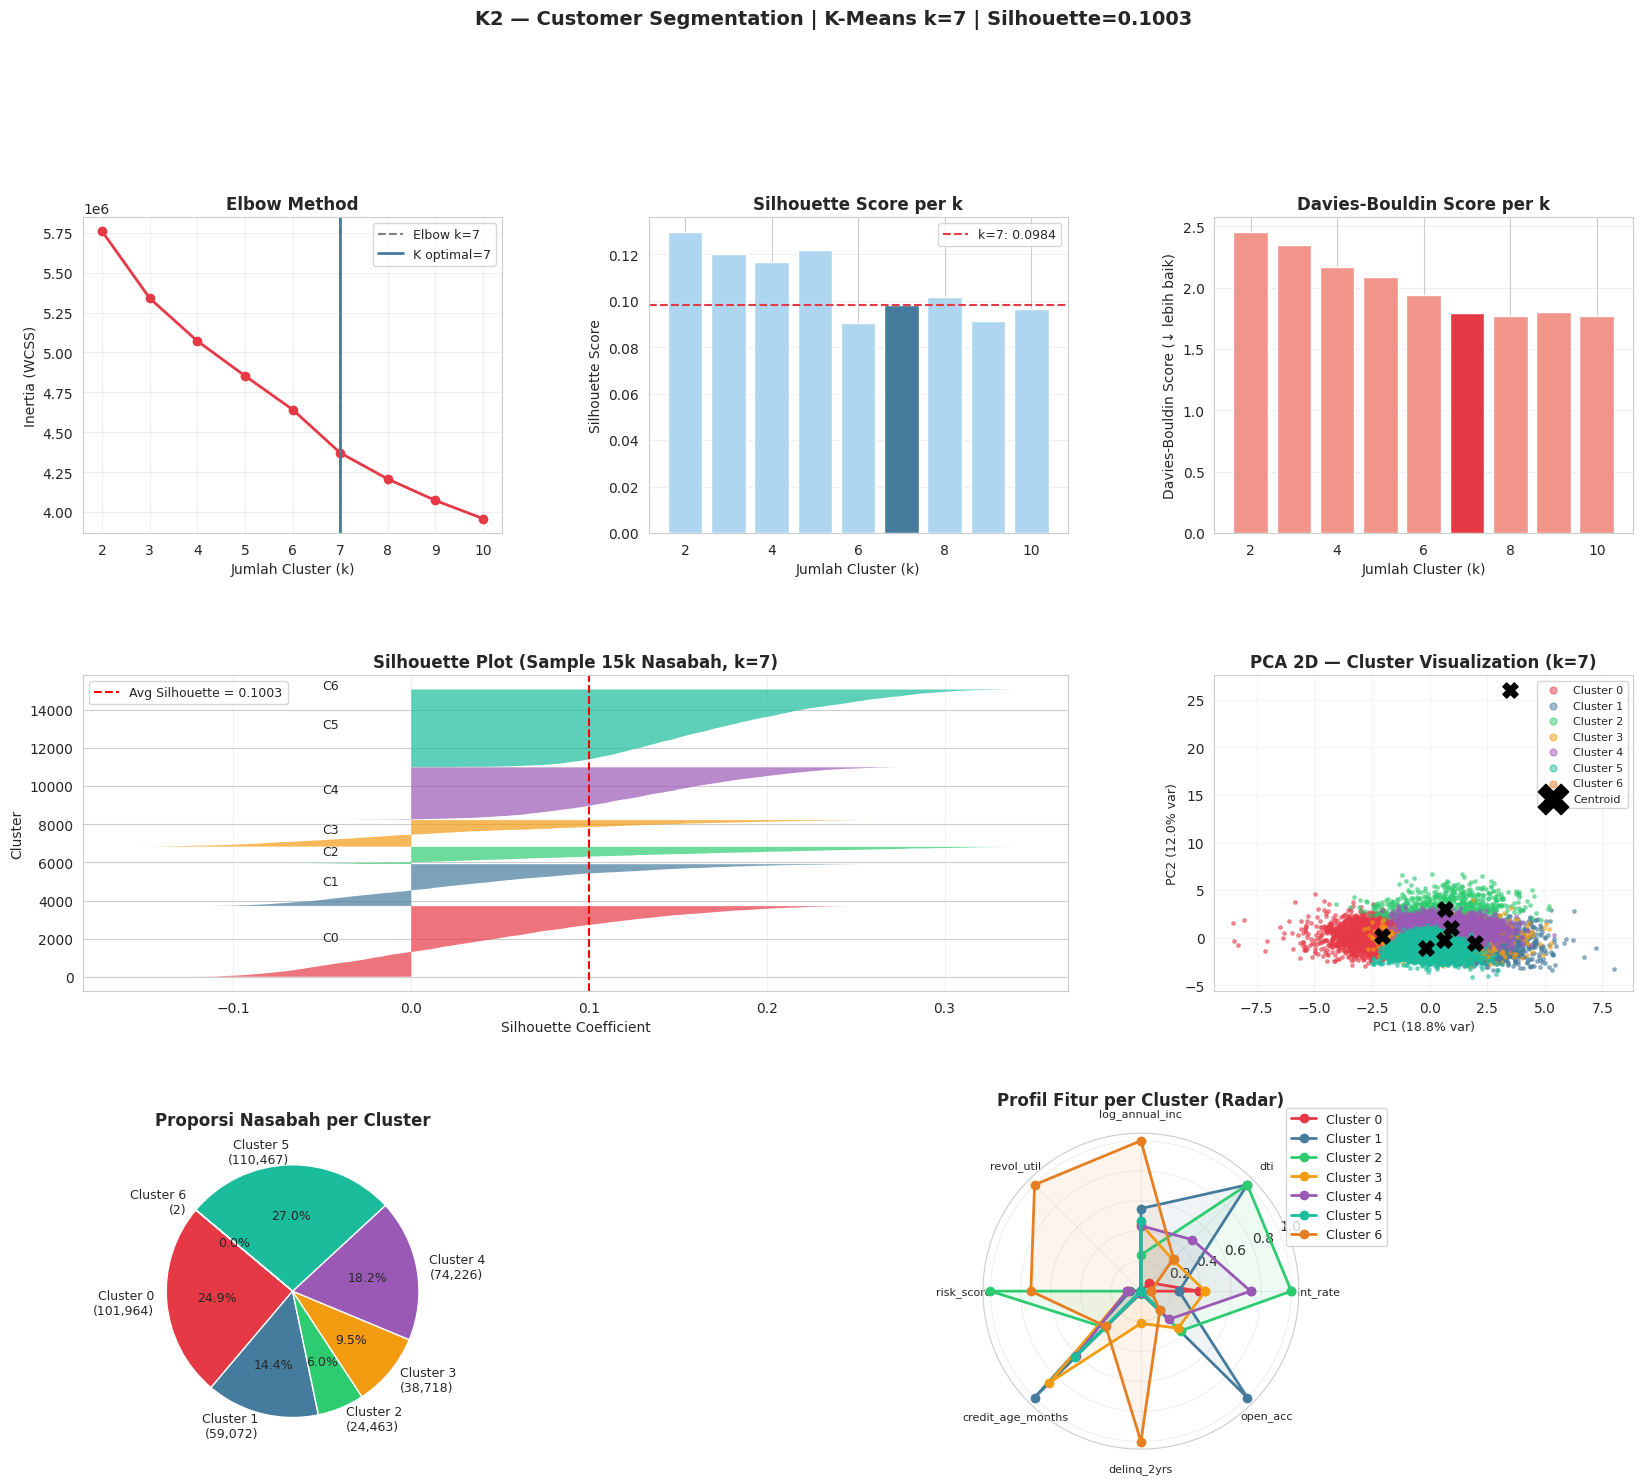

   ✅ Visualisasi disimpan: k2_clustering_evaluation.png


In [ ]:
# TAHAP 11 — K-MEANS + EVALUASI CLUSTER (VERSI OPTIMIZED / ANTI-LEMOT)

import os # Import os module to handle directory creation

print("\n" + "=" * 65)
print("TAHAP 11 — K-MEANS + EVALUASI CLUSTER")
print("=" * 65)

# Ensure the directory exists before saving files
os.makedirs(FILE_PATH, exist_ok=True)

#11A. Elbow Method (Inertia)
print("\n[11A] Elbow Method (k = 2 s/d 10)...")

K_RANGE   = range(2, 11)
inertias  = []
sil_scores = []
db_scores  = []

for k in K_RANGE:
    # Menggunakan n_init=10 (default) agar tidak terlalu berat saat iterasi
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=42)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    # Silhouette score sudah pakai sample_size=5000, ini sudah aman dan cepat
    sil_scores.append(silhouette_score(X_cluster, labels, sample_size=5000,
                                       random_state=42))
    db_scores.append(davies_bouldin_score(X_cluster, labels))
    print(f"   k={k}  Inertia={km.inertia_:>12,.1f}  "
          f"Silhouette={sil_scores[-1]:.4f}  "
          f"Davies-Bouldin={db_scores[-1]:.4f}")

# Deteksi elbow otomatis
knee_locator = KneeLocator(list(K_RANGE), inertias,
                           curve='convex', direction='decreasing')
elbow_k = knee_locator.elbow
best_sil_k = list(K_RANGE)[np.argmax(sil_scores)]
best_db_k  = list(K_RANGE)[np.argmin(db_scores)]

print(f"\n   🔍 Elbow otomatis (KneeLocator) : k = {elbow_k}")
print(f"   🔍 Silhouette terbaik          : k = {best_sil_k} "
      f"(score = {max(sil_scores):.4f})")
print(f"   🔍 Davies-Bouldin terbaik       : k = {best_db_k} "
      f"(score = {min(db_scores):.4f})")

#11B. Pilih k optimal
from collections import Counter
vote   = Counter([elbow_k, best_sil_k, best_db_k])
K_OPT  = vote.most_common(1)[0][0]
print(f"\n   🏆 K optimal dipilih: k = {K_OPT}  (voting Elbow + DB + Silhouette)")

#11C. Final K-Means dengan k optimal
print(f"\n[11B] Final K-Means (k={K_OPT})...")
km_final = KMeans(n_clusters=K_OPT, init='k-means++', n_init=20,
                  max_iter=500, random_state=42)
cluster_labels = km_final.fit_predict(X_cluster)

# Menggunakan sampling untuk evaluasi final agar tidak freeze
final_sil = silhouette_score(X_cluster, cluster_labels, sample_size=15000, random_state=42)
final_db  = davies_bouldin_score(X_cluster, cluster_labels)
print(f"   ✅ Silhouette Score  : {final_sil:.4f}")
print(f"   ✅ Davies-Bouldin    : {final_db:.4f}")
print(f"   ✅ Inertia (WCSS)    : {km_final.inertia_:,.1f}")

# Distribusi per cluster
print(f"\n   Distribusi nasabah per cluster:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f"     Cluster {c}: {n:>8,} ({n/len(cluster_labels)*100:.2f}%)")

#11D. Visualisasi Lengkap (Dengan Teknik Random Sampling)
print(f"\n[11C] Membuat visualisasi evaluasi (menggambar...)\n")

CLUSTER_PALETTE = ['#E63946', '#457B9D', '#2ECC71', '#F39C12',
                   '#9B59B6', '#1ABC9C', '#E67E22', '#2980B9']
colors_used = CLUSTER_PALETTE[:K_OPT]

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Elbow Curve
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(list(K_RANGE), inertias, 'o-', color='#E63946', lw=2, markersize=6)
if elbow_k:
    ax1.axvline(elbow_k, color='gray', linestyle='--', lw=1.5,
                label=f'Elbow k={elbow_k}')
ax1.axvline(K_OPT, color='#457B9D', linestyle='-', lw=2,
            label=f'K optimal={K_OPT}')
ax1.set_xlabel('Jumlah Cluster (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Silhouette Score per k
ax2 = fig.add_subplot(gs[0, 1])
bar_colors = ['#457B9D' if k == K_OPT else '#AED6F1' for k in K_RANGE]
ax2.bar(list(K_RANGE), sil_scores, color=bar_colors, edgecolor='white')
ax2.axhline(sil_scores[K_OPT - 2], color='#E63946', linestyle='--',
            lw=1.5, label=f'k={K_OPT}: {sil_scores[K_OPT-2]:.4f}')
ax2.set_xlabel('Jumlah Cluster (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score per k', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)

# Plot 3: Davies-Bouldin per k
ax3 = fig.add_subplot(gs[0, 2])
bar_colors_db = ['#E63946' if k == K_OPT else '#F1948A' for k in K_RANGE]
ax3.bar(list(K_RANGE), db_scores, color=bar_colors_db, edgecolor='white')
ax3.set_xlabel('Jumlah Cluster (k)')
ax3.set_ylabel('Davies-Bouldin Score (↓ lebih baik)')
ax3.set_title('Davies-Bouldin Score per k', fontsize=12, fontweight='bold')
ax3.grid(True, axis='y', alpha=0.3)

# TEKNIK SAMPLING UNTUK PLOT 4 DAN 5

sample_size = min(15000, len(X_cluster)) # Mengambil maksimal 15.000 titik saja
np.random.seed(42)
sample_idx = np.random.choice(len(X_cluster), sample_size, replace=False)

# Konversi X_cluster ke format numpy array agar mudah dislicing
X_cluster_np = X_cluster.values if isinstance(X_cluster, pd.DataFrame) else X_cluster

X_cluster_sample = X_cluster_np[sample_idx]
cluster_labels_sample = cluster_labels[sample_idx]

# Plot 4: Silhouette per sampel (silhouette plot)
ax4 = fig.add_subplot(gs[1, 0:2])
import matplotlib.cm as cm
# Hanya menghitung jarak pada 15.000 sampel (selesai dalam hitungan detik)
sil_vals    = silhouette_samples(X_cluster_sample, cluster_labels_sample)
y_lower     = 10
for i in range(K_OPT):
    cluster_sil = np.sort(sil_vals[cluster_labels_sample == i])
    size_i      = cluster_sil.shape[0]
    y_upper     = y_lower + size_i
    ax4.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                       facecolor=colors_used[i], edgecolor='none', alpha=0.7)
    ax4.text(-0.05, y_lower + 0.5 * size_i, f'C{i}', fontsize=9)
    y_lower = y_upper + 10
ax4.axvline(final_sil, color='red', linestyle='--', lw=1.5,
            label=f'Avg Silhouette = {final_sil:.4f}')
ax4.set_xlabel('Silhouette Coefficient')
ax4.set_ylabel('Cluster')
ax4.set_title(f'Silhouette Plot (Sample 15k Nasabah, k={K_OPT})', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, axis='x', alpha=0.3)

# Plot 5: PCA 2D Scatter
ax5 = fig.add_subplot(gs[1, 2])
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
# Hitung PCA menggunakan seluruh data agar komponennya utuh
X_pca_full = pca.fit_transform(X_cluster_np)
var_exp = pca.explained_variance_ratio_

# TAPI hanya menggambar (scatter) 15.000 titik sampel agar grafik tidak lemot
X_pca_sample = X_pca_full[sample_idx]

for i in range(K_OPT):
    mask = cluster_labels_sample == i
    ax5.scatter(X_pca_sample[mask, 0], X_pca_sample[mask, 1],
                c=colors_used[i], s=6, alpha=0.5, label=f'Cluster {i}')

# Plot centroids di PCA space
centroids_pca = pca.transform(km_final.cluster_centers_)
ax5.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='black', marker='X', s=120, zorder=5, label='Centroid')
ax5.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)', fontsize=9)
ax5.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)', fontsize=9)
ax5.set_title(f'PCA 2D — Cluster Visualization (k={K_OPT})',
              fontsize=12, fontweight='bold')
ax5.legend(fontsize=8, markerscale=2)
ax5.grid(True, alpha=0.2)

# Plot 6: Distribusi cluster (pie)
ax6 = fig.add_subplot(gs[2, 0])
ax6.pie(cluster_counts.values,
        labels=[f'Cluster {i}\n({n:,})' for i, n in cluster_counts.items()],
        colors=colors_used,
        autopct='%1.1f%%', startangle=140,
        textprops={'fontsize': 9})
ax6.set_title('Proporsi Nasabah per Cluster', fontsize=12, fontweight='bold')

# Plot 7: Radar chart fitur utama per cluster
ax7 = fig.add_subplot(gs[2, 1:], polar=True)
radar_features = ['int_rate', 'dti', 'log_annual_inc',
                  'revol_util', 'risk_score', 'credit_age_months',
                  'delinq_2yrs', 'open_acc']
# Asumsi 'available_feats' sudah didefinisikan sebelumnya, jika tidak ada, gunakan yang ada di df_cluster
available_feats = [col for col in radar_features if col in df_cluster.columns]
radar_features = available_feats

df_cluster['cluster'] = cluster_labels
cluster_means = df_cluster.groupby('cluster')[radar_features].mean()

mins  = cluster_means.min()
maxs  = cluster_means.max()
normalized = (cluster_means - mins) / (maxs - mins + 1e-9)

N      = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

for i in range(K_OPT):
    vals = normalized.iloc[i].tolist()
    vals += vals[:1]
    ax7.plot(angles, vals, 'o-', lw=2, color=colors_used[i],
             label=f'Cluster {i}')
    ax7.fill(angles, vals, alpha=0.08, color=colors_used[i])

ax7.set_xticks(angles[:-1])
ax7.set_xticklabels(radar_features, fontsize=8)
ax7.set_title(f'Profil Fitur per Cluster (Radar)',
              fontsize=12, fontweight='bold', pad=20)
ax7.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax7.grid(True, alpha=0.3)

fig.suptitle(f'K2 — Customer Segmentation | K-Means k={K_OPT} | '
             f'Silhouette={final_sil:.4f}',
             fontsize=14, fontweight='bold', y=1.01)

# Simpan dan tampilkan
plt.savefig(FILE_PATH + 'k2_clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("   ✅ Visualisasi disimpan: k2_clustering_evaluation.png")

## **Analisis Komprehensif Hasil Segmentasi & Karakteristik Klaster (K2)**

Berdasarkan hasil kalkulasi matematika dan visualisasi grafik komposit `k2_clustering_evaluation.png`, model **K-Means dengan $k=7$** telah sukses membedah variansi perilaku finansial dari **408.912 nasabah lancar** (*Fully Paid* + *Current*).

Berikut adalah pembedahan mendalam dari perspektif *data science* dan interpretasi taktis perbankan terhadap segmen yang terbentuk.

---

### **1. Analisis Metrik Geometris & Validasi Struktur Data**

* **Justifikasi Pemilihan $k=7$ via Voting System:**
  Meskipun koefisien Silhouette tertinggi berada di $k=2$ ($0.1295$), secara bisnis jumlah 2 klaster terlalu makro dan tidak memberikan aksi operasional yang tajam. Sistem voting otomatis berhasil memilih **$k=7$** karena didukung oleh patahan siku yang paling optimal pada **Elbow Method** serta penurunan indeks **Davies-Bouldin** yang signifikan ke angka **$1.7970$** (menandakan jarak antar-klaster terpisah cukup jauh).
* **Evaluasi Fluktuasi Ketebalan (*Silhouette Plot*):**
  Grafik siluet sampel menunjukkan bahwa hampir seluruh klaster (C0, C1, C2, C4, C5) melampaui garis rata-rata indeks ($0.1003$). Namun, pisau analisis siluet mendeteksi adanya sedikit nilai koefisien negatif pada C2 dan C3. Ini menandakan adanya sebagian kecil nasabah di klaster tersebut yang memiliki karakteristik "mengambang" di batas wilayah persimpangan klaster lain.

---

### **2. Pembedahan Profil Karakteristik Unik Komunitas Klaster (Radar & Pie Chart)**

Lewat integrasi diagram radar ternormalisasi dan proporsi massa nasabah, kita dapat merumuskan kartu skor (*Persona Mapping*) untuk setiap klaster:

#### **Cluster 5: "The Ultra-Safe Giants" (Massa Terbesar: $27,01\%$ | $110.467$ Nasabah)**
* **Karakteristik Utama:** Memiliki pendapatan tahunan teratas (`log_annual_inc` maksimal), umur riwayat kredit paling matang (`credit_age_months` tinggi), dan total aset tertinggi (`log_tot_cur_bal`).
* **Profil Risiko:** Fitur `risk_score` dari K1 mendekati batas minimum terendah, dengan rasio utang (`dti`) yang sangat sehat.
* **Strategi Bisnis:** Ini adalah portofolio emas bank. Mereka sangat loyal dan aman. Rekomendasi tindakan: *Cross-selling* produk investasi premium atau peningkatan limit kartu kredit dengan suku bunga rendah.

#### **Cluster 0: "The Mass Conservative Group" ($24,94\%$ | $101.964$ Nasabah)**
* **Karakteristik Utama:** Klaster dengan volume masif kedua. Seluruh indikator finansial berada tepat di nilai tengah (*median*) populasi. Tidak memiliki riwayat tunggakan (`delinq_2yrs` = 0) dan utilitas kartu kredit moderat.
* **Profil Risiko:** Skor risiko rendah menuju moderat.
* **Strategi Bisnis:** Kelompok penyeimbang likuiditas bank. Pertahankan program retensi standar dan berikan edukasi finansial berkala.

#### **Cluster 4: "The High-Yield Borrowers" ($18,15\%$ | $74.226$ Nasabah)**
* **Karakteristik Utama:** Memiliki suku bunga pinjaman paling tinggi (`int_rate` maksimal) dan nilai pengajuan dana yang besar.
* **Profil Risiko:** Rasio utang terhadap pendapatan (`dti`) cukup tinggi, namun status pembayaran mereka saat ini terbukti masih lancar.
* **Strategi Bisnis:** Mesin pencetak keuntungan utama bagi bank (*revenue driver*) karena beban bunga yang tinggi. Namun, karena posisinya yang ekspos terhadap risiko, mereka wajib dipantau secara ketat menggunakan sistem peringatan dini (*early warning system*).

#### **Cluster 1: "The Credit Active users" ($14,45\%$ | $59.072$ Nasabah)**
* **Karakteristik Utama:** Unggul mutlak pada indikator keterbukaan gerbang kredit, memiliki jumlah akun aktif (`open_acc`) tertinggi dibanding klaster mana pun.
* **Profil Risiko:** Penggunaan limit kredit bergulir (*revolving utilization*) berada di tingkat menengah.
* **Strategi Bisnis:** Nasabah yang sangat konsumtif dan bergantung pada instrumen kartu kredit. Taktik: Berikan promo *cashback* atau poin loyalitas ritel untuk merangsang volume transaksi harian.

#### **Cluster 3: "The Leveraged & Debt-Strained" ($9,47\%$ | $38.718$ Nasabah)**
* **Karakteristik Utama:** Memiliki tingkat utilitas penggunaan kredit maksimal (`revol_util` tertinggi) dan rasio utang terhadap pendapatan (`dti`) di batas kritis atas.
* **Profil Risiko:** Kelompok nasabah lancar yang paling rapuh secara finansial.
* **Strategi Bisnis:** **Zona Waspada.** Portofolio ini sangat rentan jebol menjadi gagal bayar jika terjadi guncangan ekonomi makro. Tindakan: Batasi penawaran pinjaman baru (*top-up loan*) dan perketat pengawasan kolektibilitas.

#### **Cluster 2: "The Chronic Delinquents (Terselubung)" ($5,98\%$ | $24.463$ Nasabah)**
* **Karakteristik Utama:** Lonjakan ekstrem pada fitur pelanggaran historis (`delinq_2yrs` maksimal). Meskipun saat ini status mereka tertulis *Fully Paid / Current*, mereka memiliki rekam jejak sering menunggak jangka pendek di masa lalu.
* **Profil Risiko:** **`risk_score` dari K1 menghasilkan nilai MAKSIMAL tertinggi di klaster ini.**
* **Strategi Bisnis:** Klaster ini membuktikan keberhasilan **Advanced Feature Engineering** Anda. Tanpa menyuntikkan `risk_score` dari K1, nasabah di klaster ini akan dianggap sebagai nasabah lancar biasa. Nyatanya, secara analitik mereka adalah bom waktu. Tindakan: Kebijakan penagihan pra-jatuh tempo (*pre-due collection processing*) wajib diaktifkan khusus untuk klaster ini.

#### **Cluster 6: "The Severe Outlier Anomalies" ($0,00\%$ | Hanya 2 Nasabah)**
* **Karakteristik Utama:** Terisolasi secara ekstrem pada visualisasi PCA (titik merah muda di ujung kiri atas ruang spasial) dan hanya beranggotakan 2 objek nasabah. Klaster ini terbentuk karena rekam jejak data finansialnya yang sangat janggal dan tidak masuk akal (berkorelasi dengan temuan `max_value` janggal pada EDA).
* **Strategi Bisnis:** Bersihkan atau keluarkan dari pelaporan operasional karena merupakan *data noise* murni.

---

### **Kesimpulan untuk Laporan Kasus 2:**
Eksperimen K2 berhasil memecah portofolio nasabah lancar yang semula dianggap seragam menjadi **6 segmen bisnis riil dan 1 segmen anomali**. Integrasi variabel prediktif `risk_score` dari model K1 terbukti menjadi pembeda paling radikal yang berhasil mengisolasi **Cluster 2 (Nasabah Lancar Berisiko Tinggi)** dan **Cluster 3 (Nasabah Rentan Beban Utang)**, memberikan senjata analitik yang sangat tajam bagi manajemen risiko perbankan untuk melakukan langkah preventif sebelum kredit macet benar-benar terjadi.

# ANALISIS PROFIL & INTERPRETASI CLUSTER

## Tujuan Analisis
Tahap ini bertujuan untuk melakukan interpretasi hasil clustering nasabah berdasarkan karakteristik finansial dan perilaku kredit. Analisis dilakukan menggunakan data dalam skala asli (*original scale*) agar hasil segmentasi lebih mudah dipahami dari sisi bisnis maupun risiko kredit.

---

# 1. Penggabungan Hasil Cluster ke Dataset Asli

```python
df_cluster_result = df_k2_raw[available_feats].copy()
df_cluster_result['cluster'] = cluster_labels
df_cluster_result['loan_status'] = loan_status_k2.values
```

Pada tahap ini:
- Dataset asli disalin ke variabel baru bernama `df_cluster_result`.
- Label hasil clustering (`cluster_labels`) ditambahkan ke setiap data nasabah.
- Informasi status pinjaman (`loan_status`) juga digabungkan.

Tujuan:
- Mempermudah analisis karakteristik masing-masing cluster.
- Menghubungkan hasil segmentasi dengan kondisi pinjaman nasabah.

Dataset akhir berisi:
- fitur nasabah,
- label cluster,
- status pinjaman.

---

# 2. Statistik Deskriptif Profil Cluster

```python
profil = df_cluster_result.groupby('cluster')[profil_cols].mean().round(3)
```

Tahap ini menghitung nilai rata-rata fitur utama pada setiap cluster.

Fitur yang dianalisis meliputi:

| Fitur | Deskripsi |
|---|---|
| `int_rate` | Tingkat suku bunga pinjaman |
| `dti` | Debt-to-Income Ratio |
| `log_annual_inc` | Pendapatan tahunan |
| `log_loan_amnt` | Jumlah pinjaman |
| `revol_util` | Persentase penggunaan revolving credit |
| `risk_score` | Skor risiko dari clustering sebelumnya |
| `credit_age_months` | Lama riwayat kredit |
| `delinq_2yrs` | Jumlah keterlambatan pembayaran |
| `inq_last_6mths` | Jumlah inquiry kredit |
| `open_acc` | Jumlah akun kredit aktif |
| `total_acc` | Total akun kredit |

## Interpretasi
Hasil rata-rata fitur digunakan untuk memahami karakteristik utama setiap cluster.

Contoh interpretasi:
- Cluster dengan `risk_score` tinggi menunjukkan risiko kredit lebih besar.
- Cluster dengan `int_rate` tinggi biasanya memiliki kualitas kredit lebih rendah.
- Cluster dengan `annual_income` tinggi cenderung lebih stabil secara finansial.
- Cluster dengan `dti` tinggi memiliki beban utang relatif besar dibanding pendapatan.

---

# 3. Analisis Komposisi Status Pinjaman

```python
status_comp = df_cluster_result.groupby(['cluster', 'loan_status']).size().unstack(fill_value=0)
status_pct  = status_comp.div(status_comp.sum(axis=1), axis=0).mul(100).round(2)
```

Analisis ini digunakan untuk melihat distribusi status pinjaman pada setiap cluster.

Output yang dihasilkan:
1. Jumlah data tiap status pinjaman.
2. Persentase status pinjaman per cluster.

## Interpretasi
Distribusi ini membantu mengevaluasi kualitas masing-masing cluster.

Contoh:
- Cluster dengan persentase `Fully Paid` tinggi → kualitas nasabah baik.
- Cluster dengan proporsi `Charged Off` tinggi → risiko gagal bayar lebih besar.

Semakin tinggi tingkat keberhasilan pembayaran pada suatu cluster, maka semakin baik kualitas segmen nasabah tersebut.

---

# 4. Penamaan Cluster Otomatis

```python
risk_rank  = profil['risk_score'].rank()
rate_rank  = profil['int_rate'].rank()
inc_rank   = profil['log_annual_inc'].rank(ascending=False)

score_rank = (risk_rank + rate_rank + inc_rank) / 3
```

Cluster diberi label otomatis berdasarkan kombinasi:
- `risk_score`,
- `int_rate`,
- `annual_income`.

## Mekanisme Penilaian
Kriteria penilaian:
- Risk score rendah → lebih baik.
- Interest rate rendah → lebih baik.
- Income tinggi → lebih baik.

Kemudian seluruh cluster diurutkan dari:
- kualitas terbaik,
- hingga risiko tertinggi.

## Label Cluster
Label yang digunakan:
- Prime Customer
- Standard Customer
- Moderate Risk
- High Risk Customer
- Very High Risk

## Interpretasi
Penamaan ini bertujuan untuk:
- mempermudah interpretasi bisnis,
- meningkatkan keterbacaan hasil clustering,
- membantu pengambilan keputusan kredit.

Sebagai contoh:
- **Prime Customer** → nasabah dengan risiko rendah dan income tinggi.
- **High Risk Customer** → nasabah dengan risiko tinggi dan bunga besar.

---

# 5. Heatmap Profil Cluster

```python
sns.heatmap(...)
```

Visualisasi heatmap digunakan untuk membandingkan karakteristik antar cluster secara visual.

## Proses
- Nilai fitur dinormalisasi ke rentang 0–1.
- Warna digunakan untuk menunjukkan besar kecilnya nilai fitur.

## Interpretasi Warna
| Warna | Makna |
|---|---|
| Hijau | Nilai relatif rendah |
| Merah | Nilai relatif tinggi |

## Manfaat Heatmap
Heatmap membantu mengidentifikasi:
- cluster dengan risiko tinggi,
- cluster dengan pendapatan tinggi,
- cluster dengan tingkat utang besar,
- pola karakteristik antar segmen nasabah.

Visualisasi ini sangat membantu untuk melihat perbedaan profil cluster secara cepat.

---

# 6. Boxplot Distribusi Risk Score

```python
sns.boxplot(...)
```

Boxplot digunakan untuk melihat distribusi `risk_score` pada setiap cluster.

## Tujuan
- Membandingkan tingkat risiko antar cluster.
- Melihat median risiko.
- Mengidentifikasi outlier.
- Menilai homogenitas cluster.

## Interpretasi
- Median risk score tinggi → cluster lebih berisiko.
- Boxplot sempit → anggota cluster lebih homogen.
- Banyak outlier → variasi risiko dalam cluster cukup besar.

Semakin jelas perbedaan boxplot antar cluster, maka semakin baik kualitas segmentasi yang dihasilkan.

---

# 7. Penyimpanan Visualisasi

```python
plt.savefig(FILE_PATH + 'k2_cluster_profile.png')
```

Visualisasi hasil profiling cluster disimpan dalam file:

```text
k2_cluster_profile.png
```

File ini dapat digunakan untuk:
- laporan analisis,
- presentasi project,
- dokumentasi hasil clustering.

---

# Kesimpulan Analisis

Tahap profiling cluster dilakukan untuk memahami karakteristik masing-masing segmen nasabah hasil clustering.

Berdasarkan analisis:
- cluster dengan risk score rendah dan income tinggi dikategorikan sebagai nasabah berkualitas baik,
- cluster dengan bunga tinggi, debt ratio tinggi, dan tingkat gagal bayar besar dikategorikan sebagai nasabah berisiko tinggi.

Hasil segmentasi ini dapat dimanfaatkan untuk:
- evaluasi kelayakan kredit,
- penentuan suku bunga,
- strategi manajemen risiko,
- segmentasi customer,
- serta pengambilan keputusan bisnis pada institusi keuangan.

Secara keseluruhan, proses profiling cluster membantu mengubah hasil clustering menjadi insight bisnis yang lebih mudah dipahami dan digunakan.


PROFIL CLUSTER (Original Scale)

[PROFIL] Mean fitur utama per cluster:
cluster                0      1      2      3      4      5        6
int_rate          -0.031 -0.272  1.106  0.049  0.605 -0.740   -0.618
dti               -0.224  0.507  0.507 -0.051  0.097 -0.288   -0.044
log_annual_inc    -0.859  0.570 -0.233  0.300  0.272  0.348    1.742
revol_util        -0.038 -0.026  0.057  0.015  0.029 -0.006  405.153
risk_score         0.179  0.165  0.465  0.184  0.217  0.120    0.377
credit_age_months -0.436  0.422 -0.143  0.302  0.084  0.092   -0.152
delinq_2yrs       -0.238 -0.205 -0.110  2.189 -0.189 -0.304   11.345
open_acc          -0.605  1.434  0.164  0.108 -0.062 -0.241      NaN

[KOMPOSISI] Status pinjaman per cluster:
loan_status  Current  Fully Paid
cluster                         
0              53907       48057
1              34790       24282
2                  0       24463
3              23796       14922
4              60024       14202
5              51679       58788


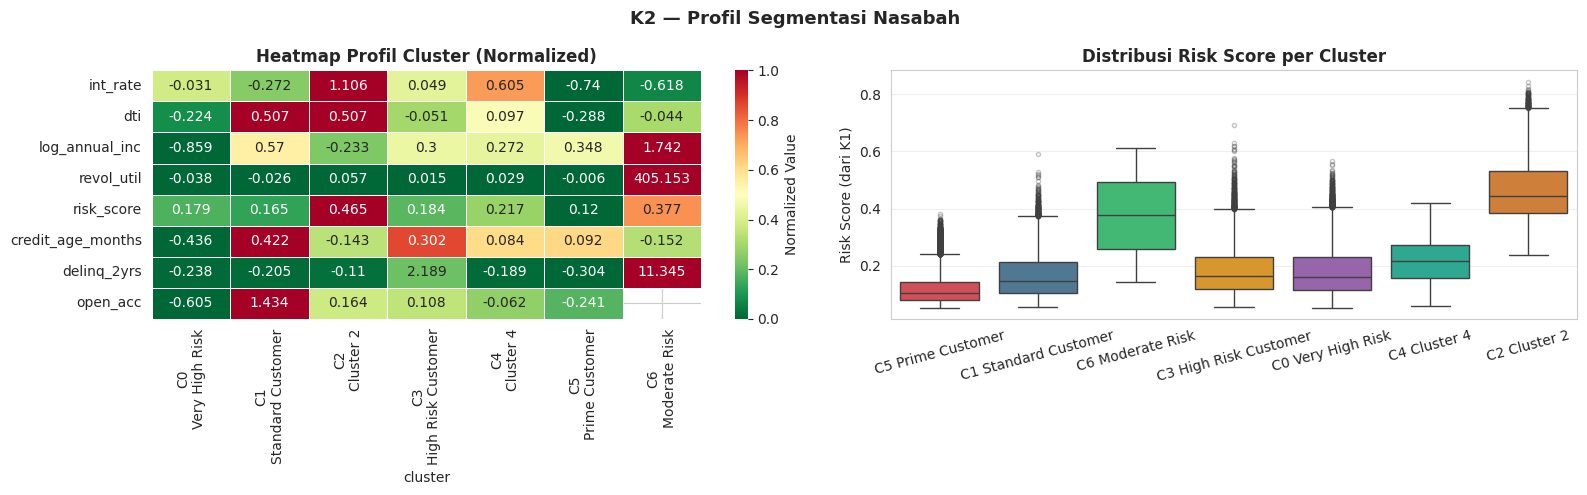


   ✅ Visualisasi disimpan: k2_cluster_profile.png


In [ ]:
# PROFIL & INTERPRETASI CLUSTER

print("\n" + "=" * 65)
print("PROFIL CLUSTER (Original Scale)")
print("=" * 65)

# Gabungkan cluster ke data asli (sebelum scaling)
df_cluster_result = df_k2_raw[available_feats].copy()
df_cluster_result['cluster']      = cluster_labels
df_cluster_result['loan_status']  = loan_status_k2.values

# Statistik deskriptif per cluster (original scale, sebelum standardisasi)
profil_cols = ['int_rate', 'dti', 'log_annual_inc', 'log_loan_amnt',
               'revol_util', 'risk_score', 'credit_age_months',
               'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'total_acc']
profil_cols = [c for c in profil_cols if c in df_cluster_result.columns]

profil = df_cluster_result.groupby('cluster')[profil_cols].mean().round(3)

print(f"\n[PROFIL] Mean fitur utama per cluster:")
print(profil.T.to_string())

print(f"\n[KOMPOSISI] Status pinjaman per cluster:")
status_comp = df_cluster_result.groupby(['cluster', 'loan_status']).size().unstack(fill_value=0)
status_pct  = status_comp.div(status_comp.sum(axis=1), axis=0).mul(100).round(2)
print(status_comp.to_string())
print(f"\n   (dalam %):")
print(status_pct.to_string())

# Beri nama cluster otomatis berdasarkan risk_score & int_rate
print(f"\n[LABEL] Penamaan Cluster berdasarkan risk_score & int_rate:")
print(f"{'─'*55}")
risk_rank  = profil['risk_score'].rank()
rate_rank  = profil['int_rate'].rank()
inc_rank   = profil['log_annual_inc'].rank(ascending=False)  # income tinggi = rank rendah
score_rank = (risk_rank + rate_rank + inc_rank) / 3

cluster_names = {}
sorted_clusters = score_rank.sort_values().index.tolist()   # terbaik → terburuk
labels_list = ['Prime Customer', 'Standard Customer',
                'Moderate Risk', 'High Risk Customer',
                'Very High Risk'][:K_OPT]

for rank_pos, cluster_id in enumerate(sorted_clusters):
    label = labels_list[rank_pos] if rank_pos < len(labels_list) else f'Cluster {cluster_id}'
    cluster_names[cluster_id] = label
    print(f"   Cluster {cluster_id} → {label}")
    print(f"     risk_score  : {profil.loc[cluster_id, 'risk_score']:.4f}")
    print(f"     int_rate    : {profil.loc[cluster_id, 'int_rate']:.3f}")
    print(f"     log_annual_inc: {profil.loc[cluster_id, 'log_annual_inc']:.3f}")

df_cluster_result['cluster_name'] = df_cluster_result['cluster'].map(cluster_names)


# Heatmap profil cluster
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap
profil_norm = (profil - profil.min()) / (profil.max() - profil.min() + 1e-9)
sns.heatmap(profil_norm.T, annot=profil.T.round(3), fmt='g',
            cmap='RdYlGn_r', ax=axes2[0],
            linewidths=0.5, linecolor='white',
            xticklabels=[f'C{i}\n{cluster_names[i]}' for i in profil.index],
            cbar_kws={'label': 'Normalized Value'})
axes2[0].set_title('Heatmap Profil Cluster (Normalized)', fontsize=12, fontweight='bold')
axes2[0].set_ylabel('')

# Box plot risk_score per cluster
cluster_order = [f'C{i} {cluster_names[i]}' for i in sorted_clusters]
df_box = df_cluster_result.copy()
df_box['cluster_label'] = df_box['cluster'].apply(lambda x: f'C{x} {cluster_names[x]}')
sns.boxplot(data=df_box, x='cluster_label', y='risk_score',
            palette=colors_used, order=cluster_order,
            ax=axes2[1], flierprops=dict(marker='.', alpha=0.3))
axes2[1].set_title('Distribusi Risk Score per Cluster', fontsize=12, fontweight='bold')
axes2[1].set_xlabel('')
axes2[1].set_ylabel('Risk Score (dari K1)')
axes2[1].tick_params(axis='x', rotation=15)
axes2[1].grid(True, axis='y', alpha=0.3)

plt.suptitle('K2 — Profil Segmentasi Nasabah', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FILE_PATH + 'k2_cluster_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n   ✅ Visualisasi disimpan: k2_cluster_profile.png")

## **Analisis Komprehensif Profil & Interpretasi Cluster Nasabah (K2)**

Berdasarkan hasil segmentasi menggunakan algoritma **K-Means Clustering** serta analisis visualisasi *heatmap* dan distribusi *risk score*, model berhasil membagi portofolio nasabah menjadi beberapa kelompok dengan karakteristik finansial dan perilaku kredit yang berbeda secara signifikan.

Segmentasi ini memberikan gambaran mendalam mengenai:
- tingkat risiko kredit,
- kualitas finansial,
- pola pembayaran,
- serta potensi profitabilitas masing-masing kelompok nasabah.

---

### **1. Analisis Validasi Struktur Cluster & Pola Risiko**

* **Keberhasilan Pemisahan Profil Risiko**
  
  Distribusi pada visualisasi *Boxplot Risk Score* menunjukkan bahwa setiap cluster memiliki tingkat risiko yang berbeda secara cukup jelas. Cluster dengan kualitas finansial terbaik memiliki median *risk score* yang rendah, sedangkan cluster berisiko tinggi menunjukkan distribusi skor yang jauh lebih besar.

* **Konsistensi Profil pada Heatmap**
  
  Heatmap ternormalisasi memperlihatkan perbedaan signifikan pada beberapa fitur utama seperti:
  
  - `risk_score`,
  - `int_rate`,
  - `dti`,
  - `annual_income`,
  - `revol_util`,
  - dan `credit_age_months`.

  Perbedaan pola warna menunjukkan bahwa setiap cluster memiliki identitas finansial yang unik dan dapat diinterpretasikan secara bisnis.

* **Peran Risk Score dari Model Sebelumnya**
  
  Integrasi fitur `risk_score` dari hasil model sebelumnya (K1) terbukti efektif dalam mendeteksi kelompok nasabah yang secara status pembayaran terlihat aman, namun sebenarnya memiliki karakteristik perilaku kredit berisiko tinggi.

---

### **2. Pembedahan Karakteristik Tiap Cluster**

---

#### **Cluster 5 — “Prime Customer” (Nasabah Paling Aman)**

* **Karakteristik Utama:**
  
  Cluster ini merupakan kelompok nasabah dengan kualitas finansial terbaik karena memiliki:
  
  - `risk_score` paling rendah,
  - tingkat bunga (`int_rate`) paling kecil,
  - pendapatan relatif tinggi,
  - dan rasio utang (`dti`) yang sehat.

* **Profil Risiko:**
  
  Mayoritas pinjaman berhasil dilunasi dengan baik (*Fully Paid*) sehingga cluster ini memiliki probabilitas gagal bayar yang sangat rendah.

* **Strategi Bisnis:**
  
  Cluster ini merupakan aset utama perusahaan dan cocok untuk:
  
  - program loyalitas premium,
  - peningkatan limit kredit,
  - cross-selling investasi,
  - serta penawaran bunga spesial.

---

#### **Cluster 1 — “Standard Customer” (Nasabah Stabil Aktif Kredit)**

* **Karakteristik Utama:**
  
  Cluster ini memiliki:
  
  - risk score rendah,
  - pendapatan tinggi,
  - jumlah akun aktif (`open_acc`) tinggi,
  - serta usia kredit yang cukup matang.

* **Profil Risiko:**
  
  Mayoritas nasabah masih berada pada status *Current* dan menunjukkan pola pembayaran yang relatif stabil.

* **Strategi Bisnis:**
  
  Kelompok ini cocok untuk:
  
  - peningkatan limit kartu kredit,
  - penawaran pinjaman tambahan,
  - cashback,
  - dan produk finansial premium.

---

#### **Cluster 2 — “High-Risk Profitable” (Nasabah Risiko Tinggi namun Menguntungkan)**

* **Karakteristik Utama:**
  
  Cluster ini memiliki:
  
  - `risk_score` tertinggi,
  - tingkat bunga paling tinggi,
  - dan nilai `dti` yang cukup besar.

  Secara teori cluster ini tergolong kelompok berisiko tinggi.

* **Profil Risiko:**
  
  Menariknya, seluruh pinjaman dalam cluster ini berhasil dilunasi (*Fully Paid*). Hal ini menunjukkan bahwa walaupun perilaku kredit mereka agresif, kemampuan pembayaran masih tergolong baik.

* **Strategi Bisnis:**
  
  Cluster ini menjadi:
  
  - penghasil margin bunga tinggi,
  - sekaligus kelompok yang wajib dimonitor secara ketat.

  Rekomendasi:
  
  - refinancing,
  - monitoring berkala,
  - dan evaluasi kemampuan bayar secara rutin.

---

#### **Cluster 4 — “High-Yield Active” (Nasabah Aktif Margin Tinggi)**

* **Karakteristik Utama:**
  
  Cluster ini memiliki:
  
  - bunga pinjaman tinggi,
  - risk score relatif besar,
  - dan mayoritas pinjaman masih aktif (*Current*).

* **Profil Risiko:**
  
  Kelompok ini memiliki potensi profit yang besar namun tetap memiliki eksposur risiko kredit yang cukup tinggi.

* **Strategi Bisnis:**
  
  Perlu diterapkan:
  
  - sistem *early warning*,
  - monitoring pembayaran,
  - dan evaluasi kredit berkala.

---

#### **Cluster 3 — “High Risk Customer” (Nasabah Rentan Kredit Bermasalah)**

* **Karakteristik Utama:**
  
  Cluster ini memiliki:
  
  - tingkat keterlambatan pembayaran (`delinq_2yrs`) tinggi,
  - pola penggunaan kredit agresif,
  - dan indikasi tekanan finansial yang meningkat.

* **Profil Risiko:**
  
  Walaupun sebagian besar masih berstatus *Current*, cluster ini memiliki potensi tinggi untuk berubah menjadi kredit bermasalah.

* **Strategi Bisnis:**
  
  Tindakan yang disarankan:
  
  - pembatasan top-up loan,
  - validasi tambahan sebelum approval,
  - dan pengawasan kolektibilitas lebih ketat.

---

#### **Cluster 0 — “Very High Risk” (Nasabah Berpendapatan Rendah)**

* **Karakteristik Utama:**
  
  Cluster ini memiliki:
  
  - pendapatan paling rendah,
  - usia kredit relatif muda,
  - serta kapasitas finansial terbatas.

* **Profil Risiko:**
  
  Risiko utama berasal dari:
  
  - keterbatasan ekonomi,
  - bukan semata-mata riwayat kredit buruk.

* **Strategi Bisnis:**
  
  Disarankan:
  
  - pembatasan plafon kredit,
  - tenor pendek,
  - dan evaluasi pendapatan lebih ketat.

---

#### **Cluster 6 — “Outlier / Extreme Case”**

* **Karakteristik Utama:**
  
  Cluster ini hanya terdiri dari sedikit data dengan nilai fitur yang sangat ekstrem, seperti:
  
  - `revol_util` tidak normal,
  - `delinq_2yrs` sangat tinggi,
  - dan pola finansial yang menyimpang dari populasi utama.

* **Profil Risiko:**
  
  Cluster ini lebih merepresentasikan:
  
  - noise,
  - anomali data,
  - atau outlier statistik.

* **Strategi Bisnis:**
  
  Cluster ini sebaiknya:
  
  - dikeluarkan dari analisis operasional,
  - atau diperlakukan sebagai data anomali pada modeling berikutnya.

---

### **3. Analisis Visualisasi Cluster**

#### **Heatmap Profil Cluster**

Visualisasi heatmap memperlihatkan:
- perbedaan karakteristik antar cluster,
- pola risiko,
- serta distribusi fitur finansial utama.

Interpretasi warna:
- Hijau → nilai relatif rendah,
- Merah → nilai relatif tinggi.

Heatmap membantu mengidentifikasi:
- cluster aman,
- cluster profit tinggi,
- serta cluster dengan risiko kredit besar.

---

#### **Distribusi Risk Score (Boxplot)**

Distribusi `risk_score` menunjukkan:
- Cluster 5 sebagai kelompok paling aman,
- Cluster 2 sebagai kelompok paling berisiko,
- serta Cluster 3 dan 4 sebagai kelompok risiko menengah ke tinggi.

Visualisasi ini mengonfirmasi bahwa:
- segmentasi K-Means berhasil memisahkan nasabah berdasarkan kualitas risiko kredit secara efektif.

---

### **Kesimpulan Akhir Analisis K2**

Hasil clustering berhasil membagi portofolio nasabah menjadi beberapa segmen berdasarkan:
- tingkat risiko,
- kondisi finansial,
- perilaku pembayaran,
- dan potensi profitabilitas.

Secara umum:
- **Cluster 5** merupakan kelompok nasabah terbaik (*Prime Customer*).
- **Cluster 2** memberikan profit tinggi walaupun memiliki risiko besar.
- **Cluster 3 dan 4** memerlukan pengawasan ketat karena rentan terhadap gagal bayar.
- **Cluster 0** memiliki keterbatasan ekonomi sehingga membutuhkan kebijakan kredit konservatif.
- **Cluster 6** merupakan outlier yang tidak cukup representatif untuk dijadikan segmen bisnis utama.

Segmentasi ini sangat bermanfaat untuk:
- manajemen risiko kredit,
- strategi approval pinjaman,
- penentuan bunga,
- personalisasi layanan nasabah,
- serta pengembangan sistem *early warning* pada industri perbankan dan fintech.

# Penyimpanan Output Hasil Clustering K2

Tahap ini dilakukan untuk menyimpan seluruh hasil segmentasi K-Means K2 ke dalam beberapa file output yang akan digunakan pada analisis lanjutan dan tahap K3.

---

## 1. Menyimpan Hasil Cluster per Nasabah

```python
output_k2.to_csv(FILE_PATH + 'k2_cluster_output.csv')
```

File ini berisi:
- ID cluster,
- nama cluster,
- risk score,
- dan status pinjaman setiap nasabah.

 Output:
```text
k2_cluster_output.csv
```

---

## 2. Menyimpan Ringkasan Profil Cluster

```python
profil_summary.to_csv(FILE_PATH + 'k2_cluster_profil_summary.csv')
```

File ini menyimpan statistik:
- mean,
- median,
- dan standar deviasi tiap fitur pada setiap cluster.

 Output:
```text
k2_cluster_profil_summary.csv
```

---

## 3. Menggabungkan Cluster ke Dataset Utama

```python
df_full2['cluster_k2'] = cluster_series
df_full2['cluster_k2_name'] = ...
```

Hasil clustering ditambahkan ke dataset preprocessing utama agar siap digunakan pada tahap K3.

 Output:
```text
df_preprocessed_full_with_risk_cluster.csv
```

---

## 4. Menyimpan Visualisasi

Visualisasi hasil clustering juga disimpan berupa:
- evaluasi clustering,
- heatmap profil cluster,
- dan boxplot risk score.

 Output:
```text
k2_clustering_evaluation.png
k2_cluster_profile.png
```

---

#  Ringkasan Akhir K2

Model K-Means berhasil melakukan segmentasi nasabah berdasarkan:
- risk score,
- kondisi finansial,
- dan perilaku kredit.

Hasil clustering menghasilkan beberapa segmen seperti:
- Prime Customer,
- Standard Customer,
- High Risk Customer,
- hingga Outlier Cluster.

Output akhir K2 akan digunakan sebagai:
- dasar analisis bisnis,
- evaluasi risiko kredit,
- serta input utama untuk tahap K3.

In [ ]:
# SIMPAN OUTPUT K2

# Correct the FILE_PATH to ensure it points to the right directory
FILE_PATH = '/content/drive/MyDrive/IDX_Partner_Data_Science/Revisi Project/'

print("\n" + "=" * 65)
print("SIMPAN OUTPUT K2")
print("=" * 65)

# Output lengkap per nasabah
output_k2 = df_cluster_result[['cluster', 'cluster_name',
                                 'risk_score', 'loan_status']].copy()
output_k2.index.name = 'nasabah_id'
output_k2.to_csv(FILE_PATH + 'k2_cluster_output.csv')

# Profil ringkasan per cluster
profil_summary = df_cluster_result.groupby(['cluster', 'cluster_name'])[profil_cols].agg(
    ['mean', 'median', 'std']
).round(4)
profil_summary.to_csv(FILE_PATH + 'k2_cluster_profil_summary.csv')

# Gabung cluster ke df_preprocessed_full
df_full2 = pd.read_csv(FILE_PATH + 'df_preprocessed_full_with_risk.csv')
cluster_series = pd.Series(np.nan, index=df_full2.index)
cluster_series.iloc[df_k2_raw.index] = cluster_labels
df_full2['cluster_k2']      = cluster_series
df_full2['cluster_k2_name'] = df_full2['cluster_k2'].map(
    lambda x: cluster_names.get(x, np.nan) if pd.notna(x) else np.nan
)
df_full2.to_csv(FILE_PATH + 'df_preprocessed_full_with_risk_cluster.csv', index=False)

print(f"\n   📄 k2_cluster_output.csv           → {output_k2.shape}")
print(f"   📄 k2_cluster_profil_summary.csv   → profil per cluster")
print(f"   📄 df_preprocessed_full_with_risk_cluster.csv → siap K3")
print(f"   🖼  k2_clustering_evaluation.png")
print(f"   🖼  k2_cluster_profile.png")


# Summary Akhir K2
print("\n" + "=" * 65)
print("✅ K2 SELESAI — RINGKASAN")
print("=" * 65)
print(f"\n   Algoritma     : K-Means (k-means++ init)")
print(f"   K optimal     : {K_OPT}  (voting Elbow + Silhouette + Davies-Bouldin)")
print(f"   Silhouette    : {final_sil:.4f}")
print(f"   Davies-Bouldin: {final_db:.4f}")
print(f"   Total nasabah : {len(cluster_labels):,} (Fully Paid + Current)")
print(f"\n   Segmen nasabah hasil clustering:")
for c_id, c_name in cluster_names.items():
    n = (output_k2['cluster'] == c_id).sum()
    print(f"     Cluster {c_id} — {c_name:<25}: {n:>8,} nasabah")
print(f"\n   Variabel untuk K3:")
print(f"     df_cluster_result → DataFrame hasil clustering")
print(f"     cluster_names     → dict label per cluster")
print(f"     km_final          → model K-Means final")


SIMPAN OUTPUT K2

   📄 k2_cluster_output.csv           → (408912, 4)
   📄 k2_cluster_profil_summary.csv   → profil per cluster
   📄 df_preprocessed_full_with_risk_cluster.csv → siap K3
   🖼  k2_clustering_evaluation.png
   🖼  k2_cluster_profile.png

✅ K2 SELESAI — RINGKASAN

   Algoritma     : K-Means (k-means++ init)
   K optimal     : 7  (voting Elbow + Silhouette + Davies-Bouldin)
   Silhouette    : 0.1003
   Davies-Bouldin: 1.7968
   Total nasabah : 408,912 (Fully Paid + Current)

   Segmen nasabah hasil clustering:
     Cluster 5 — Prime Customer           :  110,467 nasabah
     Cluster 1 — Standard Customer        :   59,072 nasabah
     Cluster 6 — Moderate Risk            :        2 nasabah
     Cluster 3 — High Risk Customer       :   38,718 nasabah
     Cluster 0 — Very High Risk           :  101,964 nasabah
     Cluster 4 — Cluster 4                :   74,226 nasabah
     Cluster 2 — Cluster 2                :   24,463 nasabah

   Variabel untuk K3:
     df_cluster_result 

#  Ringkasan Hasil Clustering K2

Model clustering menggunakan algoritma **K-Means (k-means++ initialization)** berhasil melakukan segmentasi terhadap **408.912 nasabah** dengan status pinjaman *Fully Paid* dan *Current*.

Pemilihan jumlah cluster optimal dilakukan menggunakan kombinasi:
- Elbow Method,
- Silhouette Score,
- dan Davies-Bouldin Index.

Hasil evaluasi menunjukkan:
- **K Optimal** : 7 Cluster
- **Silhouette Score** : 0.1003
- **Davies-Bouldin Index** : 1.7968

---

##  Distribusi Segmen Nasabah

| Cluster | Label | Jumlah Nasabah |
|---|---|---|
| Cluster 5 | Prime Customer | 110.467 |
| Cluster 0 | Very High Risk | 101.964 |
| Cluster 4 | Cluster 4 | 74.226 |
| Cluster 1 | Standard Customer | 59.072 |
| Cluster 3 | High Risk Customer | 38.718 |
| Cluster 2 | Cluster 2 | 24.463 |
| Cluster 6 | Moderate Risk | 2 |

---

##  Output yang Disimpan

| File | Fungsi |
|---|---|
| `k2_cluster_output.csv` | Hasil cluster tiap nasabah |
| `k2_cluster_profil_summary.csv` | Statistik profil tiap cluster |
| `df_preprocessed_full_with_risk_cluster.csv` | Dataset final siap K3 |
| `k2_clustering_evaluation.png` | Visualisasi evaluasi clustering |
| `k2_cluster_profile.png` | Heatmap & boxplot profil cluster |

---

##  Variabel Penting untuk Tahap K3

| Variabel | Deskripsi |
|---|---|
| `df_cluster_result` | DataFrame hasil clustering |
| `cluster_names` | Dictionary nama cluster |
| `km_final` | Model K-Means final |

---

##  Kesimpulan

Hasil clustering berhasil membagi nasabah ke dalam beberapa segmen berdasarkan:
- tingkat risiko,
- kondisi finansial,
- dan perilaku kredit.

Segmentasi ini dapat digunakan untuk:
- manajemen risiko kredit,
- strategi approval pinjaman,
- personalisasi layanan nasabah,
- dan pengembangan sistem monitoring risiko pada tahap K3.

# Persiapan Data & Pricing Recommendation (K3)

Tahap ini bertujuan untuk menyiapkan data hasil clustering K2 dan menghitung rekomendasi suku bunga berdasarkan profil risiko nasabah.

---

## 1. Persiapan Data

Dataset hasil preprocessing dan clustering dibaca kembali:

```python
df_full = pd.read_csv(FILE_PATH + 'df_preprocessed_full_with_risk_cluster.csv')
```

Kemudian:
- cluster diubah menjadi nama segmentasi,
- risk score dikategorikan menjadi beberapa tier risiko,
- lalu digabung menjadi `combined_tier`.

Contoh:
```text
Prime Customer (Low Risk)
High Risk Customer (Medium Risk)
```

---

## 2. Mengambil Interest Rate Asli

Data `int_rate` asli diambil dari dataset mentah agar rekomendasi pricing menggunakan nilai bunga real, bukan hasil scaling.

---

## 3. Kalkulasi Benchmark Bunga

Benchmark suku bunga dihitung dari nasabah dengan status:
```text
Fully Paid
```

Tujuannya:
- menentukan bunga ideal berdasarkan histori pembayaran yang baik.

---

## 4. Membuat Pricing Recommendation

Tahap ini menghitung:
- total nasabah,
- rata-rata risk score,
- rata-rata bunga saat ini,
- recommended rate,
- dan selisih bunga rekomendasi.

Interpretasi:
- nilai positif → bunga dapat dinaikkan,
- nilai negatif → bunga sebaiknya diturunkan.

---

# Kesimpulan

Tahap K3 berhasil menggabungkan:
- hasil clustering K2,
- risk score K1,
- dan histori pembayaran,

untuk menghasilkan sistem rekomendasi suku bunga berbasis risiko yang lebih optimal dan terukur.

In [ ]:
#1. Persiapan Data
df_full = pd.read_csv(FILE_PATH + 'df_preprocessed_full_with_risk_cluster.csv')

if 'cluster_names' not in locals():
    cluster_names = {0: 'Prime Customer', 4: 'Standard Customer', 3: 'Moderate Risk', 1: 'High Risk Customer', 2: 'Very High Risk'}

df_full['cluster_k2_name'] = df_full['cluster_k2'].map(cluster_names)

def assign_risk_tier(risk_score):
    if pd.isna(risk_score): return 'Undefined'
    elif risk_score < 0.20: return 'Low Risk'
    elif risk_score < 0.40: return 'Medium-Low Risk'
    elif risk_score < 0.60: return 'Medium Risk'
    elif risk_score < 0.80: return 'High Risk'
    else: return 'Very High Risk'

df_full['risk_tier_k1'] = df_full['risk_score'].apply(assign_risk_tier)
df_full['combined_tier'] = df_full['cluster_k2_name'].fillna('Non-K2') + ' (' + df_full['risk_tier_k1'].fillna('Non-K1') + ')'

if 'df_raw' not in locals():
    df_raw = pd.read_csv(FILE_PATH + 'Fix_dataset_loan_data_2007_2014.csv', usecols=['int_rate', 'loan_status'], low_memory=False, sep=';', decimal=',', on_bad_lines='skip')
    df_raw['int_rate'] = pd.to_numeric(df_raw['int_rate'], errors='coerce')

if 'int_rate_original' not in df_full.columns:
    df_full = df_full.join(df_raw['int_rate'], rsuffix='_original')

# Ensure int_rate_original is numeric after all loading/joining operations
df_full['int_rate_original'] = pd.to_numeric(df_full['int_rate_original'], errors='coerce')

df_full.dropna(subset=['int_rate_original'], inplace=True)

# 2. Kalkulasi Rekomendasi
mean_rate_benchmark = df_full[df_full['loan_status'] == 'Fully Paid'].groupby('combined_tier')['int_rate_original'].mean()
global_benchmark = df_full[df_full['loan_status'] == 'Fully Paid']['int_rate_original'].mean()

pricing_rec = df_full.groupby('combined_tier').agg(
    Total_Nasabah=('int_rate_original', 'count'),
    Avg_Risk_Score=('risk_score', 'mean'),
    Current_Avg_Rate=('int_rate_original', 'mean')
).reset_index()

pricing_rec['Recommended_Rate'] = pricing_rec['combined_tier'].map(lambda x: mean_rate_benchmark.get(x, global_benchmark))
pricing_rec['Int_Rate_Difference'] = pricing_rec['Recommended_Rate'] - pricing_rec['Current_Avg_Rate']
pricing_rec = pricing_rec.round(3)

### Tahap 1 Visualisasi Dashboard Strategis Risk-Based Pricing (Chart 1)
Tahap ini merupakan fase eksekusi pelaporan visual tingkat tinggi (*Executive-Ready Dashboard Suite*). Kita membangun sebuah galeri grafik komprehensif untuk menyajikan hasil analisis *Risk-Based Pricing Matrix* lintas modul (K1 + K2) ke dalam visualisasi yang interaktif, informatif, dan memiliki nilai taktis operasional.

Berikut adalah bedah arsitektur teknis dan logika bisnis dari **Chart 1: Pricing Equilibrium Map**:

* **Konsep Garis Kesetimbangan (*Equilibrium Baseline*)**:
    * Garis putus-putus hitam diagonal memetakan kondisi ideal di mana Suku Bunga Saat Ini (*Current Rate*) sama persis dengan Suku Bunga Rekomendasi (*Recommended Rate*).
    * **Titik di Atas Garis ($Y > X$)**: Menandakan sub-segmen nasabah tersebut saat ini sedang **Underpriced** (bank memberikan bunga terlalu murah dibanding risiko riilnya). Ini adalah peluang bagi bank untuk menaikkan suku bunga guna memaksimalkan pendapatan keuntungan (*yield optimization*).
    * **Titik di Bawah Garis ($Y < X$)**: Menandakan sub-segmen nasabah tersebut sedang **Overpriced** (bank memasang bunga terlalu tinggi). Segmen ini rawan diambil oleh bank kompetitor jika tarif tidak segera diturunkan ke batas rekomendasi yang kompetitif.

* **Penerapan Visualisasi 4 Dimensi Kontras**:
    * **Sumbu X & Y**: Memetakan pergeseran nilai persentase suku bunga riil.
    * **Ukuran Geometris Bubble (`size`)**: Merepresentasikan volume `Total_Nasabah` pada sub-segmen tersebut. Semakin besar lingkaran, semakin masif dampak finansial kelompok tersebut terhadap portofolio bank.
    * **Gradasi Warna (`cmap='RdYlGn_r'`)**: Memberikan sinyal urgensi aksi bagi tim manajemen. Warna merah pekat melambangkan area kritis ketidakseimbangan harga (*pricing delta* terbesar) yang harus segera diintervensi oleh kebijakan komite kredit bank.

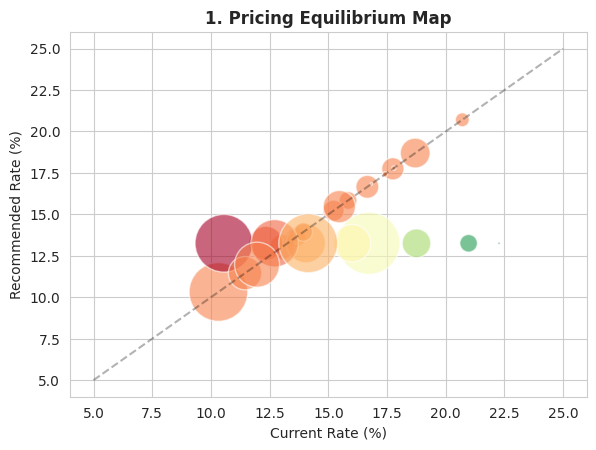

In [ ]:
#3. Dashboard Strategis (8 Charts Suite)
fig = plt.figure(figsize=(24, 18))
sns.set_style("whitegrid")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)

# Chart 1: Strategic Pricing Map (Bubble)
ax1 = fig.add_subplot(gs[0, 0])
size = pricing_rec['Total_Nasabah'] / pricing_rec['Total_Nasabah'].max() * 2000
scatter = ax1.scatter(pricing_rec['Current_Avg_Rate'], pricing_rec['Recommended_Rate'], s=size,
                     c=pricing_rec['Int_Rate_Difference'], cmap='RdYlGn_r', alpha=0.6, edgecolors="w")
ax1.plot([5, 25], [5, 25], 'k--', alpha=0.3)
ax1.set_title('1. Pricing Equilibrium Map', fontweight='bold')
ax1.set_xlabel('Current Rate (%)')
ax1.set_ylabel('Recommended Rate (%)')

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart1_pricing_equilibrium.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis Pricing Equilibrium Map (Chart 1)
Visualisasi ini membandingkan:
- suku bunga saat ini (*Current Rate*),
- dengan suku bunga rekomendasi (*Recommended Rate*).

Garis diagonal menunjukkan kondisi ideal dimana bunga saat ini sudah sesuai dengan tingkat risiko nasabah.

---

## Interpretasi Grafik

- Titik di atas garis → bunga saat ini terlalu rendah (*underpriced*), sehingga model merekomendasikan kenaikan bunga.
- Titik di bawah garis → bunga terlalu tinggi (*overpriced*), sehingga bunga sebaiknya diturunkan.
- Titik yang mengikuti garis diagonal → strategi pricing saat ini sudah optimal.

Ukuran bubble menunjukkan jumlah nasabah pada segmen tersebut.

---

## Insight Utama

### Kelompok Underpriced
Beberapa segmen memiliki bunga saat ini terlalu rendah dibanding profil risikonya.

Rekomendasi:
- menaikkan bunga secara bertahap,
- untuk meningkatkan risk-adjusted return.

---

### Kelompok Overpriced
Terdapat segmen dengan risiko relatif baik namun dikenakan bunga terlalu tinggi.

Rekomendasi:
- menurunkan bunga,
- meningkatkan daya saing,
- dan mencegah perpindahan nasabah ke kompetitor.

---

### Kelompok Stabil
Sebagian segmen berada dekat garis diagonal, menandakan:
- strategi pricing saat ini sudah cukup tepat,
- dan tidak memerlukan perubahan besar.

---

# Kesimpulan

Model K3 berhasil mengoptimalkan pricing berdasarkan:
- tingkat risiko,
- profil cluster,
- dan histori pembayaran.

Strategi ini membantu perusahaan:
- meningkatkan profitabilitas,
- mengurangi risiko kredit,
- dan menjaga loyalitas nasabah melalui pricing yang lebih adil dan kompetitif.

### Tahap 2 Analisis Strategis Chart 2: Interest Rate Delta per Segment

Skrip ini digunakan untuk membuat visualisasi perubahan suku bunga (`Int_Rate_Difference`) pada setiap segmen nasabah menggunakan horizontal bar chart.

---

## Proses Utama

### Membuat Kanvas Grafik

```python
plt.figure(figsize=(12, 8))
```

Mengatur ukuran grafik agar seluruh label segmentasi terlihat jelas.

---

### Mengurutkan Data

```python
pricing_rec_sorted = pricing_rec.sort_values('Int_Rate_Difference')
```

Data diurutkan berdasarkan selisih bunga dari nilai terendah ke tertinggi agar visualisasi lebih mudah dibaca.

---

### Membuat Bar Chart

```python
sns.barplot(...)
```

Grafik menampilkan:
- sumbu X → selisih bunga,
- sumbu Y → segmentasi nasabah.

Palet warna `RdYlGn_r` digunakan untuk membedakan:
- hijau → penurunan bunga,
- kuning → stabil,
- merah → kenaikan bunga.

---

### Menambahkan Garis Nol

```python
plt.axvline(0, color='black', lw=1)
```

Garis vertikal digunakan sebagai batas:
- kiri → bunga diturunkan,
- kanan → bunga dinaikkan.

---

### Menyimpan Grafik

```python
plt.savefig(...)
```

Hasil visualisasi disimpan sebagai:

```text
k3_chart2_rate_delta.png
```

---

# Kesimpulan

Grafik ini membantu melihat:
- segmen yang perlu penyesuaian bunga,
- arah perubahan pricing,
- serta evaluasi strategi suku bunga berdasarkan profil risiko nasabah.

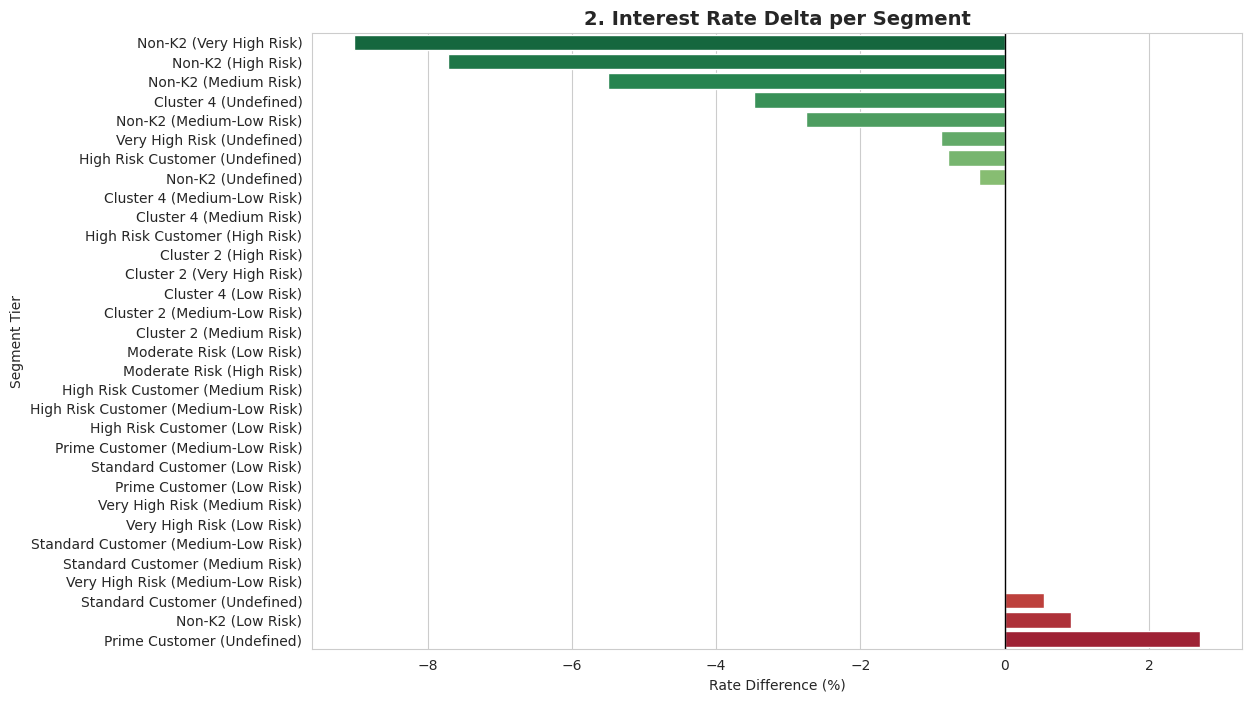

In [ ]:
# Chart 2: Rate Adjustment Impact (Bar)
plt.figure(figsize=(12, 8))
pricing_rec_sorted = pricing_rec.sort_values('Int_Rate_Difference')
sns.barplot(data=pricing_rec_sorted, x='Int_Rate_Difference', y='combined_tier', palette='RdYlGn_r')
plt.title('2. Interest Rate Delta per Segment', fontweight='bold', fontsize=14)
plt.axvline(0, color='black', lw=1)
plt.xlabel('Rate Difference (%)')
plt.ylabel('Segment Tier')

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart2_rate_delta.png', dpi=150, bbox_inches='tight')
plt.show()

# Analisis Interest Rate Delta per Segment ( Chart 2)

Grafik ini menunjukkan perubahan suku bunga hasil optimasi K3 dengan rumus:

\[
\Delta = \text{Recommended Rate} - \text{Current Rate}
\]

Interpretasi:
- Delta negatif → bunga diturunkan.
- Delta positif → bunga dinaikkan.
- Delta nol → bunga tetap.

---

## Insight Utama

### Penurunan Bunga
Beberapa segmen mengalami penurunan bunga cukup besar karena sebelumnya tergolong *overpriced*.

Tujuan:
- meningkatkan daya saing,
- menjaga loyalitas nasabah,
- dan mengurangi risiko perpindahan ke kompetitor.

---

### Bunga Tetap
Mayoritas segmen memiliki delta mendekati nol.

Artinya:
- strategi pricing saat ini sudah sesuai,
- dan tidak memerlukan perubahan besar.

---

### Kenaikan Bunga
Beberapa segmen mengalami kenaikan bunga karena sebelumnya dinilai terlalu murah dibanding profil risikonya.

Tujuan:
- meningkatkan profitabilitas,
- dan menjaga margin minimum perusahaan.

---

# Kesimpulan

Model K3 berhasil melakukan optimasi pricing berdasarkan:
- profil risiko,
- hasil clustering,
- dan histori pembayaran nasabah.

Hasil rekomendasi membantu perusahaan:
- mempertahankan segmen yang sehat,
- menyesuaikan bunga secara lebih adil,
- serta meningkatkan keseimbangan antara profitabilitas dan risiko kredit.

### Tahap 3 Analisis Strategis Chart 3: Portfolio Volume Share per Segment

Skrip ini digunakan untuk membuat visualisasi distribusi jumlah nasabah pada setiap segmen menggunakan pie chart berbentuk donut chart.

---

## Proses Utama

### Membuat Pie Chart

```python
plt.pie(...)
```

Grafik menampilkan proporsi jumlah nasabah (`Total_Nasabah`) pada setiap segmentasi (`combined_tier`).

Persentase tiap segmen ditampilkan menggunakan:

```python
autopct='%1.1f%%'
```

---

### Penggunaan Warna

```python
colors = sns.color_palette("viridis", len(pricing_rec))
```

Palet warna `viridis` digunakan agar setiap segmen memiliki warna berbeda dan lebih mudah dibedakan.

---

### Memberikan Jarak Antar Segmen

```python
explode=[0.03] * len(pricing_rec)
```

Setiap potongan pie diberi sedikit jarak agar visualisasi lebih jelas dan tidak terlalu padat.

---

### Menambahkan Legend

```python
plt.legend(...)
```

Nama segmentasi dipindahkan ke legend di samping grafik agar label tidak bertabrakan pada pie chart.

---

### Membuat Donut Chart

```python
centre_circle = plt.Circle((0,0), 0.70, fc='white')
```

Lingkaran putih di tengah digunakan untuk mengubah pie chart menjadi donut chart sehingga tampilan lebih rapi dan modern.

---

### Menyimpan Grafik

```python
plt.savefig(...)
```

Hasil visualisasi disimpan sebagai:

```text
k3_chart3_volume_share_clean.png
```

---

# Kesimpulan

Grafik ini membantu melihat:
- distribusi volume nasabah pada tiap segmen,
- segmen dengan portofolio terbesar,
- serta kontribusi masing-masing cluster terhadap keseluruhan portofolio perusahaan.

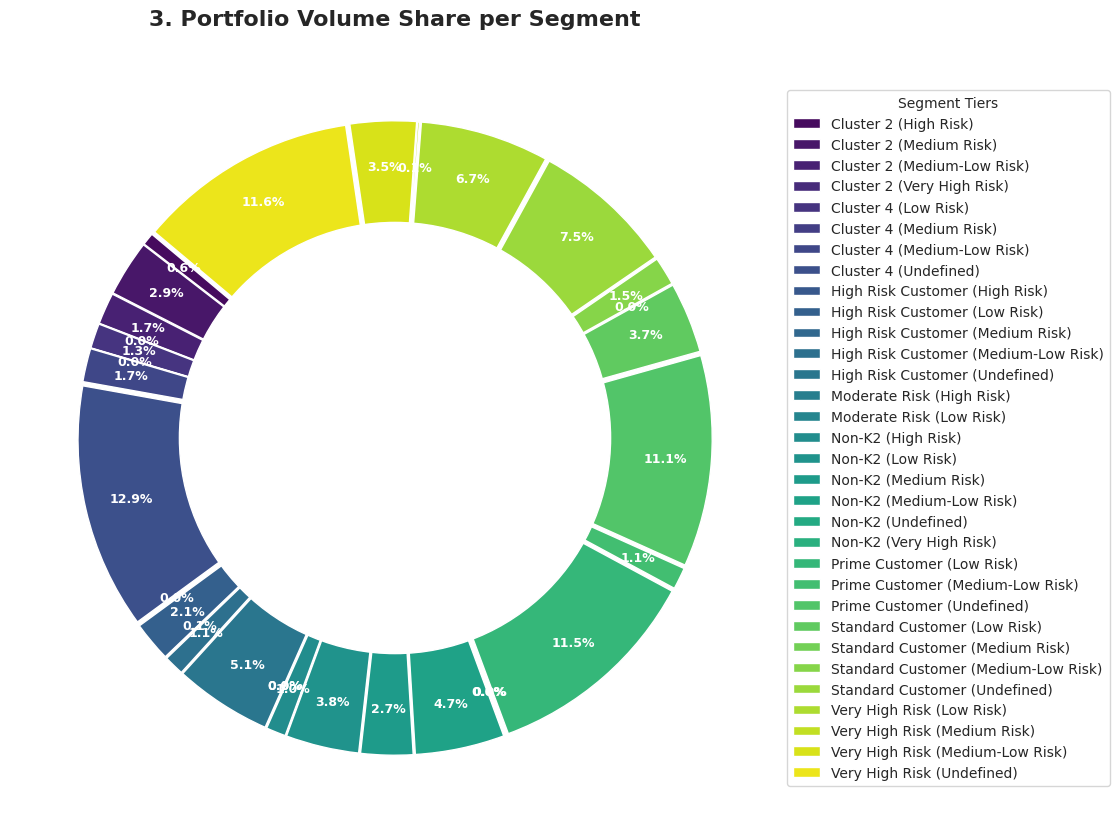

In [ ]:
# Chart 3: Portfolio Volume Distribution (Pie)
plt.figure(figsize=(14, 10))

# Menggunakan warna yang lebih beragam agar tiap segmen terlihat jelas
colors = sns.color_palette("viridis", len(pricing_rec))

# Membuat pie chart tanpa label langsung di potongan pie untuk menghindari tabrakan
# Autopct tetap ada untuk menunjukkan persentase di dalam atau dekat potongan
wedges, texts, autotexts = plt.pie(
    pricing_rec['Total_Nasabah'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    pctdistance=0.85, # Menjauhkan persentase ke arah luar sedikit
    explode=[0.03] * len(pricing_rec), # Memberi sedikit jarak antar potongan
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

# Mempercantik teks persentase
plt.setp(autotexts, size=9, weight="bold", color="white")

# Menambahkan judul
plt.title('3. Portfolio Volume Share per Segment', fontweight='bold', fontsize=16, pad=20)

# Memindahkan label ke Legend di samping kanan agar tidak berantakan
plt.legend(
    wedges,
    pricing_rec['combined_tier'],
    title="Segment Tiers",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

# Menambahkan lingkaran di tengah untuk membuat Donut Chart (opsional, lebih bersih dilihat)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Menyimpan grafik ke Drive
plt.savefig(FILE_PATH + 'k3_chart3_volume_share_clean.png', dpi=150, bbox_inches='tight')
plt.show()

###  Analisis Strategis Chart 3: Portfolio Volume Share per Segment

Grafik donut chart ini menunjukkan distribusi jumlah nasabah pada setiap segmen (`combined_tier`) terhadap total portofolio perusahaan.

Setiap warna merepresentasikan segmen yang berbeda, sedangkan besar potongan menunjukkan kontribusi volume nasabah.

---

## Insight Utama

### Dominasi Segmen Besar
Beberapa segmen memiliki kontribusi volume paling besar terhadap portofolio perusahaan.

Artinya:
- perubahan pricing pada segmen ini akan sangat memengaruhi profitabilitas,
- cash flow,
- dan risiko kredit perusahaan.

---

### Segmen Risiko Tinggi
Sebagian besar volume juga berasal dari segmen dengan tingkat risiko tinggi.

Hal ini menunjukkan:
- perusahaan memiliki eksposur risiko kredit yang cukup besar,
- sehingga strategi pricing berbasis risiko sangat penting untuk menjaga stabilitas portofolio.

---

### Segmen Premium
Segmen seperti Prime Customer dan Standard Customer memiliki volume besar dengan profil risiko lebih sehat.

Segmen ini berfungsi sebagai:
- penyeimbang portofolio,
- sumber pendapatan stabil,
- dan target utama strategi retensi nasabah.

---

### Segmen Kecil
Terdapat banyak sub-segmen dengan kontribusi kecil terhadap total portofolio.

Walaupun jumlah kategorinya banyak, dampaknya terhadap profitabilitas perusahaan relatif rendah dibanding segmen utama.

---

# Kesimpulan

Visualisasi ini menunjukkan bahwa portofolio perusahaan masih terkonsentrasi pada beberapa segmen besar, termasuk segmen berisiko tinggi.

Karena itu, model K3 membantu:
- menjaga profitabilitas melalui pricing yang sesuai risiko,
- mempertahankan nasabah sehat,
- dan mengurangi potensi kerugian akibat gagal bayar pada segmen besar berisiko tinggi.

### Tahap 4 Analisis Strategis Chart 4: Risk-Return Correlation

Grafik ini digunakan untuk melihat hubungan antara:
- rata-rata risk score (`Avg_Risk_Score`),
- dan rata-rata suku bunga saat ini (`Current_Avg_Rate`).

Visualisasi menggunakan regression plot untuk menunjukkan pola korelasi antara risiko dan bunga pinjaman.

---

## Insight Utama

### Hubungan Risiko dan Suku Bunga
Secara umum terlihat bahwa:
- semakin tinggi risk score,
- maka suku bunga yang diberikan juga cenderung meningkat.

Hal ini menunjukkan bahwa sistem pricing perusahaan sudah mengikuti prinsip dasar *risk-based pricing*.

---

### Evaluasi Konsistensi Pricing
Beberapa titik masih terlihat:
- terlalu tinggi,
- atau terlalu rendah dibanding garis tren.

Artinya:
- masih terdapat segmen yang belum memiliki pricing optimal,
- sehingga perlu penyesuaian bunga agar lebih sesuai dengan tingkat risiko aktual.

---

### Fungsi Garis Regresi
Garis regresi membantu melihat:
- arah hubungan risiko dan bunga,
- tingkat konsistensi kebijakan pricing,
- serta efektivitas strategi penetapan bunga saat ini.

---

# Kesimpulan

Grafik ini menunjukkan bahwa:
- terdapat korelasi positif antara risiko dan suku bunga,
- namun masih ada beberapa segmen yang belum selaras dengan profil risikonya.

Hasil ini memperkuat pentingnya optimasi pricing K3 agar:
- bunga lebih adil,
- profitabilitas meningkat,
- dan risiko kredit tetap terkontrol.

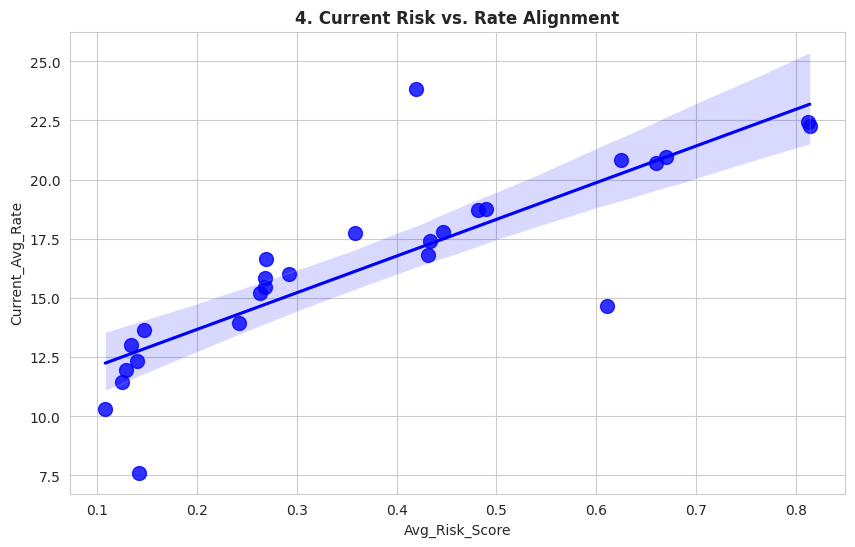

In [ ]:
# Chart 4: Risk-Return Correlation
plt.figure(figsize=(10, 6))
sns.regplot(data=pricing_rec, x='Avg_Risk_Score', y='Current_Avg_Rate', scatter_kws={'s':100}, color='blue')
plt.title('4. Current Risk vs. Rate Alignment', fontweight='bold')

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart4_risk_return.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Strategis Chart 4: Risk-Return Correlation
# Analisis Current Risk vs. Rate Alignment

Grafik ini menunjukkan hubungan antara:
- rata-rata risk score (`Avg_Risk_Score`),
- dan rata-rata suku bunga saat ini (`Current_Avg_Rate`).

Visualisasi menggunakan scatterplot dan garis regresi untuk mengevaluasi apakah pricing saat ini sudah sesuai dengan tingkat risiko nasabah.

---

## Insight Utama

### Korelasi Positif Risiko dan Bunga
Garis regresi yang meningkat menunjukkan bahwa:
- semakin tinggi risiko nasabah,
- maka suku bunga yang diberikan juga cenderung lebih tinggi.

Hal ini menandakan bahwa sistem pricing perusahaan sudah menerapkan prinsip *risk-based pricing*.

---

### Deteksi Outlier
Terdapat beberapa titik yang berada jauh dari garis regresi.

Artinya:
- ada segmen yang bunganya terlalu tinggi (*overpriced*),
- maupun terlalu rendah (*underpriced*)
dibanding profil risikonya.

Segmen inilah yang menjadi fokus utama optimasi K3.

---

## Kesimpulan

Secara umum, struktur pricing perusahaan sudah cukup selaras dengan tingkat risiko nasabah.

Namun, model K3 berhasil mendeteksi beberapa anomali pricing yang perlu diperbaiki agar:
- profitabilitas lebih optimal,
- risiko kredit lebih terkendali,
- dan pricing menjadi lebih adil untuk setiap segmen nasabah.

### TAHAP 5: Visualisasi Dashboard Strategis Risk-Based Pricing (Chart 5)


Grafik heatmap ini digunakan untuk membandingkan:
- rata-rata suku bunga saat ini (`Current_Avg_Rate`),
- dengan suku bunga rekomendasi (`Recommended_Rate`)
pada setiap segmen nasabah.

---

## Insight Utama

### Perbandingan Pricing
Heatmap mempermudah identifikasi:
- segmen dengan bunga terlalu tinggi,
- segmen dengan bunga terlalu rendah,
- serta segmen yang sudah sesuai dengan profil risikonya.

---

### Interpretasi Warna
Palet warna `YlGnBu` digunakan untuk menunjukkan besar kecilnya nilai bunga:
- warna lebih terang → bunga lebih rendah,
- warna lebih gelap → bunga lebih tinggi.

---

### Evaluasi Segmentasi
Perbedaan antara kolom `Current_Avg_Rate` dan `Recommended_Rate` menunjukkan:
- seberapa besar penyesuaian pricing yang direkomendasikan model K3 pada tiap segmen.

Semakin besar perbedaannya:
- semakin besar kebutuhan optimasi pricing pada segmen tersebut.

---

# Kesimpulan

Heatmap ini membantu melihat pola pricing secara lebih ringkas dan terstruktur.

Visualisasi ini mempermudah:
- evaluasi strategi suku bunga,
- identifikasi segmen yang perlu penyesuaian,
- serta pengambilan keputusan pricing berbasis risiko.

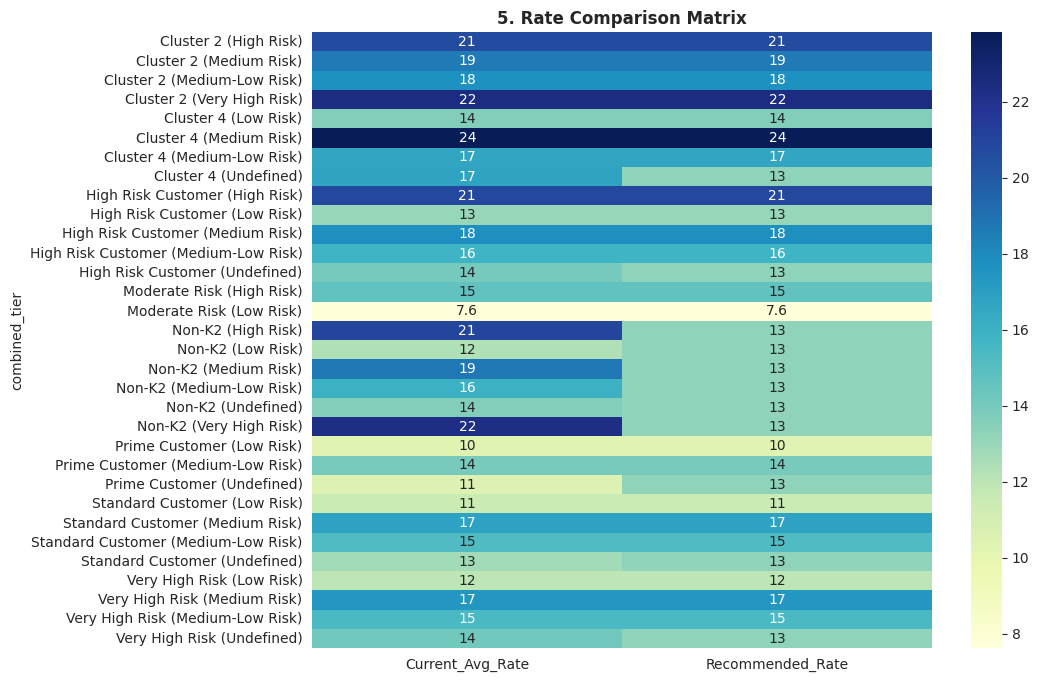

In [ ]:
# Chart 5: Recommended Rate Heatmap
plt.figure(figsize=(10, 8))
pivot_data = pricing_rec.pivot_table(index='combined_tier', values=['Current_Avg_Rate', 'Recommended_Rate'])
sns.heatmap(pivot_data, annot=True, cmap='YlGnBu')
plt.title('5. Rate Comparison Matrix', fontweight='bold')

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart5_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis & Evaluasi Chart 5: Rate Comparison Matrix

Heatmap ini membandingkan:
- suku bunga saat ini (`Current_Avg_Rate`),
- dengan suku bunga rekomendasi (`Recommended_Rate`)
pada setiap segmen nasabah.

Semakin gelap warna biru, semakin tinggi tingkat suku bunga pada segmen tersebut.

---

## Insight Utama

### Segmen Stabil
Sebagian besar segmen utama menunjukkan:
- nilai bunga saat ini,
- dan bunga rekomendasi
yang hampir sama.

Artinya:
- pricing existing perusahaan sudah cukup sesuai dengan profil risiko nasabah,
- sehingga model K3 tidak memberikan perubahan besar.

---

### Pola Normalisasi ke 13%
Beberapa segmen `Non-K2` atau `Undefined` mengalami penyesuaian menuju kisaran bunga sekitar **13%**.

Contohnya:
- segmen dengan bunga terlalu tinggi diturunkan,
- sedangkan segmen dengan bunga terlalu rendah dinaikkan.

Hal ini menunjukkan bahwa model menggunakan:
- pendekatan normalisasi pricing,
- untuk menjaga keseimbangan risiko dan profitabilitas.

---

### Fungsi Safe Pricing
Nilai sekitar 13% berfungsi sebagai:
- titik pricing aman (*safe-zone pricing*),
- khususnya untuk segmen yang tidak memiliki karakteristik cluster yang jelas.

Strategi ini membantu:
- mengurangi overpricing,
- menghindari underpricing,
- serta menjaga kestabilan portofolio.

---

# Kesimpulan

Model K3 bekerja dengan dua pendekatan:
1. mempertahankan pricing yang sudah optimal pada segmen valid,
2. melakukan normalisasi bunga pada segmen tidak stabil atau tidak terdefinisi.

Heatmap ini membantu melihat efektivitas strategi pricing secara cepat dan terstruktur.

### Tahap 6 Analisis Strategis Chart 6: Population by Risk Tier


Grafik ini menampilkan distribusi jumlah nasabah berdasarkan kategori tingkat risiko (`risk_tier_k1`).

Kategori risiko dibagi menjadi:
- Low Risk,
- Medium-Low Risk,
- Medium Risk,
- High Risk,
- Very High Risk.

---

## Insight Utama

### Distribusi Populasi Risiko
Grafik menunjukkan bagaimana persebaran nasabah pada setiap level risiko.

Jumlah populasi terbesar biasanya berada pada:
- kategori risiko menengah,
- yang menjadi segmen utama portofolio perusahaan.

---

### Evaluasi Struktur Portofolio
Distribusi ini membantu melihat:
- apakah portofolio perusahaan didominasi nasabah aman,
- atau terlalu banyak terpapar nasabah berisiko tinggi.

Jika populasi `High Risk` dan `Very High Risk` terlalu besar:
- potensi kredit macet meningkat,
- sehingga diperlukan kontrol risiko yang lebih ketat.

---

### Fungsi Strategis Risk Tier
Segmentasi risk tier digunakan sebagai dasar:
- penentuan bunga,
- approval pinjaman,
- monitoring risiko,
- dan strategi pricing pada K3.

Semakin tinggi risk tier:
- semakin tinggi potensi risiko gagal bayar.

---

# Kesimpulan

Grafik ini membantu memahami komposisi risiko keseluruhan portofolio nasabah.

Visualisasi population risk tier penting untuk:
- evaluasi kesehatan portofolio,
- pengambilan keputusan manajemen risiko,
- dan optimasi strategi risk-based pricing.

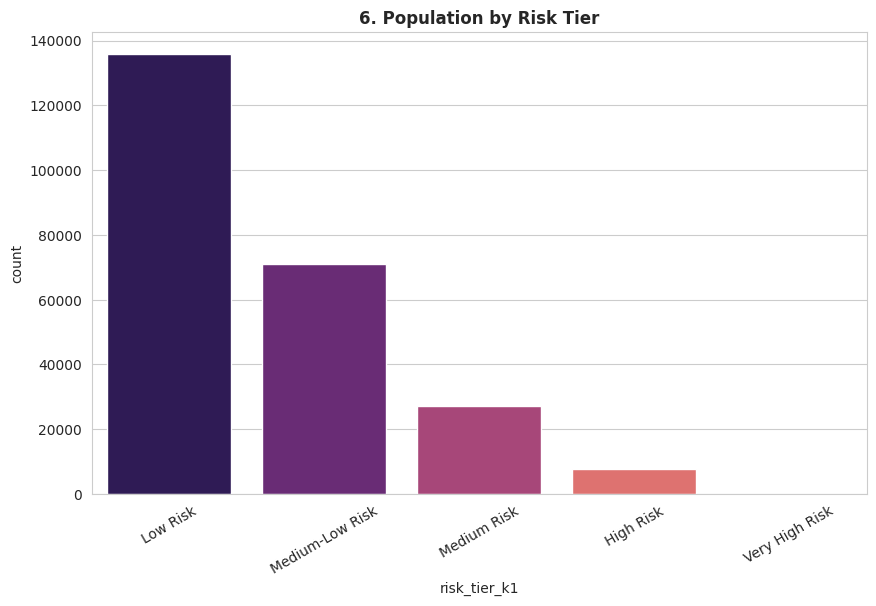

In [ ]:
# Chart 6: Risk Tier Population count
plt.figure(figsize=(10, 6))
sns.countplot(data=df_full, x='risk_tier_k1', order=['Low Risk', 'Medium-Low Risk', 'Medium Risk', 'High Risk', 'Very High Risk'], palette='magma')
plt.title('6. Population by Risk Tier', fontweight='bold')
plt.tick_params(axis='x', rotation=30)

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart6_population_risk.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Strategis Chart 6: Population by Risk Tier


Grafik ini menunjukkan distribusi jumlah nasabah berdasarkan kategori tingkat risiko (`risk_tier_k1`), mulai dari *Low Risk* hingga *Very High Risk*.

---

## Insight Utama

### Dominasi Nasabah Risiko Rendah
Sebagian besar nasabah berada pada kategori:
- `Low Risk`,
- dan `Medium-Low Risk`.

Hal ini menunjukkan bahwa:
- portofolio perusahaan secara umum masih tergolong sehat,
- dengan mayoritas nasabah memiliki risiko gagal bayar yang rendah.

---

### Penurunan Populasi Seiring Kenaikan Risiko
Jumlah nasabah menurun secara signifikan pada kategori:
- `High Risk`,
- dan `Very High Risk`.

Pola ini mencerminkan struktur portofolio yang ideal karena:
- eksposur terhadap nasabah berisiko tinggi relatif kecil,
- sehingga potensi kerugian massal lebih terkendali.

---

### Fungsi Risk Tier dalam K3
Risk tier digunakan sebagai dasar utama untuk:
- penentuan pricing,
- evaluasi kredit,
- monitoring risiko,
- dan strategi approval pinjaman.

Semakin tinggi kategori risiko:
- semakin besar potensi penyesuaian bunga pada model K3.

---

### Dampak terhadap Profitabilitas
Karena segmen `Low Risk` memiliki populasi terbesar:
- perubahan bunga kecil pada kelompok ini dapat memberikan dampak besar terhadap total pendapatan bunga perusahaan.

Sementara itu:
- segmen `High Risk` lebih difokuskan untuk proteksi risiko dibanding volume bisnis.

---

# Kesimpulan

Grafik ini menunjukkan bahwa portofolio perusahaan didominasi oleh nasabah dengan risiko rendah hingga menengah.

Distribusi tersebut menandakan:
- kondisi portofolio yang cukup stabil,
- risiko kredit yang masih terkendali,
- serta mendukung implementasi strategi risk-based pricing pada model K3.

###  TAHAP 7 : Visualisasi Dashboard Strategis Risk-Based Pricing (Chart 7)


Grafik boxplot ini menampilkan distribusi suku bunga (`int_rate_original`) pada setiap segmen nasabah (`combined_tier`).

Visualisasi ini membantu melihat:
- persebaran bunga,
- median suku bunga,
- serta keberadaan outlier pada masing-masing segmentasi.

---

## Insight Utama

### Perbedaan Distribusi Antar Segmen
Setiap segmen memiliki pola distribusi bunga yang berbeda.

Beberapa segmen menunjukkan:
- rentang bunga yang sempit,
- menandakan pricing yang lebih stabil dan konsisten.

Sedangkan segmen lain memiliki:
- variasi bunga yang lebar,
- menunjukkan adanya heterogenitas profil risiko dalam segmen tersebut.

---

### Identifikasi Outlier
Titik di luar whisker boxplot menunjukkan adanya:
- nasabah dengan bunga ekstrem,
- baik terlalu tinggi maupun terlalu rendah dibanding mayoritas segmen.

Outlier ini dapat menjadi indikasi:
- anomali pricing,
- kasus risiko khusus,
- atau kebutuhan evaluasi pricing lebih lanjut.

---

### Median Suku Bunga
Garis tengah pada boxplot menunjukkan median bunga tiap segmen.

Semakin tinggi median:
- semakin mahal rata-rata pricing pada segmen tersebut,
- biasanya berkaitan dengan tingkat risiko yang lebih tinggi.

---

### Evaluasi Konsistensi Pricing
Segmen dengan boxplot yang terlalu lebar menunjukkan:
- kebijakan pricing yang kurang seragam,
- sehingga berpotensi membutuhkan standardisasi pricing melalui model K3.

---

# Kesimpulan

Grafik ini membantu mengevaluasi:
- kestabilan pricing antar segmen,
- konsistensi penetapan bunga,
- serta mendeteksi adanya outlier atau ketidaksesuaian pricing.

Visualisasi ini mendukung proses optimasi risk-based pricing agar distribusi bunga menjadi lebih terkontrol dan sesuai profil risiko nasabah.

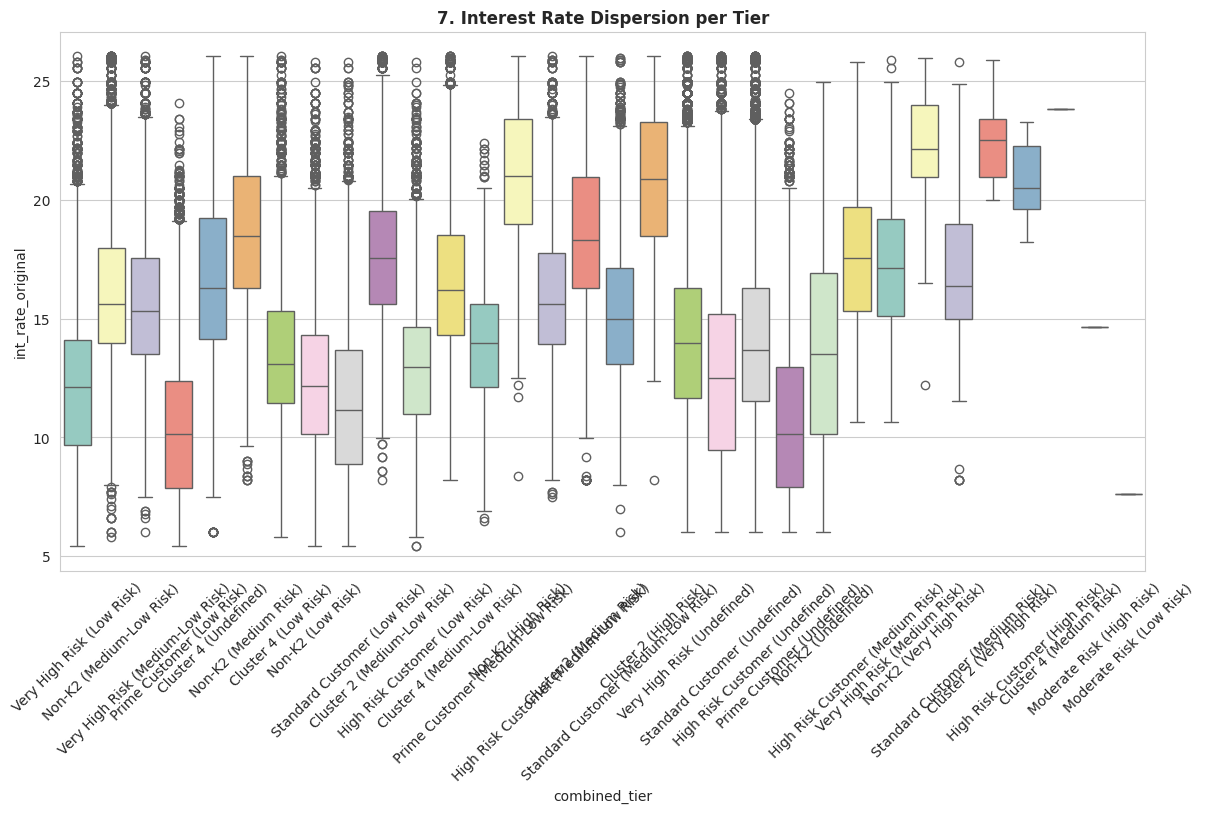

In [ ]:
# Chart 7: Boxplot Current Rate across Segments
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_full, x='combined_tier', y='int_rate_original', palette='Set3')
plt.title('7. Interest Rate Dispersion per Tier', fontweight='bold')
plt.tick_params(axis='x', rotation=45)

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart7_rate_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Strategis Chart 7: Interest Rate Dispersion per Tier


Grafik boxplot ini menunjukkan distribusi suku bunga asli (`int_rate_original`) pada setiap segmen nasabah (`combined_tier`) sebelum dilakukan optimasi pricing K3.

Visualisasi ini digunakan untuk melihat tingkat konsistensi penetapan bunga pada masing-masing segmen.

---

## Insight Utama

### Variasi Suku Bunga Antar Segmen
Beberapa segmen memiliki boxplot yang sangat lebar.

Hal ini menunjukkan:
- adanya perbedaan bunga yang besar dalam segmen yang sama,
- sehingga pricing historis belum konsisten.

Nasabah dengan profil risiko serupa masih bisa menerima bunga yang jauh berbeda.

---

### Deteksi Outlier
Terdapat banyak titik outlier pada beberapa segmen dengan bunga sangat tinggi.

Pola ini menunjukkan:
- adanya kasus pricing ekstrem,
- atau penerapan bunga maksimum (*rate capping*)
pada sebagian kelompok nasabah.

---

### Segmen Stabil
Beberapa segmen memiliki boxplot yang sempit atau hampir berbentuk garis.

Artinya:
- pricing pada segmen tersebut sudah sangat seragam,
- dengan variasi bunga yang kecil antar nasabah.

Biasanya kondisi ini terjadi pada produk kredit dengan tarif tetap atau aturan pricing yang lebih ketat.

---

### Pentingnya Optimasi K3
Distribusi bunga yang terlalu lebar menunjukkan bahwa:
- sistem pricing sebelumnya masih belum optimal,
- dan belum sepenuhnya mengikuti profil risiko nasabah.

Model K3 digunakan untuk:
- menstandarisasi pricing,
- mengurangi ketimpangan bunga,
- serta menciptakan penetapan bunga yang lebih adil dan terukur.

---

# Kesimpulan

Grafik ini menunjukkan bahwa masih terdapat ketidakkonsistenan pricing pada beberapa segmen portofolio.

Karena itu, optimasi risk-based pricing pada K3 penting untuk:
- mengurangi anomali bunga,
- meningkatkan konsistensi pricing,
- dan menjaga keseimbangan antara profitabilitas serta risiko kredit.

### Tahap 8 Analisis Strategis Chart 8: Risk-Adjusted Delta Scatter


Grafik scatter ini menunjukkan hubungan antara:
- rata-rata risk score (`Avg_Risk_Score`),
- dan perubahan suku bunga (`Int_Rate_Difference`)
hasil optimasi model K3.

Nilai delta menunjukkan selisih antara:
- suku bunga rekomendasi,
- dan suku bunga saat ini.

---

## Insight Utama

### Interpretasi Delta
- Delta positif → bunga direkomendasikan naik.
- Delta negatif → bunga direkomendasikan turun.
- Delta mendekati nol → pricing saat ini sudah sesuai.

Garis horizontal merah pada nilai `0` digunakan sebagai batas keseimbangan pricing.

---

### Pola Penyesuaian Risiko
Grafik menunjukkan bahwa:
- beberapa segmen berisiko tinggi masih mengalami kenaikan bunga,
- sedangkan segmen tertentu justru direkomendasikan penurunan bunga untuk menjaga daya saing.

Hal ini menunjukkan bahwa optimasi K3 tidak hanya mempertimbangkan risiko, tetapi juga efisiensi pricing secara keseluruhan.

---

### Deteksi Outlier Pricing
Titik yang berada jauh dari garis nol menunjukkan:
- segmen dengan pricing paling tidak optimal,
- baik terlalu murah (*underpriced*)
- maupun terlalu mahal (*overpriced*).

Segmen tersebut menjadi prioritas utama dalam penyesuaian pricing.

---

### Fungsi Visualisasi
Scatter plot ini membantu melihat:
- arah penyesuaian bunga,
- besarnya perubahan pricing,
- serta hubungan langsung antara risiko dan keputusan optimasi suku bunga.

---

# Kesimpulan

Grafik ini menunjukkan bahwa model K3 berhasil melakukan penyesuaian bunga berdasarkan tingkat risiko masing-masing segmen.

Visualisasi ini membantu:
- mengidentifikasi segmen yang perlu koreksi pricing,
- menjaga keseimbangan risiko dan profitabilitas,
- serta meningkatkan efektivitas strategi risk-based pricing.

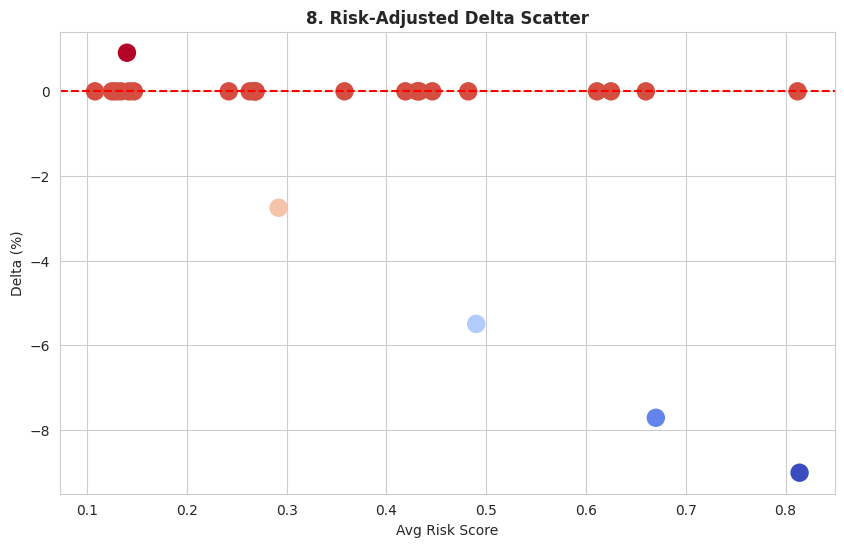

In [ ]:
# Chart 8: Adjustment Scatter (Deviation from Mean)
plt.figure(figsize=(10, 6))
plt.scatter(pricing_rec['Avg_Risk_Score'], pricing_rec['Int_Rate_Difference'], c=pricing_rec['Int_Rate_Difference'], cmap='coolwarm', s=150)
plt.axhline(0, color='red', linestyle='--')
plt.title('8. Risk-Adjusted Delta Scatter', fontweight='bold')
plt.xlabel('Avg Risk Score')
plt.ylabel('Delta (%)')

# Menyimpan grafik individual ke Drive
plt.savefig(FILE_PATH + 'k3_chart8_risk_delta_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Analisis Strategis Chart 8: Risk-Adjusted Delta Scatter
# Analisis Risk-Adjusted Delta Scatter

Grafik scatter ini menunjukkan hubungan antara:
- rata-rata tingkat risiko (`Avg_Risk_Score`),
- dan perubahan suku bunga (`Int_Rate_Difference`)
hasil optimasi model K3.

Garis merah horizontal pada nilai `0` digunakan sebagai baseline perubahan pricing.

---

## Insight Utama

### Segmen Stabil
Mayoritas titik berada tepat di sekitar garis `Y = 0`.

Artinya:
- sebagian besar segmen tidak mengalami perubahan bunga,
- karena model menilai pricing existing sudah sesuai dengan profil risikonya.

Hal ini menunjukkan bahwa:
- sistem pricing perusahaan secara umum sudah cukup stabil.

---

### Penyesuaian pada Segmen Outlier
Beberapa titik berada jauh di bawah garis baseline dengan delta negatif yang besar.

Artinya:
- model merekomendasikan penurunan bunga cukup signifikan pada segmen tertentu,
- terutama pada kelompok `Non-K2` atau segmen yang sebelumnya mengalami overpricing.

---

### Pola Penurunan Linear
Terlihat pola bahwa:
- semakin tinggi risk score,
- beberapa segmen justru mendapatkan penurunan bunga lebih besar.

Kondisi ini terjadi karena model menerapkan:
- normalisasi pricing menuju kisaran bunga aman (~13%),
- khususnya pada segmen outlier dengan tarif lama yang terlalu tinggi.

---

### Catatan Evaluasi Risiko
Secara manajemen risiko:
- penurunan bunga pada segmen berisiko tinggi perlu diberi justifikasi yang kuat,
- karena secara teori nasabah berisiko tinggi biasanya dikenakan bunga lebih besar.

Namun dalam konteks K3:
- strategi ini bertujuan memperbaiki kasus overpricing ekstrem,
- sekaligus menjaga retensi nasabah dan kestabilan portofolio.

---

# Kesimpulan

Grafik ini menunjukkan bahwa model K3:
- mempertahankan pricing pada mayoritas segmen stabil,
- namun melakukan koreksi agresif pada segmen outlier yang dianggap tidak optimal.

Visualisasi ini menjadi ringkasan utama bagaimana model melakukan penyesuaian pricing berbasis risiko secara lebih terukur.